# Importing libraries:

In [3]:
# ============================================
# MODULE 1: DATA LOADING & CLEANING
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries imported successfully!")

Libraries imported successfully!


# Load dataset:

In [4]:

# Load dataset
df = pd.read_csv(r"C:\Users\preks\OneDrive\Desktop\Atlantic_Spain.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (27800, 10)


In [5]:
df

,date,position,song,artist,popularity,duration_ms,album_type,total_tracks,is_explicit,album_cover_url
0,18-05-2024,1,Supernova,Saiko,84,190909,single,1,False,https://i.scdn.co/image/ab67616d0000b273c3f5b9...
1,18-05-2024,2,EL TONTO,Lola Indigo,83,187986,album,11,False,https://i.scdn.co/image/ab67616d0000b273daab36...
2,18-05-2024,3,Acróstico,Shakira,81,170785,single,1,False,https://i.scdn.co/image/ab67616d0000b273bd6bbd...
3,18-05-2024,4,BESO,ROSALÍA & Rauw Alejandro,96,194543,single,3,False,https://i.scdn.co/image/ab67616d0000b2734d6cf0...
4,18-05-2024,5,El Merengue,Marshmello & Manuel Turizo,91,189668,single,1,False,https://i.scdn.co/image/ab67616d0000b273f40467...
...,...,...,...,...,...,...,...,...,...,...
27795,27-11-2025,46,Celine (with Kidd Keo),Ghost Killer Track & Kidd Keo,73,176017,single,1,False,https://i.scdn.co/image/ab67616d0000b273892224...
27796,27-11-2025,47,Vacile,Yan Block,78,140239,single,1,True,https://i.scdn.co/image/ab67616d0000b273b7a46e...
27797,27-11-2025,48,Rapido (with Cris Mj),Dei V,76,146000,album,16,True,https://i.scdn.co/image/ab67616d0000b2734258ad...
27798,27-11-2025,49,PELIGROSA,FloyyMenor,83,134930,album,7,True,https://i.scdn.co/image/ab67616d0000b273200e2b...


In [6]:
# Check dataset structure
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

Number of rows: 27800
Number of columns: 10

Column Names:
['date', 'position', 'song', 'artist', 'popularity', 'duration_ms', 'album_type', 'total_tracks', 'is_explicit', 'album_cover_url']

Data Types:
date               object
position            int64
song               object
artist             object
popularity          int64
duration_ms         int64
album_type         object
total_tracks        int64
is_explicit          bool
album_cover_url    object
dtype: object


# Data Cleaning:

In [7]:
# Check missing values
missing_values = df.isnull().sum()

missing_summary = pd.DataFrame({
    "Missing_Count": missing_values,
    "Missing_Percentage": (missing_values / len(df)) * 100
})

missing_summary = missing_summary.sort_values(
    by="Missing_Count",
    ascending=False
)

missing_summary

,Missing_Count,Missing_Percentage
date,0,0.0
position,0,0.0
song,0,0.0
artist,0,0.0
popularity,0,0.0
duration_ms,0,0.0
album_type,0,0.0
total_tracks,0,0.0
is_explicit,0,0.0
album_cover_url,0,0.0


In [8]:
# Check duplicate records
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 15


In [9]:
# Remove exact duplicates:

df = df.drop_duplicates().reset_index(drop=True)

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (27785, 10)


In [10]:
print("Number of duplicate rows:", df)

Number of duplicate rows:              date  position                    song  \
0      18-05-2024         1               Supernova   
1      18-05-2024         2                EL TONTO   
2      18-05-2024         3               Acróstico   
3      18-05-2024         4                    BESO   
4      18-05-2024         5             El Merengue   
...           ...       ...                     ...   
27780  27-11-2025        46  Celine (with Kidd Keo)   
27781  27-11-2025        47                  Vacile   
27782  27-11-2025        48   Rapido (with Cris Mj)   
27783  27-11-2025        49               PELIGROSA   
27784  27-11-2025        50                    LUNA   

                              artist  popularity  duration_ms album_type  \
0                              Saiko          84       190909     single   
1                        Lola Indigo          83       187986      album   
2                            Shakira          81       170785     single   
3        

In [11]:
# See the duplicate rows first
# Display duplicate records
duplicates = df[df.duplicated(keep=False)]

print("Total duplicate records:", len(duplicates))
duplicates

Total duplicate records: 0


,date,position,song,artist,popularity,duration_ms,album_type,total_tracks,is_explicit,album_cover_url


In [12]:
# Remove duplicate rows
df = df.drop_duplicates()

print("Duplicates removed successfully.")
print("New dataset shape:", df.shape)

Duplicates removed successfully.
New dataset shape: (27785, 10)


In [13]:
# Verify
# Check again
print("Number of duplicate rows after cleaning:", df.duplicated().sum())

Number of duplicate rows after cleaning: 0


In [14]:
# Clean column names
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

print(df.columns.tolist())

['date', 'position', 'song', 'artist', 'popularity', 'duration_ms', 'album_type', 'total_tracks', 'is_explicit', 'album_cover_url']


In [15]:
# Convert date column
df["date"] = pd.to_datetime(
    df["date"],
    errors="coerce"
)

print("Invalid dates:", df["date"].isna().sum())

# Invalid dates: 0 = This means all values in your date column were successfully converted to datetime.

Invalid dates: 0


C:\Users\preks\AppData\Local\Temp\ipykernel_6836\3762169108.py:2: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["date"] = pd.to_datetime(


In [16]:
# Check the date range:

print("Start Date:", df["date"].min())
print("End Date:", df["date"].max())

Start Date: 2024-05-18 00:00:00
End Date: 2025-11-27 00:00:00


In [17]:
# Convert numerical columns
numeric_columns = [
    "position",
    "popularity",
    "duration_ms",
    "total_tracks"
]

for col in numeric_columns:
    df[col] = pd.to_numeric(
        df[col],
        errors="coerce"
    )

print(df[numeric_columns].dtypes)

position        int64
popularity      int64
duration_ms     int64
total_tracks    int64
dtype: object


In [18]:
# Clean is_explicit (This handles values such as True, False, 1, 0, "true", "false" etc.)

def clean_explicit(value):
    if pd.isna(value):
        return np.nan
    
    value = str(value).strip().lower()
    
    if value in ["true", "1", "yes", "y", "explicit"]:
        return True
    
    if value in ["false", "0", "no", "n", "clean"]:
        return False
    
    return np.nan


df["is_explicit"] = df["is_explicit"].apply(clean_explicit)

print(df["is_explicit"].value_counts(dropna=False))

# This means:
# False → non-explicit/clean songs
# True → explicit songs
# NaN → values that were missing or could not be recognized

is_explicit
False    16132
True     11653
Name: count, dtype: int64


In [19]:
# Clean album type
df["album_type"] = (
    df["album_type"]
    .astype(str)
    .str.strip()
    .str.lower()
)

print(df["album_type"].value_counts())

album_type
single    16032
album     11753
Name: count, dtype: int64


In [20]:
# Clean song and artist names
df["song"] = (
    df["song"]
    .astype(str)
    .str.strip()
)

df["artist"] = (
    df["artist"]
    .astype(str)
    .str.strip()
)

In [21]:
# Create duration in minutes (The original duration_ms is in milliseconds)

df["duration_min"] = df["duration_ms"] / 60000

df[["song", "duration_ms", "duration_min"]].head()

,song,duration_ms,duration_min
0,Supernova,190909,3.181817
1,EL TONTO,187986,3.133100
2,Acróstico,170785,2.846417
3,BESO,194543,3.242383
4,El Merengue,189668,3.161133


In [22]:
# Create normalized song and artist keys
# (This is important because the same song can sometimes appear with differences in capitalization or spacing)

df["song_key"] = (
    df["song"]
    .str.lower()  # .str.lower() Sab letters lowercase ho jaate hain.
    .str.replace(r"\s+", " ", regex=True)  # .str.replace(r"\s+", " ", regex=True) Ye extra spaces ko single space mein convert karta hai.
                                           # Yahan \s+ ka matlab hai one or more whitespace characters.
    .str.strip()  # .str.strip() Starting aur ending ke unwanted spaces remove karta hai:
)

df["artist_key"] = (
    df["artist"]
    .str.lower()
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

In [23]:
# Create unique track key
df["track_key"] = (
    df["song_key"] + " | " + df["artist_key"] # Yahan hum song_key aur artist_key ko combine kar rahe hain. " | " Ye sirf separator hai
)

print("Unique tracks:", df["track_key"].nunique())  # nunique() ka meaning hai number of unique values count karna

Unique tracks: 575


In [24]:
# Final missing-value check
final_missing = pd.DataFrame({
    "Column": df.columns,
    "Missing_Count": df.isna().sum(),
    "Missing_Percentage": (
        df.isna().sum() / len(df) * 100
    )
})

final_missing

,Column,Missing_Count,Missing_Percentage
date,date,0,0.0
position,position,0,0.0
song,song,0,0.0
artist,artist,0,0.0
popularity,popularity,0,0.0
duration_ms,duration_ms,0,0.0
album_type,album_type,0,0.0
total_tracks,total_tracks,0,0.0
is_explicit,is_explicit,0,0.0
album_cover_url,album_cover_url,0,0.0


In [25]:
# Basic statistical summary
df.describe(include="all").T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
date,27785,NaN,NaN,NaN,2025-02-20 08:26:05.161058304,2024-05-18 00:00:00,2024-10-03 00:00:00,2025-02-19 00:00:00,2025-07-10 00:00:00,2025-11-27 00:00:00,NaN
position,27785.0,NaN,NaN,NaN,25.504121,1.0,13.0,26.0,38.0,50.0,14.429605
song,27785,545,La Bachata,539,NaN,NaN,NaN,NaN,NaN,NaN,NaN
artist,27785,306,Myke Towers,1231,NaN,NaN,NaN,NaN,NaN,NaN,NaN
popularity,27785.0,NaN,NaN,NaN,81.121216,0.0,76.0,82.0,87.0,100.0,10.089403
duration_ms,27785.0,NaN,NaN,NaN,197473.666547,90613.0,168594.0,191254.0,218119.0,555071.0,43375.029556
album_type,27785,2,single,16032,NaN,NaN,NaN,NaN,NaN,NaN,NaN
total_tracks,27785.0,NaN,NaN,NaN,7.203383,1.0,1.0,1.0,15.0,49.0,7.684176
is_explicit,27785,2,False,16132,NaN,NaN,NaN,NaN,NaN,NaN,NaN
album_cover_url,27785,419,https://i.scdn.co/image/ab67616d0000b2737b1fc5...,659,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [26]:
# Save cleaned dataset
output_path = "Spain_Top50_Cleaned.csv"

df.to_csv(
    output_path,
    index=False
)

print(f"Cleaned dataset saved as: {output_path}")

Cleaned dataset saved as: Spain_Top50_Cleaned.csv


In [27]:
# Module 1 verification
print("=" * 50)
print("MODULE 1 COMPLETED")
print("=" * 50)

print("Rows:", len(df))
print("Columns:", len(df.columns))
print("Unique Songs:", df["track_key"].nunique())
print("Date Range:", df["date"].min(), "to", df["date"].max())
print("Missing Values:", df.isna().sum().sum())
print("Duplicates:", df.duplicated().sum())

MODULE 1 COMPLETED
Rows: 27785
Columns: 14
Unique Songs: 575
Date Range: 2024-05-18 00:00:00 to 2025-11-27 00:00:00
Missing Values: 0
Duplicates: 0


# Daily Top 50 Validation
checks whether your Spain Top 50 dataset has exactly 50 songs for every date, whether positions 1–50 are complete

In [28]:
# heck number of songs per day
daily_count = (
    df.groupby("date")
      .size()
      .reset_index(name="song_count")
)

daily_count.head(10)

,date,song_count
0,2024-05-18,50
1,2024-05-19,50
2,2024-05-20,50
3,2024-05-21,50
4,2024-05-22,50
5,2024-05-23,50
6,2024-05-24,50
7,2024-05-25,50
8,2024-05-26,50
9,2024-05-27,50


In [29]:
# Find dates that do not have exactly 50 songs
invalid_song_count = daily_count[
    daily_count["song_count"] != 50
]

print("Total dates:", len(daily_count))
print("Dates with exactly 50 songs:", (daily_count["song_count"] == 50).sum())
print("Invalid dates:", len(invalid_song_count))

invalid_song_count

Total dates: 555
Dates with exactly 50 songs: 554
Invalid dates: 1


,date,song_count
287,2025-03-01,85


In [30]:
problem_date = pd.Timestamp("2025-03-01")

problem_df = df[df["date"] == problem_date].copy()

print("Total records:", len(problem_df))
print("Unique tracks:", problem_df["track_key"].nunique())

problem_df[
    ["date", "song", "artist", "track_key"]
].sort_values("track_key")

# Expected tracks = 50
# Unique tracks = 51 → 1 extra unique track
# Total rows = 85
#Extra repeated rows = 85 − 51 = 34

Total records: 85
Unique tracks: 51


,date,song,artist,track_key
14368,2025-03-01,A 300,JC Reyes & Pedro Calderon & Blacknife,a 300 | jc reyes & pedro calderon & blacknife
14391,2025-03-01,ASI ES LA VIDA,Enrique Iglesias & Maria Becerra,asi es la vida | enrique iglesias & maria becerra
14426,2025-03-01,ASI ES LA VIDA,Enrique Iglesias & Maria Becerra,asi es la vida | enrique iglesias & maria becerra
14382,2025-03-01,BABY HELLO,Rauw Alejandro,baby hello | rauw alejandro
14422,2025-03-01,BABY HELLO,Rauw Alejandro,baby hello | rauw alejandro
14411,2025-03-01,BAD BOY,Chris Jedi & Gaby Music & Dei V,bad boy | chris jedi & gaby music & dei v
14371,2025-03-01,BAD BOY,Chris Jedi & Gaby Music & Dei V,bad boy | chris jedi & gaby music & dei v
14389,2025-03-01,Buenas,Quevedo & Saiko,buenas | quevedo & saiko
14367,2025-03-01,Buscando Money,TWENTY SIX & Tayson Kryss,buscando money | twenty six & tayson kryss
14408,2025-03-01,Buscando Money,TWENTY SIX & Tayson Kryss,buscando money | twenty six & tayson kryss


In [31]:
# # Check repeated tracks on the problematic date

problem_df = df[df["date"] == "2025-03-01"].copy()

track_counts = (
    problem_df["track_key"]
    .value_counts()
)

print("Tracks appearing more than once:")
print(track_counts[track_counts > 1])

Tracks appearing more than once:
track_key
fardos | jc reyes & de la ghetto                                                                          2
gata only | floyymenor & cris mj                                                                          2
casanova | soolking & lola indigo & rvfv                                                                  2
el patio | pepe y vizio & delaossa & kiddo                                                                2
perro negro | bad bunny                                                                                   2
young miko: bzrp music sessions, vol. 58 | bizarrap & young miko                                          2
buscando money | twenty six & tayson kryss                                                                2
la última | quevedo                                                                                       2
la_original.mp3 | emilia                                                                     

In [32]:
# Show all 85 records sorted by track
problem_df[
    ["date", "song", "artist", "track_key"]
].sort_values("track_key")

,date,song,artist,track_key
14368,2025-03-01,A 300,JC Reyes & Pedro Calderon & Blacknife,a 300 | jc reyes & pedro calderon & blacknife
14391,2025-03-01,ASI ES LA VIDA,Enrique Iglesias & Maria Becerra,asi es la vida | enrique iglesias & maria becerra
14426,2025-03-01,ASI ES LA VIDA,Enrique Iglesias & Maria Becerra,asi es la vida | enrique iglesias & maria becerra
14382,2025-03-01,BABY HELLO,Rauw Alejandro,baby hello | rauw alejandro
14422,2025-03-01,BABY HELLO,Rauw Alejandro,baby hello | rauw alejandro
14411,2025-03-01,BAD BOY,Chris Jedi & Gaby Music & Dei V,bad boy | chris jedi & gaby music & dei v
14371,2025-03-01,BAD BOY,Chris Jedi & Gaby Music & Dei V,bad boy | chris jedi & gaby music & dei v
14389,2025-03-01,Buenas,Quevedo & Saiko,buenas | quevedo & saiko
14367,2025-03-01,Buscando Money,TWENTY SIX & Tayson Kryss,buscando money | twenty six & tayson kryss
14408,2025-03-01,Buscando Money,TWENTY SIX & Tayson Kryss,buscando money | twenty six & tayson kryss


In [33]:
problem_df[
    ["date", "rank", "song", "artist", "track_key"]
].sort_values("rank")

KeyError: "['rank'] not in index"

In [34]:
# Duplicate tracks + extra records clean karo
# Sort by date and rank
df = df.sort_values(["date"])

# Same song ko same date par sirf ek baar rakho
df = df.drop_duplicates(
    subset=["date", "track_key"],
    keep="first"
)

# Har date ke sirf Top 50 songs rakho
df = (
    df.groupby("date", group_keys=False)
      .head(50)
      .reset_index(drop=True)
)

In [35]:
# Ab dobara check karo
# Check dates that do not have exactly 50 songs

daily_count = (
    df.groupby("date")
      .size()
      .reset_index(name="song_count")
)

invalid_song_count = daily_count[
    daily_count["song_count"] != 50
]

print("Total dates:", len(daily_count))
print("Dates with exactly 50 songs:", 
      (daily_count["song_count"] == 50).sum())
print("Invalid dates:", len(invalid_song_count))

invalid_song_count

Total dates: 555
Dates with exactly 50 songs: 555
Invalid dates: 0


,date,song_count


In [36]:
# Check position range
position_summary = (
    df.groupby("date")["position"]
      .agg(
          min_position="min",
          max_position="max",
          unique_positions="nunique"
      )
      .reset_index()
)

position_summary.head()

,date,min_position,max_position,unique_positions
0,2024-05-18,1,50,50
1,2024-05-19,1,50,50
2,2024-05-20,1,50,50
3,2024-05-21,1,50,50
4,2024-05-22,1,50,50


In [37]:
# Identify invalid position dates
invalid_positions = position_summary[
    (position_summary["min_position"] != 1) |
    (position_summary["max_position"] != 50) |
    (position_summary["unique_positions"] != 50)
]

print("Dates with invalid positions:", len(invalid_positions))

invalid_positions

# Iska matlab 2025-03-01 par position 1–50 range mein hai, lekin 48 unique positions hi hain. Yaani kuch positions repeat ho rahi hain.
# Agar tumhara goal hai ki har date par exactly 50 songs aur positions 1–50 hon, to ye code use karo.

Dates with invalid positions: 1


,date,min_position,max_position,unique_positions
287,2025-03-01,1,50,48


In [38]:
# Step 1 — 2025-03-01 ki duplicate positions dekho
problem_positions = (
    df[df["date"] == pd.Timestamp("2025-03-01")]["position"]
    .value_counts()
)

print("Duplicate positions:")
print(problem_positions[problem_positions > 1])

Duplicate positions:
position
47    2
46    2
Name: count, dtype: int64


In [39]:
# Step 2 — Positions ko properly 1–50 normalize karo
# Agar tumhare dataset mein har date par Top 50 songs hi hone chahiye, to:

# Sort by date and existing position
df = df.sort_values(["date", "position"]).copy()

# Reassign positions sequentially from 1 to 50 for each date
df["position"] = (
    df.groupby("date")
      .cumcount() + 1
)

print("Positions reassigned successfully.")

Positions reassigned successfully.


In [40]:
# Step 3 — Verify karo
position_summary = (
    df.groupby("date")["position"]
      .agg(
          min_position="min",
          max_position="max",
          unique_positions="nunique"
      )
      .reset_index()
)

invalid_positions = position_summary[
    (position_summary["min_position"] != 1) |
    (position_summary["max_position"] != 50) |
    (position_summary["unique_positions"] != 50)
]

print("Dates with invalid positions:", len(invalid_positions))

invalid_positions

Dates with invalid positions: 0


,date,min_position,max_position,unique_positions


In [41]:
# Check duplicate positions within each date
duplicate_positions = (
    df.groupby(["date", "position"])
      .size()
      .reset_index(name="count")
)

duplicate_positions = duplicate_positions[
    duplicate_positions["count"] > 1
]

print("Duplicate date-position combinations:",
      len(duplicate_positions))

duplicate_positions.head(20)

Duplicate date-position combinations: 0


,date,position,count


In [42]:
# Check missing positions (This tells us which ranking positions are missing on each date)
missing_position_records = []

for date, group in df.groupby("date"):
    
    actual_positions = set(group["position"].dropna().astype(int))
    expected_positions = set(range(1, 51))
    
    missing = sorted(expected_positions - actual_positions)
    
    if missing:
        missing_position_records.append({
            "date": date,
            "missing_positions": missing,
            "missing_count": len(missing)
        })

missing_positions_df = pd.DataFrame(
    missing_position_records
)

missing_positions_df

""


In [43]:
# Check extra/invalid positions
invalid_position_values = df[
    (df["position"] < 1) |
    (df["position"] > 50)
]

print(
    "Rows with position outside 1–50:",
    len(invalid_position_values)
)

invalid_position_values.head()

Rows with position outside 1–50: 0


,date,position,song,artist,popularity,duration_ms,album_type,total_tracks,is_explicit,album_cover_url,duration_min,song_key,artist_key,track_key


In [44]:
# Check duplicate songs on the same date (A Top 50 playlist should normally contain each track only once per daily snapshot)

duplicate_songs_daily = (
    df.groupby(["date", "track_key"])
      .size()
      .reset_index(name="count")
)

duplicate_songs_daily = duplicate_songs_daily[
    duplicate_songs_daily["count"] > 1
]

print(
    "Duplicate songs within the same date:",
    len(duplicate_songs_daily)
)

duplicate_songs_daily.head(20)

Duplicate songs within the same date: 0


,date,track_key,count


In [45]:
# Complete daily validation report
validation_report = (
    df.groupby("date")
      .agg(
          total_rows=("track_key", "size"),
          unique_songs=("track_key", "nunique"),
          unique_positions=("position", "nunique"),
          min_position=("position", "min"),
          max_position=("position", "max")
      )
      .reset_index()
)

validation_report["exactly_50_songs"] = (
    validation_report["total_rows"] == 50
)

validation_report["complete_positions"] = (
    (validation_report["unique_positions"] == 50) &
    (validation_report["min_position"] == 1) &
    (validation_report["max_position"] == 50)
)

validation_report["valid_day"] = (
    validation_report["exactly_50_songs"] &
    validation_report["complete_positions"]
)

validation_report.head(20)

,date,total_rows,unique_songs,unique_positions,min_position,max_position,exactly_50_songs,complete_positions,valid_day
0,2024-05-18,50,50,50,1,50,True,True,True
1,2024-05-19,50,50,50,1,50,True,True,True
2,2024-05-20,50,50,50,1,50,True,True,True
3,2024-05-21,50,50,50,1,50,True,True,True
4,2024-05-22,50,50,50,1,50,True,True,True
5,2024-05-23,50,50,50,1,50,True,True,True
6,2024-05-24,50,50,50,1,50,True,True,True
7,2024-05-25,50,50,50,1,50,True,True,True
8,2024-05-26,50,50,50,1,50,True,True,True
9,2024-05-27,50,50,50,1,50,True,True,True


In [46]:
# Overall validation summary
total_days = len(validation_report)

valid_days = validation_report["valid_day"].sum()

invalid_days = total_days - valid_days

print("=" * 60)
print("DAILY TOP 50 VALIDATION SUMMARY")
print("=" * 60)

print(f"Total days analyzed       : {total_days}")
print(f"Valid Top 50 days         : {valid_days}")
print(f"Invalid days              : {invalid_days}")

print(
    f"Validation percentage     : "
    f"{valid_days / total_days * 100:.2f}%"
)

DAILY TOP 50 VALIDATION SUMMARY
Total days analyzed       : 555
Valid Top 50 days         : 555
Invalid days              : 0
Validation percentage     : 100.00%


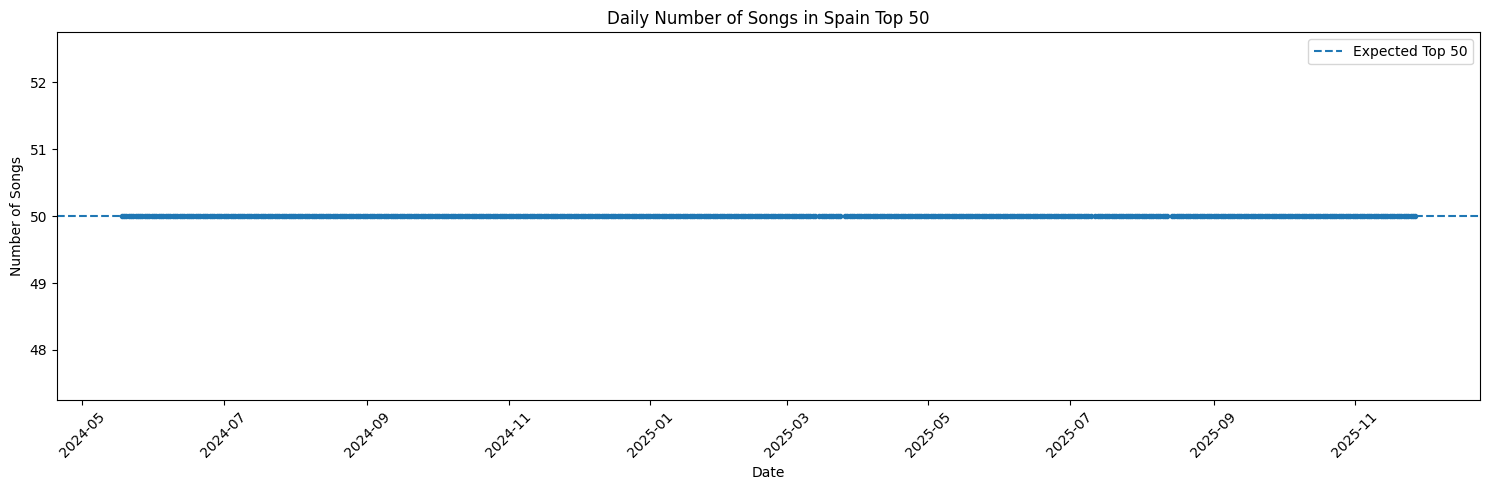

In [47]:
# Visualize daily song counts
plt.figure(figsize=(15, 5))

plt.plot(
    daily_count["date"],
    daily_count["song_count"],
    marker="o",
    markersize=3
)

plt.axhline(
    50,
    linestyle="--",
    label="Expected Top 50"
)

plt.title("Daily Number of Songs in Spain Top 50")
plt.xlabel("Date")
plt.ylabel("Number of Songs")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

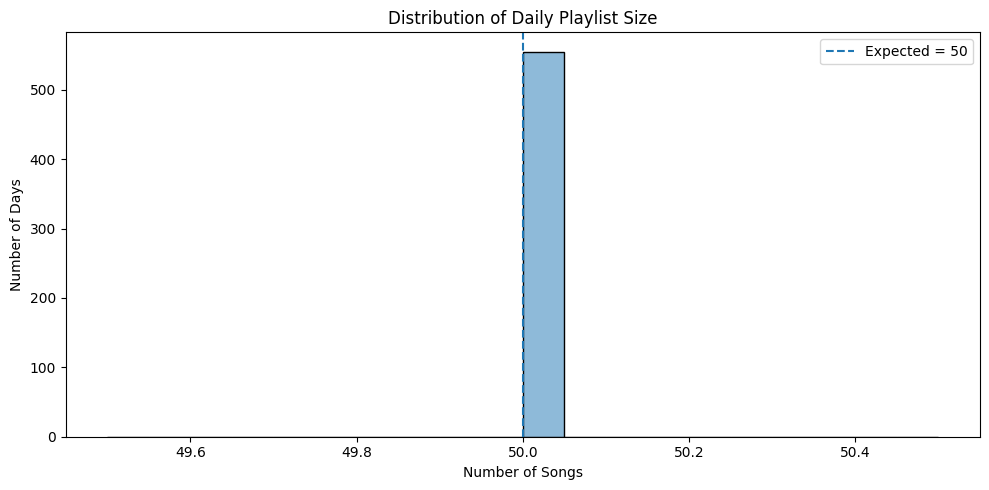

In [48]:
# Distribution of daily playlist size
plt.figure(figsize=(10, 5))

sns.histplot(
    daily_count["song_count"],
    bins=20,
    kde=True
)

plt.axvline(
    50,
    linestyle="--",
    label="Expected = 50"
)

plt.title("Distribution of Daily Playlist Size")
plt.xlabel("Number of Songs")
plt.ylabel("Number of Days")
plt.legend()
plt.tight_layout()
plt.show()

In [49]:
# Save validation report
validation_report.to_csv(
    "Spain_Top50_Daily_Validation.csv",
    index=False
)

invalid_song_count.to_csv(
    "Spain_Top50_Invalid_Dates.csv",
    index=False
)

print("Validation reports saved successfully.")

Validation reports saved successfully.


In [50]:
# Final Module 2 check
print("=" * 60)
print("COMPLETED")
print("=" * 60)

if invalid_days == 0:
    print("All dates contain a valid Top 50.")
else:
    print(f"⚠ {invalid_days} dates require investigation.")

print(f"Total dates checked: {total_days}")
print(f"Valid dates: {valid_days}")
print(f"Invalid dates: {invalid_days}")

COMPLETED
All dates contain a valid Top 50.
Total dates checked: 555
Valid dates: 555
Invalid dates: 0


# EDA:

In [51]:
# Basic dataset overview
print("=" * 60)
print("EXPLORATORY DATA ANALYSIS")
print("=" * 60)

print("Dataset Shape:", df.shape)
print("Number of Unique Songs:", df["track_key"].nunique())
print("Number of Unique Artists:", df["artist_key"].nunique())
print("Number of Days:", df["date"].nunique())

print("\nDate Range:")
print(df["date"].min(), "to", df["date"].max())

EXPLORATORY DATA ANALYSIS
Dataset Shape: (27750, 14)
Number of Unique Songs: 575
Number of Unique Artists: 301
Number of Days: 555

Date Range:
2024-05-18 00:00:00 to 2025-11-27 00:00:00


In [52]:
# Descriptive statistics
df[
    [
        "position",
        "popularity",
        "duration_ms",
        "duration_min",
        "total_tracks"
    ]
].describe().T

,count,mean,std,min,25%,50%,75%,max
position,27750.0,25.500000,14.431130,1.000000,13.0000,25.500000,38.000000,50.000000
popularity,27750.0,81.118847,10.092437,0.000000,76.0000,82.000000,87.000000,100.000000
duration_ms,27750.0,197472.995207,43386.424437,90613.000000,168594.0000,191254.000000,218119.000000,555071.000000
duration_min,27750.0,3.291217,0.723107,1.510217,2.8099,3.187567,3.635317,9.251183
total_tracks,27750.0,7.204685,7.684289,1.000000,1.0000,1.000000,15.000000,49.000000


In [53]:
# Check categorical variables
print("Album Type Distribution:")
print(df["album_type"].value_counts())

print("\nExplicit Content Distribution:")
print(df["is_explicit"].value_counts(dropna=False))

Album Type Distribution:
album_type
single    16009
album     11741
Name: count, dtype: int64

Explicit Content Distribution:
is_explicit
False    16115
True     11635
Name: count, dtype: int64


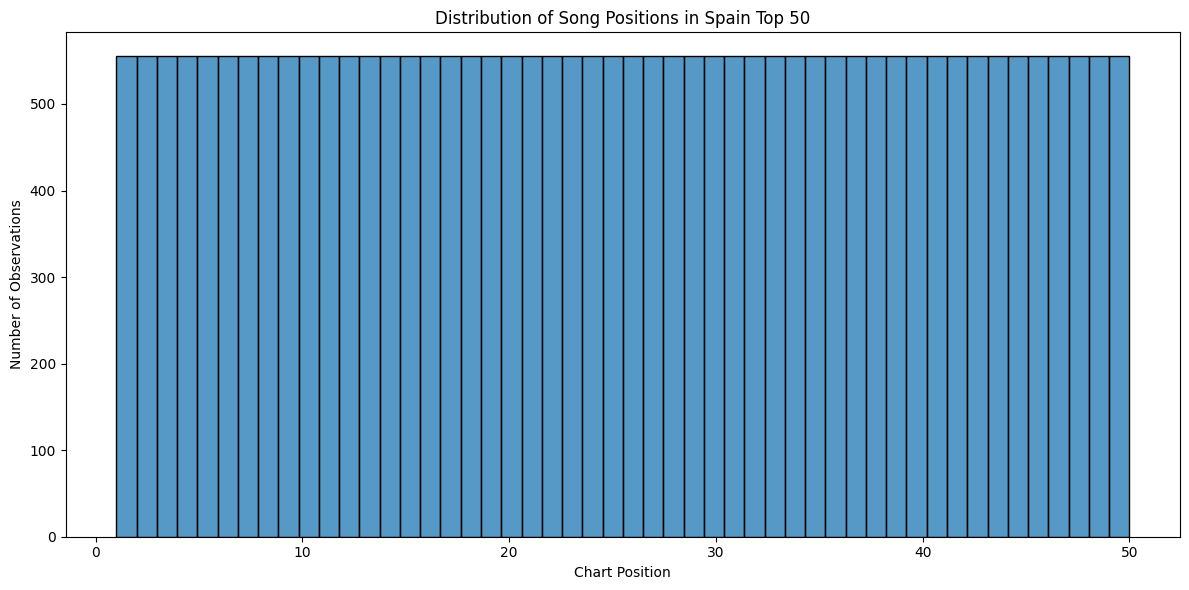

In [54]:
# Position distribution
plt.figure(figsize=(12, 6))

sns.histplot(
    data=df,
    x="position",
    bins=50,
    kde=False
)

plt.title("Distribution of Song Positions in Spain Top 50")
plt.xlabel("Chart Position")
plt.ylabel("Number of Observations")
plt.tight_layout()
plt.show()

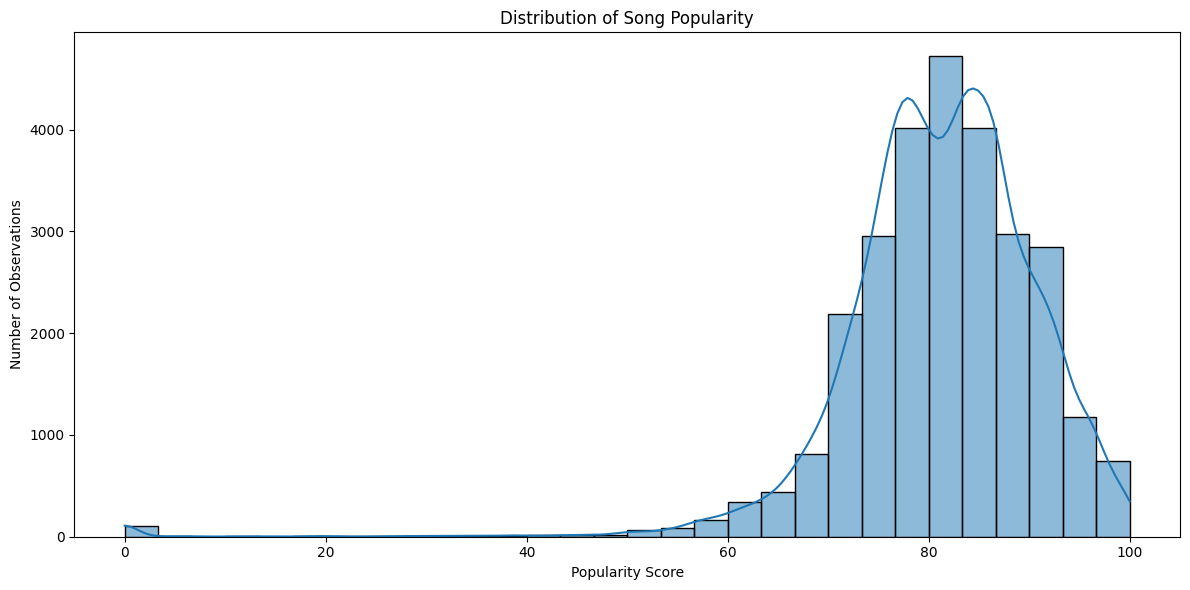

In [55]:
# Popularity distribution
plt.figure(figsize=(12, 6))

sns.histplot(
    data=df,
    x="popularity",
    bins=30,
    kde=True
)

plt.title("Distribution of Song Popularity")
plt.xlabel("Popularity Score")
plt.ylabel("Number of Observations")
plt.tight_layout()
plt.show()

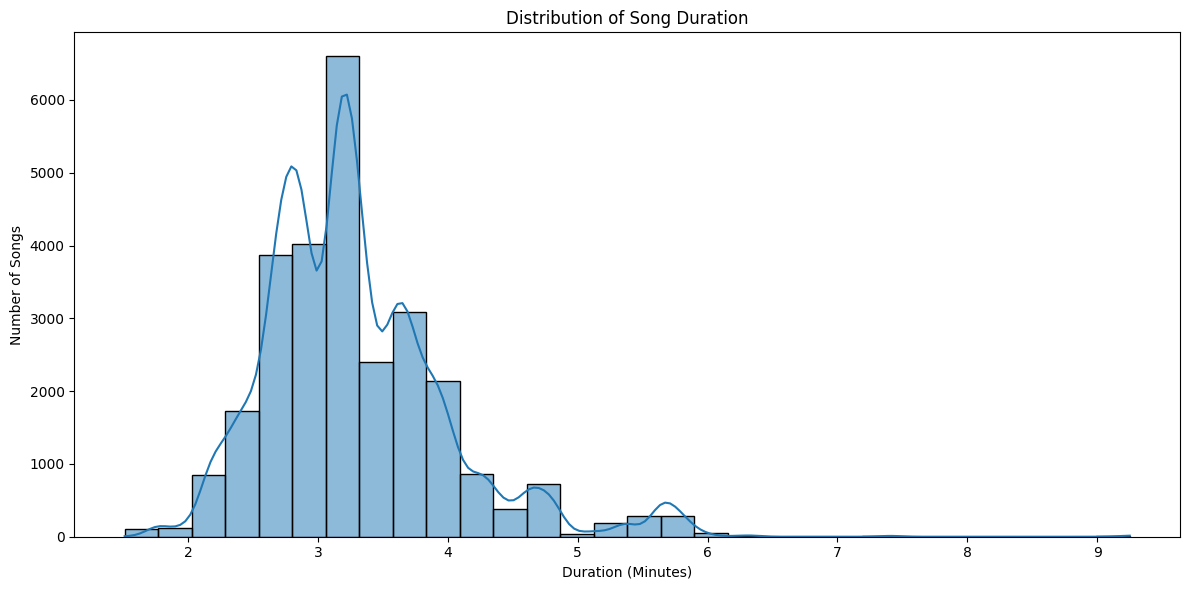

In [56]:
# Duration distribution
plt.figure(figsize=(12, 6))

sns.histplot(
    data=df,
    x="duration_min",
    bins=30,
    kde=True
)

plt.title("Distribution of Song Duration")
plt.xlabel("Duration (Minutes)")
plt.ylabel("Number of Songs")
plt.tight_layout()
plt.show()

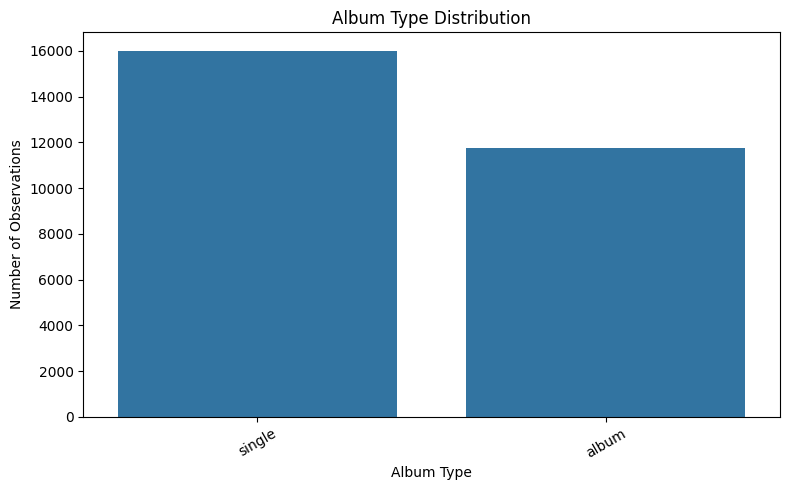

In [57]:
# Album type distribution
album_counts = df["album_type"].value_counts()

plt.figure(figsize=(8, 5))

sns.barplot(
    x=album_counts.index,
    y=album_counts.values
)

plt.title("Album Type Distribution")
plt.xlabel("Album Type")
plt.ylabel("Number of Observations")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

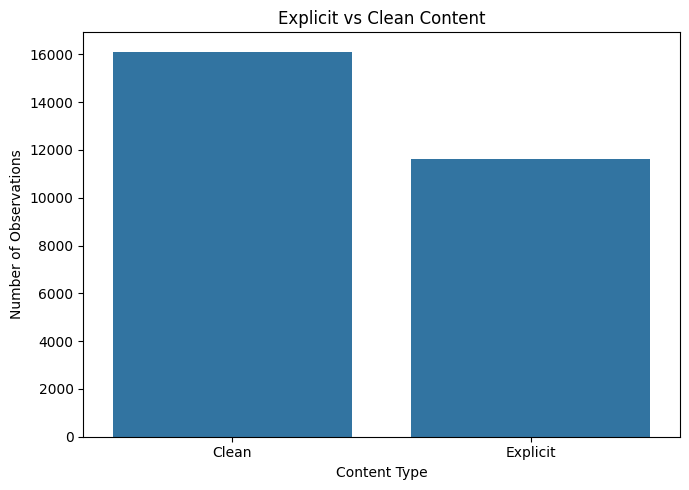

In [58]:
# Explicit vs Clean distribution
explicit_counts = (
    df["is_explicit"]
    .map({
        True: "Explicit",
        False: "Clean"
    })
    .value_counts()
)

plt.figure(figsize=(7, 5))

sns.barplot(
    x=explicit_counts.index,
    y=explicit_counts.values
)

plt.title("Explicit vs Clean Content")
plt.xlabel("Content Type")
plt.ylabel("Number of Observations")
plt.tight_layout()
plt.show()

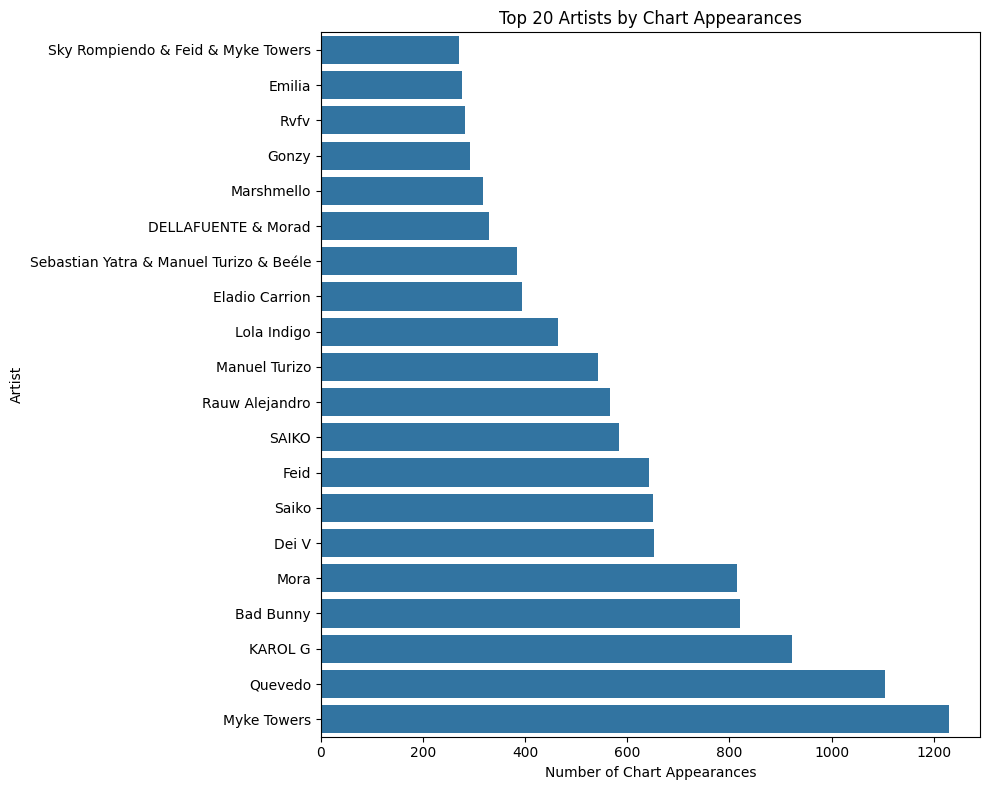

In [59]:
# Top 20 artists by number of appearances
top_artists = (
    df["artist"]
    .value_counts()
    .head(20)
    .sort_values()
)

plt.figure(figsize=(10, 8))

sns.barplot(
    x=top_artists.values,
    y=top_artists.index
)

plt.title("Top 20 Artists by Chart Appearances")
plt.xlabel("Number of Chart Appearances")
plt.ylabel("Artist")
plt.tight_layout()
plt.show()

In [60]:
# Top 20 most frequently appearing songs
top_songs = (
    df.groupby(["song", "artist"])
      .size()
      .reset_index(name="appearances")
      .sort_values("appearances", ascending=False)
      .head(20)
)

top_songs

,song,artist,appearances
288,La Bachata,Manuel Turizo,538
111,Columbia,Quevedo,463
537,VAGABUNDO,Sebastian Yatra & Manuel Turizo & Beéle,385
265,LA FALDA,Myke Towers,359
284,LUNA,Feid,357
423,QLONA,KAROL G,342
336,Manos Rotas,DELLAFUENTE & Morad,329
173,El Merengue,Marshmello,317
277,LALA,Myke Towers,310
43,BABY HELLO,Rauw Alejandro,282


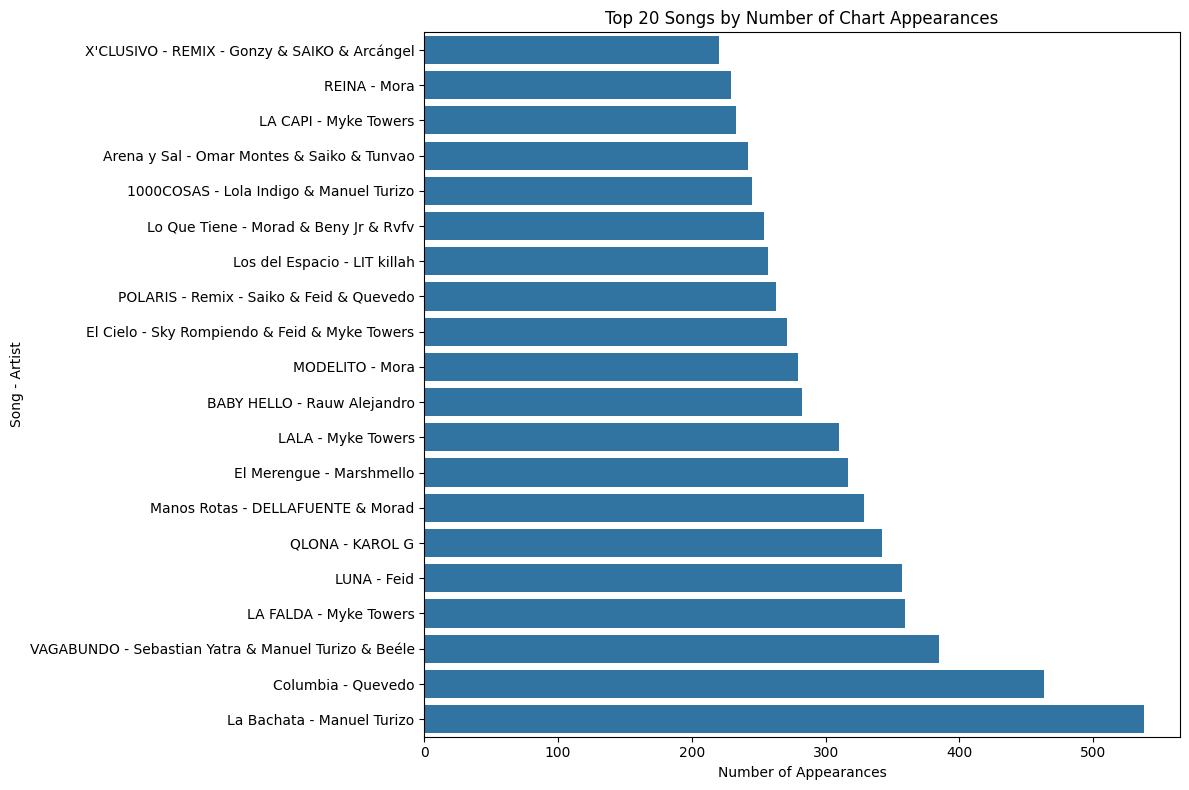

In [61]:
# Visualize them:

top_songs_plot = top_songs.copy()

top_songs_plot["label"] = (
    top_songs_plot["song"] +
    " - " +
    top_songs_plot["artist"]
)

top_songs_plot = top_songs_plot.sort_values("appearances")

plt.figure(figsize=(12, 8))

sns.barplot(
    data=top_songs_plot,
    x="appearances",
    y="label"
)

plt.title("Top 20 Songs by Number of Chart Appearances")
plt.xlabel("Number of Appearances")
plt.ylabel("Song - Artist")
plt.tight_layout()
plt.show()

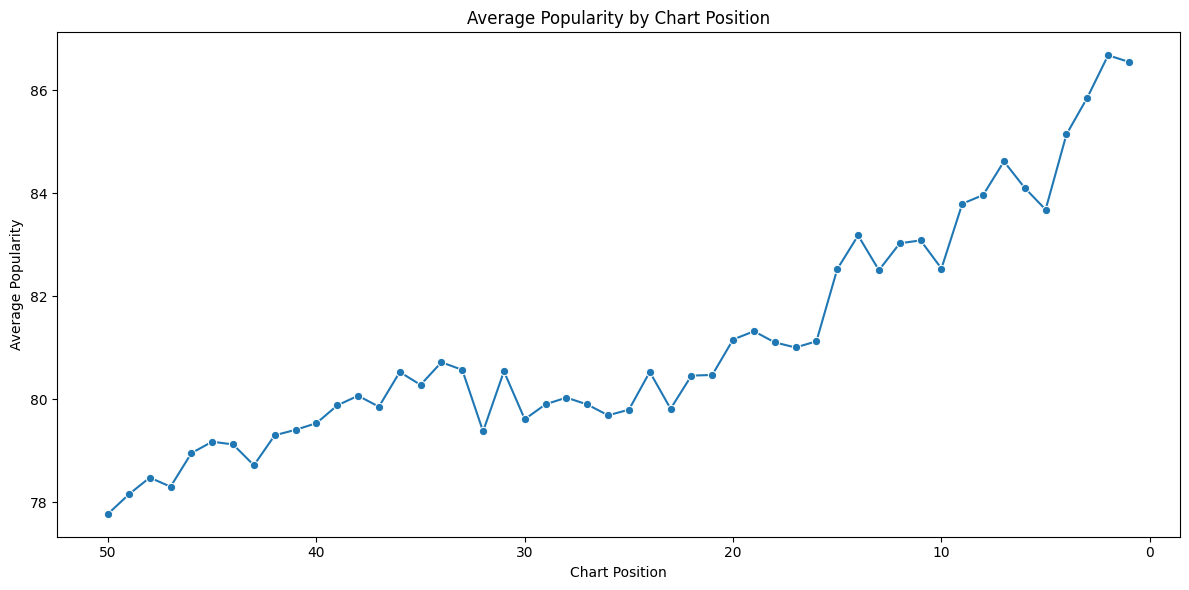

In [62]:
# Average popularity by chart position
position_popularity = (
    df.groupby("position")["popularity"]
      .mean()
      .reset_index()
)

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=position_popularity,
    x="position",
    y="popularity",
    marker="o"
)

plt.title("Average Popularity by Chart Position")
plt.xlabel("Chart Position")
plt.ylabel("Average Popularity")

plt.gca().invert_xaxis()

plt.tight_layout()
plt.show()

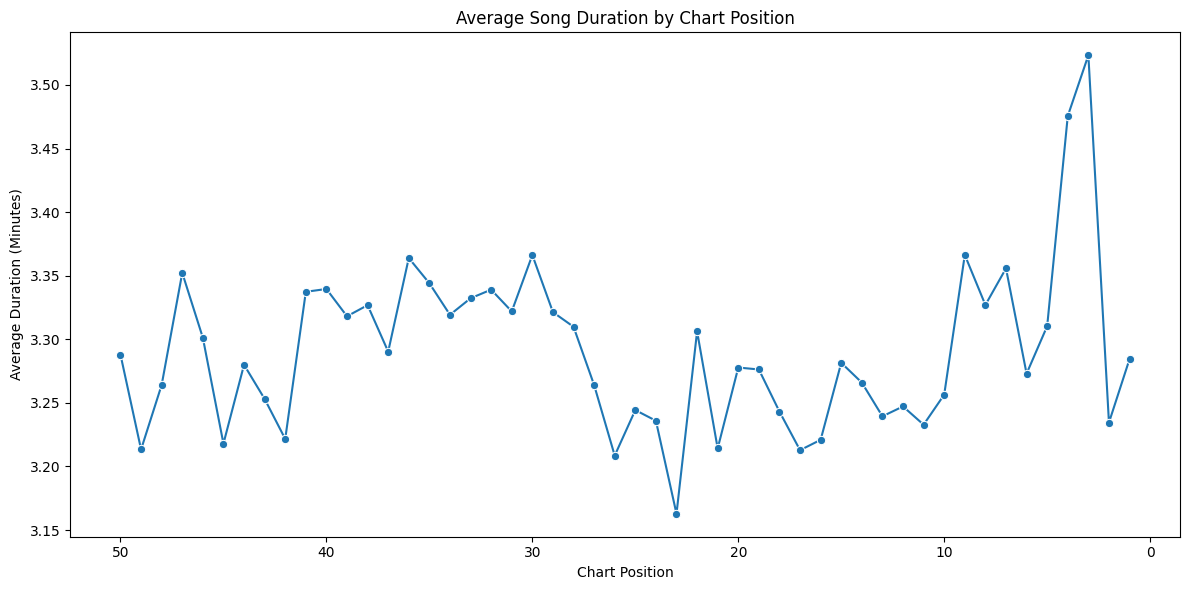

In [63]:
# Average duration by chart position
position_duration = (
    df.groupby("position")["duration_min"]
      .mean()
      .reset_index()
)

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=position_duration,
    x="position",
    y="duration_min",
    marker="o"
)

plt.title("Average Song Duration by Chart Position")
plt.xlabel("Chart Position")
plt.ylabel("Average Duration (Minutes)")

plt.gca().invert_xaxis()

plt.tight_layout()
plt.show()

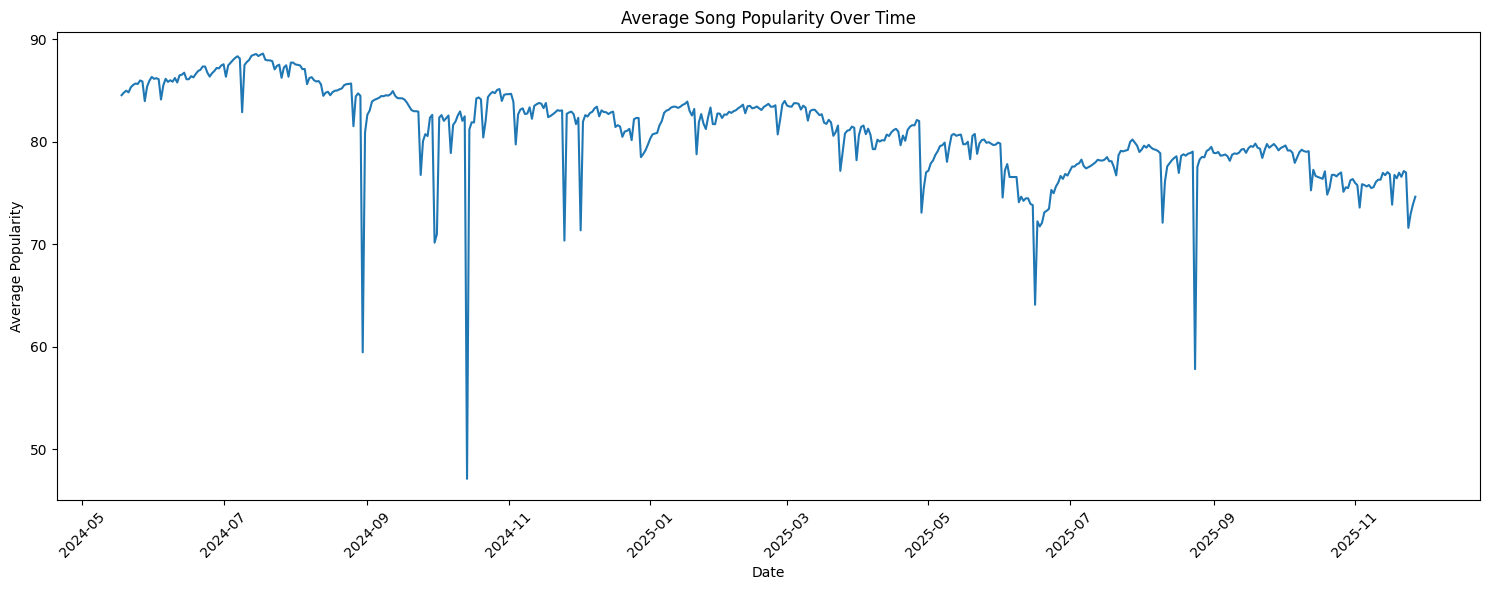

In [64]:
# Popularity over time
daily_popularity = (
    df.groupby("date")["popularity"]
      .mean()
      .reset_index()
)

plt.figure(figsize=(15, 6))

sns.lineplot(
    data=daily_popularity,
    x="date",
    y="popularity"
)

plt.title("Average Song Popularity Over Time")
plt.xlabel("Date")
plt.ylabel("Average Popularity")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

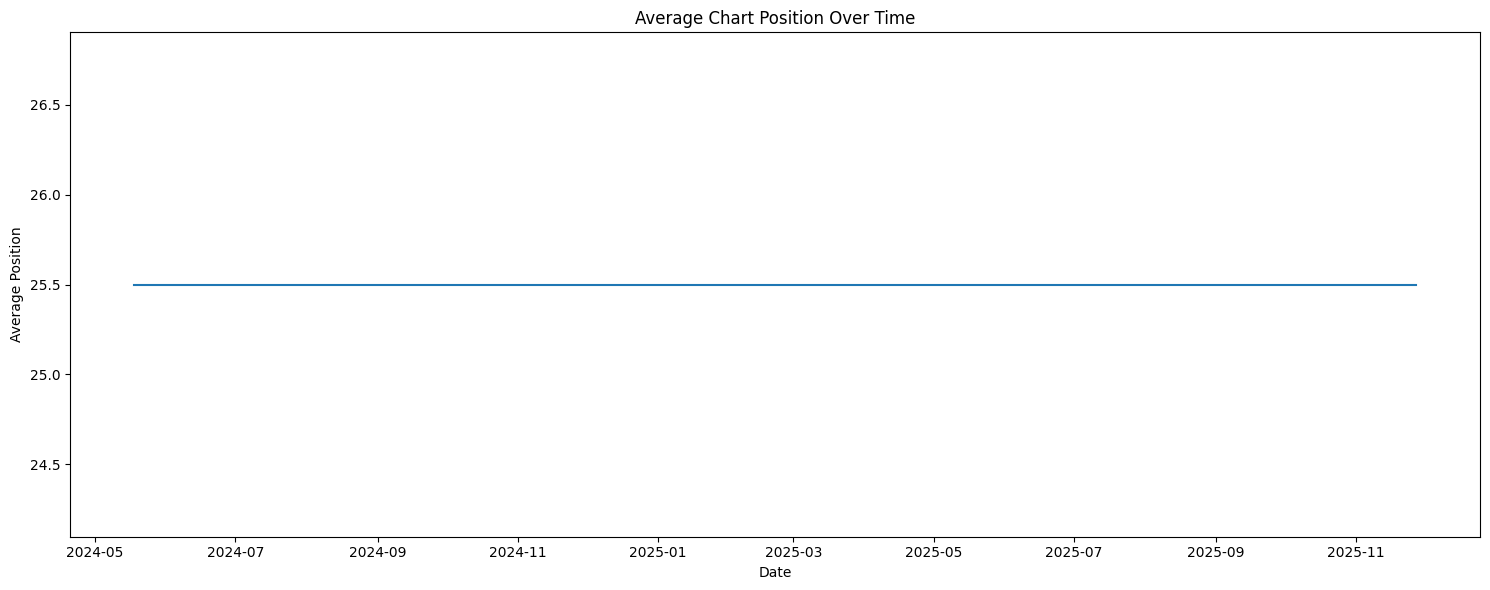

In [65]:
# Average chart position over time
daily_position = (
    df.groupby("date")["position"]
      .mean()
      .reset_index()
)

plt.figure(figsize=(15, 6))

sns.lineplot(
    data=daily_position,
    x="date",
    y="position"
)

plt.title("Average Chart Position Over Time")
plt.xlabel("Date")
plt.ylabel("Average Position")

plt.tight_layout()
plt.show()

In [66]:
# Explicit vs Clean popularity
explicit_popularity = (
    df.groupby("is_explicit")["popularity"]
      .agg(["mean", "median", "min", "max", "count"])
      .reset_index()
)

explicit_popularity["Content_Type"] = (
    explicit_popularity["is_explicit"]
    .map({
        True: "Explicit",
        False: "Clean"
    })
)

explicit_popularity

,is_explicit,mean,median,min,max,count,Content_Type
0,False,80.163388,81.0,0,100,16115,Clean
1,True,82.442200,83.0,0,100,11635,Explicit


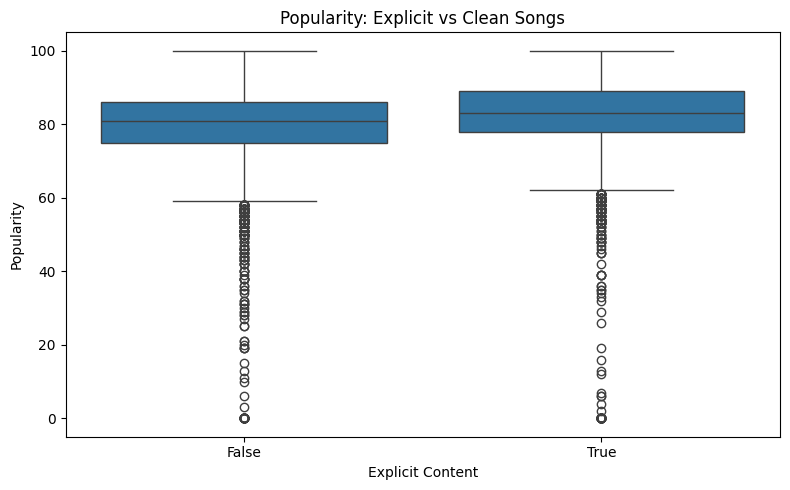

In [67]:
# Visualize:

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="is_explicit",
    y="popularity"
)

plt.title("Popularity: Explicit vs Clean Songs")
plt.xlabel("Explicit Content")
plt.ylabel("Popularity")

plt.tight_layout()
plt.show()

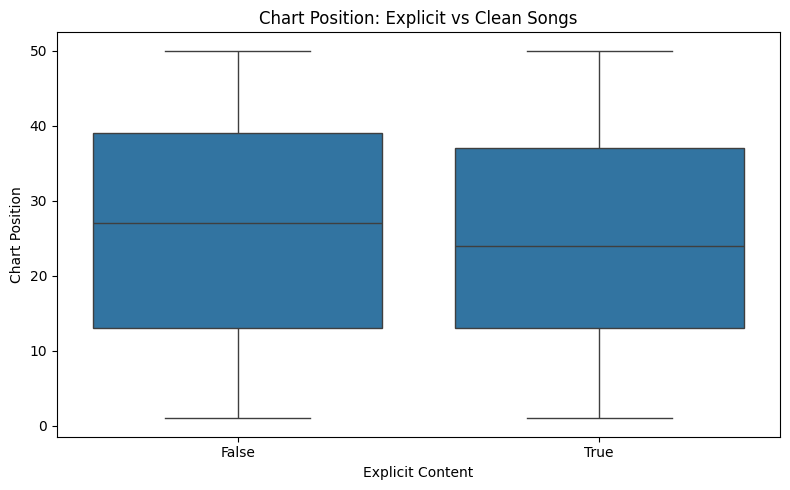

In [68]:
# Explicit vs Clean chart position
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="is_explicit",
    y="position"
)

plt.title("Chart Position: Explicit vs Clean Songs")
plt.xlabel("Explicit Content")
plt.ylabel("Chart Position")

plt.tight_layout()
plt.show()

# lower position number = better chart performance.

In [69]:
# Album type vs popularity
album_popularity = (
    df.groupby("album_type")["popularity"]
      .agg(["mean", "median", "count"])
      .reset_index()
)

album_popularity

,album_type,mean,median,count
0,album,80.151861,82.0,11741
1,single,81.828034,82.0,16009


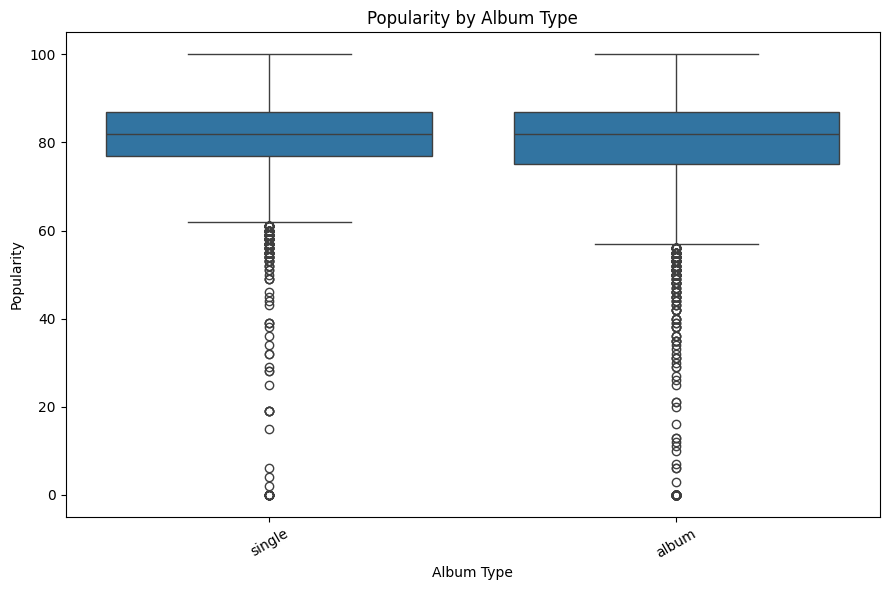

In [70]:
plt.figure(figsize=(9, 6))

sns.boxplot(
    data=df,
    x="album_type",
    y="popularity"
)

plt.title("Popularity by Album Type")
plt.xlabel("Album Type")
plt.ylabel("Popularity")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

In [71]:
# Correlation analysis
correlation_columns = [
    "position",
    "popularity",
    "duration_ms",
    "duration_min",
    "total_tracks"
]

corr_matrix = df[correlation_columns].corr()

corr_matrix

,position,popularity,duration_ms,duration_min,total_tracks
position,1.000000,-0.200207,-0.009045,-0.009045,0.074660
popularity,-0.200207,1.000000,0.033137,0.033137,-0.053805
duration_ms,-0.009045,0.033137,1.000000,1.000000,-0.101238
duration_min,-0.009045,0.033137,1.000000,1.000000,-0.101238
total_tracks,0.074660,-0.053805,-0.101238,-0.101238,1.000000


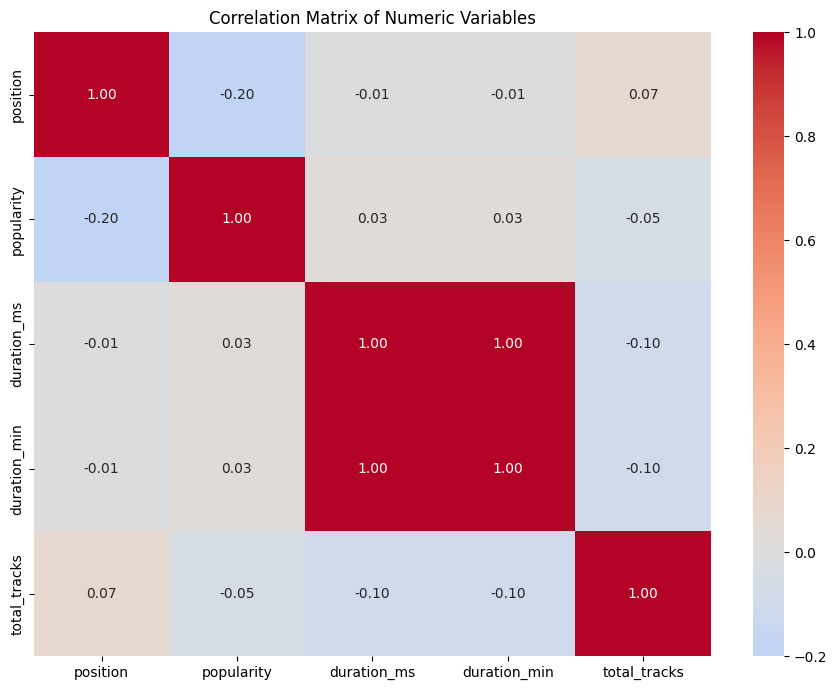

In [72]:
# Heatmap:

plt.figure(figsize=(9, 7))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Numeric Variables")
plt.tight_layout()
plt.show()

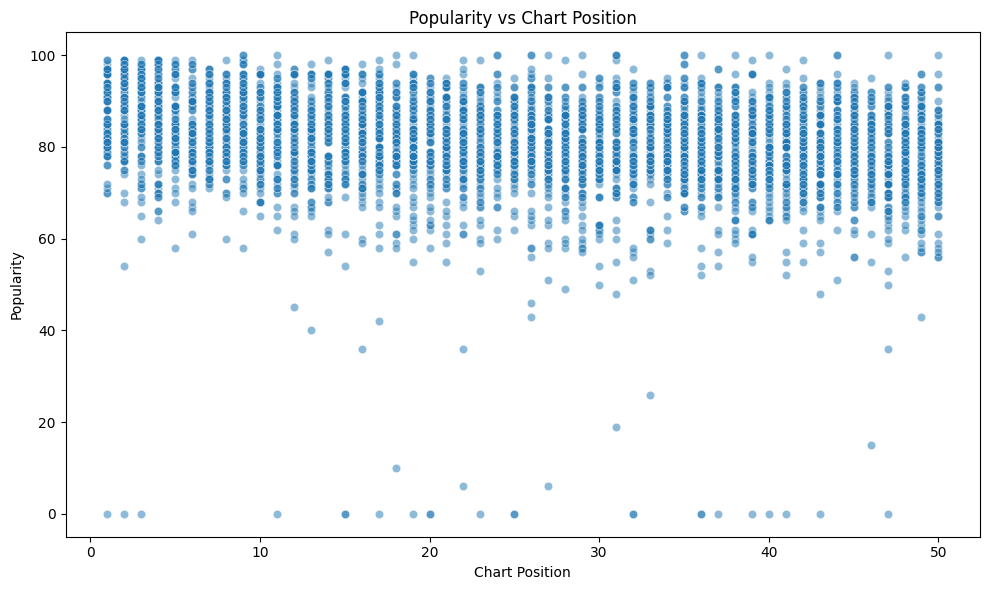

In [73]:
# Popularity vs chart position
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df.sample(
        min(5000, len(df)),
        random_state=42
    ),
    x="position",
    y="popularity",
    alpha=0.5
)

plt.title("Popularity vs Chart Position")
plt.xlabel("Chart Position")
plt.ylabel("Popularity")

plt.tight_layout()
plt.show()

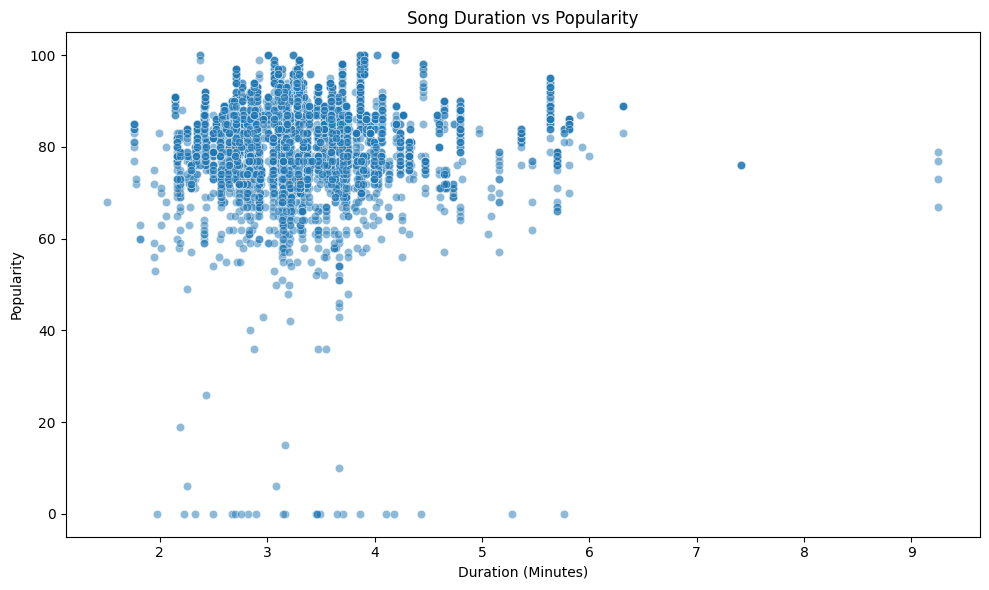

In [74]:
# Duration vs popularity
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df.sample(
        min(5000, len(df)),
        random_state=42
    ),
    x="duration_min",
    y="popularity",
    alpha=0.5
)

plt.title("Song Duration vs Popularity")
plt.xlabel("Duration (Minutes)")
plt.ylabel("Popularity")

plt.tight_layout()
plt.show()

In [75]:
# Number of unique songs by month
df["month"] = df["date"].dt.to_period("M")

monthly_unique_songs = (
    df.groupby("month")["track_key"]
      .nunique()
      .reset_index(name="unique_songs")
)

monthly_unique_songs["month"] = (
    monthly_unique_songs["month"]
    .astype(str)
)

monthly_unique_songs.head()

,month,unique_songs
0,2024-05,64
1,2024-06,74
2,2024-07,72
3,2024-08,79
4,2024-09,84


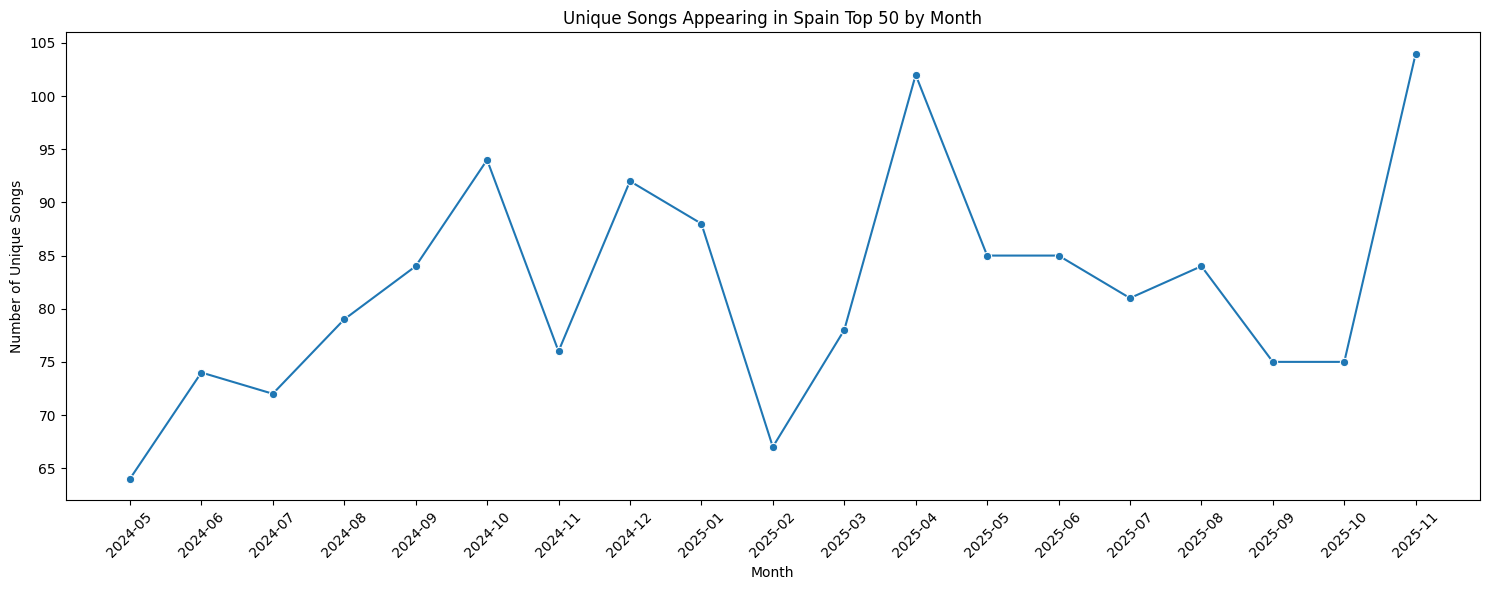

In [76]:
# Plot:

plt.figure(figsize=(15, 6))

sns.lineplot(
    data=monthly_unique_songs,
    x="month",
    y="unique_songs",
    marker="o"
)

plt.title("Unique Songs Appearing in Spain Top 50 by Month")
plt.xlabel("Month")
plt.ylabel("Number of Unique Songs")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [77]:
# Monthly explicit content percentage
monthly_explicit = (
    df.groupby("month")["is_explicit"]
      .mean()
      .reset_index(name="explicit_percentage")
)

monthly_explicit["explicit_percentage"] *= 100

monthly_explicit["month"] = (
    monthly_explicit["month"]
    .astype(str)
)

monthly_explicit.head()

,month,explicit_percentage
0,2024-05,30.142857
1,2024-06,37.466667
2,2024-07,39.161290
3,2024-08,41.225806
4,2024-09,38.733333


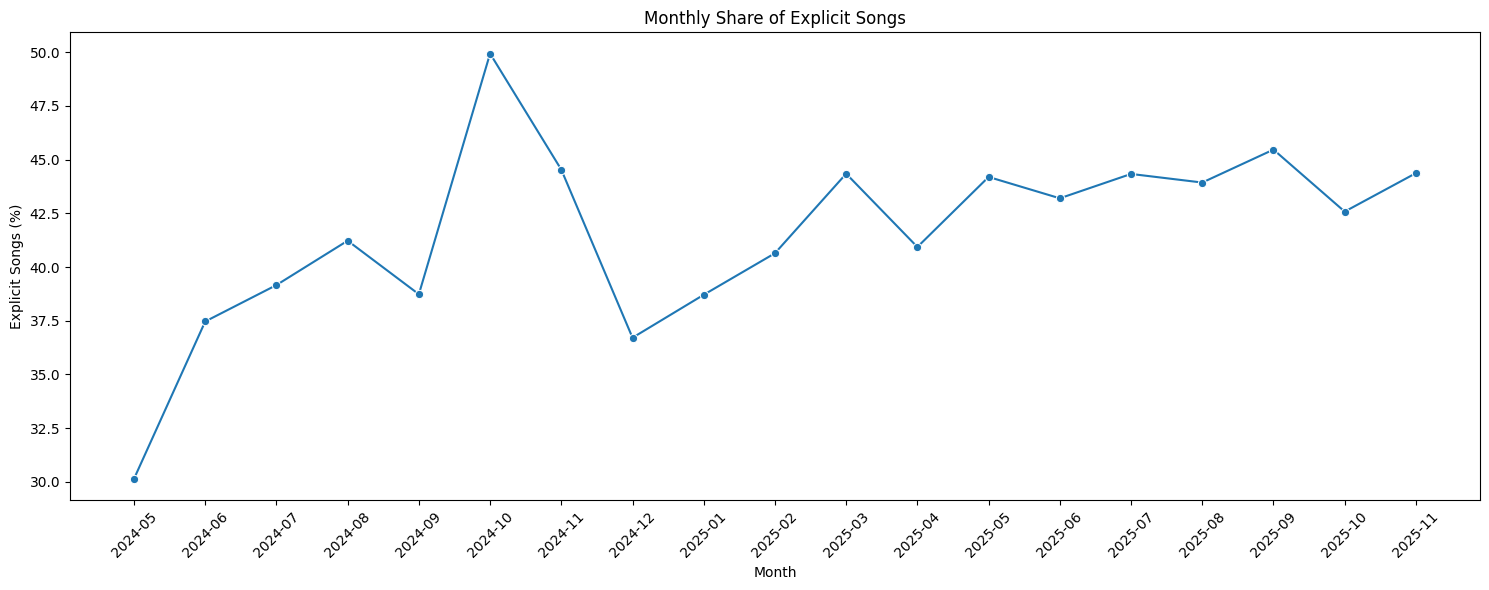

In [78]:
plt.figure(figsize=(15, 6))

sns.lineplot(
    data=monthly_explicit,
    x="month",
    y="explicit_percentage",
    marker="o"
)

plt.title("Monthly Share of Explicit Songs")
plt.xlabel("Month")
plt.ylabel("Explicit Songs (%)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [79]:
# Create EDA summary table
eda_summary = pd.DataFrame({
    "Metric": [
        "Total Observations",
        "Unique Songs",
        "Unique Artists",
        "Number of Days",
        "Average Popularity",
        "Median Popularity",
        "Average Duration (min)",
        "Median Duration (min)",
        "Average Chart Position",
        "Explicit Content %",
        "Clean Content %"
    ],
    
    "Value": [
        len(df),
        df["track_key"].nunique(),
        df["artist_key"].nunique(),
        df["date"].nunique(),
        df["popularity"].mean(),
        df["popularity"].median(),
        df["duration_min"].mean(),
        df["duration_min"].median(),
        df["position"].mean(),
        df["is_explicit"].mean() * 100,
        (1 - df["is_explicit"].mean()) * 100
    ]
})

eda_summary

,Metric,Value
0,Total Observations,27750.000000
1,Unique Songs,575.000000
2,Unique Artists,301.000000
3,Number of Days,555.000000
4,Average Popularity,81.118847
5,Median Popularity,82.000000
6,Average Duration (min),3.291217
7,Median Duration (min),3.187567
8,Average Chart Position,25.500000
9,Explicit Content %,41.927928


In [80]:
# Save EDA outputs
eda_summary.to_csv(
    "Spain_Top50_EDA_Summary.csv",
    index=False
)

position_popularity.to_csv(
    "Position_Popularity_Analysis.csv",
    index=False
)

monthly_unique_songs.to_csv(
    "Monthly_Unique_Songs.csv",
    index=False
)

monthly_explicit.to_csv(
    "Monthly_Explicit_Content.csv",
    index=False
)

print("EDA output files saved successfully.")

EDA output files saved successfully.


In [81]:
# Final Module 3 check
print("=" * 60)
print("COMPLETED")
print("=" * 60)

print(f"Total observations : {len(df):,}")
print(f"Unique songs       : {df['track_key'].nunique():,}")
print(f"Unique artists     : {df['artist_key'].nunique():,}")
print(f"Days covered       : {df['date'].nunique():,}")
print(
    f"Average popularity : "
    f"{df['popularity'].mean():.2f}"
)
print(
    f"Average duration   : "
    f"{df['duration_min'].mean():.2f} minutes"
)
print(
    f"Explicit share     : "
    f"{df['is_explicit'].mean() * 100:.2f}%"
)

COMPLETED
Total observations : 27,750
Unique songs       : 575
Unique artists     : 301
Days covered       : 555
Average popularity : 81.12
Average duration   : 3.29 minutes
Explicit share     : 41.93%


# Song Lifecycle Analysis:
har unique song ke liye Entry Date, Exit Date, Days on Playlist, Peak Position, Time to Peak, Rank Movement, Popularity Movement etc. calculate karenge

In [82]:
# Sort the data

df = df.sort_values(
    ["track_key", "date", "position"]
).reset_index(drop=True)

print("Data sorted successfully.")
df.head()

Data sorted successfully.


,date,position,song,artist,popularity,duration_ms,album_type,total_tracks,is_explicit,album_cover_url,duration_min,song_key,artist_key,track_key,month
0,2025-06-02,40,0 CONFIANZA,Rvfv,35,217500,album,20,False,https://i.scdn.co/image/ab67616d0000b273c172e8...,3.625,0 confianza,rvfv,0 confianza | rvfv,2025-06
1,2025-06-05,31,0 CONFIANZA,Rvfv,57,217500,album,20,False,https://i.scdn.co/image/ab67616d0000b273c172e8...,3.625,0 confianza,rvfv,0 confianza | rvfv,2025-06
2,2025-06-06,25,0 CONFIANZA,Rvfv,57,217500,album,20,False,https://i.scdn.co/image/ab67616d0000b273c172e8...,3.625,0 confianza,rvfv,0 confianza | rvfv,2025-06
3,2025-06-07,23,0 CONFIANZA,Rvfv,57,217500,album,20,False,https://i.scdn.co/image/ab67616d0000b273c172e8...,3.625,0 confianza,rvfv,0 confianza | rvfv,2025-06
4,2025-06-08,23,0 CONFIANZA,Rvfv,57,217500,album,20,False,https://i.scdn.co/image/ab67616d0000b273c172e8...,3.625,0 confianza,rvfv,0 confianza | rvfv,2025-06


In [83]:
# Create lifecycle table
lifecycle = (
    df.groupby("track_key")  # Hum data ko track_key ke basis par group kar rahe hain. Humne pehle banaya tha: song_key + artist_key = track_key
      .agg(
          song=("song", "first"),
          artist=("artist", "first"),
          
          entry_date=("date", "min"), # min ka matlab minimum/earliest date
          exit_date=("date", "max"),
          
          entry_position=("position", "first"),  # Song jab first time chart mein enter hua, tab uski position kya thi.
          best_position=("position", "min"),  # Chart mein 1 highest/best position hai. Isliye min use kiya.
          exit_position=("position", "last"),
          
          observations=("date", "nunique"),  # unique dates count karna
          
          entry_popularity=("popularity", "first"),  # Song jab first time observe hua, tab uski popularity kya thi.
          peak_popularity=("popularity", "max"),  # Song ki maximum popularity
          exit_popularity=("popularity", "last"),  # Song ki last observation par popularity
          
          album_type=("album_type", "first"),  # Song ka album type liya ja raha hai. first isliye kyunki same track ke liye generally ye information same hoti hai.
          total_tracks=("total_tracks", "first"),  # Song jis album ka part hai, us album mein total kitne tracks hain.
          is_explicit=("is_explicit", "first"),  # Song explicit hai ya nahi:
          duration_min=("duration_min", "first")  # Song ki duration minutes mein
      )
      .reset_index()  # reset_index() usko normal column bana deta hai.
)

lifecycle.head()

# Humhara project hai Content Maturity, Release Lifecycle & Playlist Rotation Analysis. Isliye humein har song ke liye ye questions answer karne hain:
# Song chart mein kab enter hua? → entry_date
# Kab tak raha? → exit_date
# Kitni baar/din chart mein dikha? → observations
# Sabse best rank kya thi? → best_position
# Entry par rank kya thi? → entry_position
# Exit par rank kya thi? → exit_position
# Popularity peak kitni hui? → peak_popularity
# Phir isi lifecycle table se hum calculate kar sakte hain:
# Song Age, Chart Longevity, Peak Performance, Popularity Growth, Popularity Decline, Early Exit, Long-Term Survivor, Fresh vs Mature Content, Playlist Rotation

,track_key,song,artist,entry_date,exit_date,entry_position,best_position,exit_position,observations,entry_popularity,peak_popularity,exit_popularity,album_type,total_tracks,is_explicit,duration_min
0,0 confianza | rvfv,0 CONFIANZA,Rvfv,2025-06-02,2025-06-23,40,23,42,20,35,62,62,album,20,False,3.625000
1,"1 de enero, puntacana | rels b","1 de Enero, Puntacana",Rels B,2025-04-28,2025-04-28,45,45,45,1,65,65,65,album,13,False,1.583333
2,1000cosas | lola indigo & manuel turizo,1000COSAS,Lola Indigo & Manuel Turizo,2025-03-10,2025-11-13,3,3,44,245,65,81,72,single,1,False,3.991367
3,100xciento | foreign teck & eladio carrion & d...,100xCiento,Foreign Teck & Eladio Carrion & De La Ghetto,2025-04-30,2025-05-15,42,13,37,11,72,75,75,single,1,True,3.661367
4,14 febreros | quevedo,14 FEBREROS,Quevedo,2025-11-24,2025-11-27,9,9,16,4,63,68,68,album,18,True,2.873700


In [84]:
# Calculate days on playlist
lifecycle["calendar_days"] = (
    lifecycle["exit_date"] -
    lifecycle["entry_date"]
).dt.days + 1

lifecycle["days_on_playlist"] = lifecycle["calendar_days"]

lifecycle[
    [
        "song",
        "artist",
        "entry_date",
        "exit_date",
        "days_on_playlist"
    ]
].head(20)

,song,artist,entry_date,exit_date,days_on_playlist
0,0 CONFIANZA,Rvfv,2025-06-02,2025-06-23,22
1,"1 de Enero, Puntacana",Rels B,2025-04-28,2025-04-28,1
2,1000COSAS,Lola Indigo & Manuel Turizo,2025-03-10,2025-11-13,249
3,100xCiento,Foreign Teck & Eladio Carrion & De La Ghetto,2025-04-30,2025-05-15,16
4,14 FEBREROS,Quevedo,2025-11-24,2025-11-27,4
5,2AM,Sebastian Yatra & Bad Gyal,2025-11-24,2025-11-27,4
6,2xLL,JC Reyes & YOVNGCHIMI & Slayter,2025-07-12,2025-08-09,29
7,3 CAÍDAS,SAIKO,2025-04-28,2025-05-05,8
8,4 PREZ,Cruz Cafuné,2024-05-28,2024-05-29,2
9,4TO 23,Aitana,2025-07-07,2025-07-16,10


In [85]:
# Calculate playlist continuity
# (This is important because a song may have a large date span but may not appear on every single day)

lifecycle["continuity"] = (
    lifecycle["observations"] /
    lifecycle["calendar_days"]
)

lifecycle["continuity_percentage"] = (
    lifecycle["continuity"] * 100
)

lifecycle[
    [
        "song",
        "observations",
        "calendar_days",
        "continuity_percentage"
    ]
].head(20)

,song,observations,calendar_days,continuity_percentage
0,0 CONFIANZA,20,22,90.909091
1,"1 de Enero, Puntacana",1,1,100.000000
2,1000COSAS,245,249,98.393574
3,100xCiento,11,16,68.750000
4,14 FEBREROS,4,4,100.000000
5,2AM,4,4,100.000000
6,2xLL,26,29,89.655172
7,3 CAÍDAS,8,8,100.000000
8,4 PREZ,2,2,100.000000
9,4TO 23,9,10,90.000000


In [86]:
# Calculate time to peak (har song ko apni best chart position tak pahunchne mein kitne din lage, ye calculate karna)
peak_dates = (
    df.loc[
        df.groupby("track_key")["position"].idxmin(),
        ["track_key", "date", "position"]
    ]
    .rename(
        columns={
            "date": "peak_date",
            "position": "peak_position_check"
        }
    )
)

lifecycle = lifecycle.merge(
    peak_dates,
    on="track_key",
    how="left"
)

lifecycle["time_to_peak_days"] = (
    lifecycle["peak_date"] -
    lifecycle["entry_date"]
).dt.days

lifecycle[
    [
        "song",
        "entry_date",
        "peak_date",
        "best_position",
        "time_to_peak_days"
    ]
].head(20)

,song,entry_date,peak_date,best_position,time_to_peak_days
0,0 CONFIANZA,2025-06-02,2025-06-07,23,5
1,"1 de Enero, Puntacana",2025-04-28,2025-04-28,45,0
2,1000COSAS,2025-03-10,2025-03-10,3,0
3,100xCiento,2025-04-30,2025-05-11,13,11
4,14 FEBREROS,2025-11-24,2025-11-24,9,0
5,2AM,2025-11-24,2025-11-27,31,3
6,2xLL,2025-07-12,2025-07-23,35,11
7,3 CAÍDAS,2025-04-28,2025-04-28,13,0
8,4 PREZ,2024-05-28,2024-05-28,35,0
9,4TO 23,2025-07-07,2025-07-07,17,0


In [87]:
# Calculate rank movement (We calculate the overall trend in chart position. Negative slope = song is improving, Positive slope = song is declining)

def calculate_rank_slope(group):
    group = group.sort_values("date")
    
    if len(group) < 2:
        return 0
    
    x = np.arange(len(group))
    y = group["position"].values
    
    return np.polyfit(x, y, 1)[0]


rank_slopes = (
    df.groupby("track_key")
      .apply(calculate_rank_slope, include_groups=False)
      .reset_index(name="rank_slope")
)

lifecycle = lifecycle.merge(
    rank_slopes,
    on="track_key",
    how="left"
)

lifecycle[
    [
        "song",
        "artist",
        "rank_slope"
    ]
].head(20)

,song,artist,rank_slope
0,0 CONFIANZA,Rvfv,0.388722
1,"1 de Enero, Puntacana",Rels B,0.000000
2,1000COSAS,Lola Indigo & Manuel Turizo,0.121004
3,100xCiento,Foreign Teck & Eladio Carrion & De La Ghetto,-0.963636
4,14 FEBREROS,Quevedo,2.400000
5,2AM,Sebastian Yatra & Bad Gyal,-3.800000
6,2xLL,JC Reyes & YOVNGCHIMI & Slayter,0.168889
7,3 CAÍDAS,SAIKO,4.714286
8,4 PREZ,Cruz Cafuné,11.000000
9,4TO 23,Aitana,4.150000


In [88]:
# Calculate popularity trend
def calculate_popularity_slope(group):
    group = group.sort_values("date")
    
    if len(group) < 2:
        return 0
    
    x = np.arange(len(group))
    y = group["popularity"].values
    
    return np.polyfit(x, y, 1)[0]


popularity_slopes = (
    df.groupby("track_key")
      .apply(
          calculate_popularity_slope,
          include_groups=False
      )
      .reset_index(name="popularity_slope")
)

lifecycle = lifecycle.merge(
    popularity_slopes,
    on="track_key",
    how="left"
)

lifecycle.head()

,track_key,song,artist,entry_date,exit_date,entry_position,best_position,exit_position,observations,entry_popularity,peak_popularity,exit_popularity,album_type,total_tracks,is_explicit,duration_min,calendar_days,days_on_playlist,continuity,continuity_percentage,peak_date,peak_position_check,time_to_peak_days,rank_slope,popularity_slope
0,0 confianza | rvfv,0 CONFIANZA,Rvfv,2025-06-02,2025-06-23,40,23,42,20,35,62,62,album,20,False,3.625000,22,22,0.909091,90.909091,2025-06-07,23,5,0.388722,0.584211
1,"1 de enero, puntacana | rels b","1 de Enero, Puntacana",Rels B,2025-04-28,2025-04-28,45,45,45,1,65,65,65,album,13,False,1.583333,1,1,1.000000,100.000000,2025-04-28,45,0,0.000000,0.000000
2,1000cosas | lola indigo & manuel turizo,1000COSAS,Lola Indigo & Manuel Turizo,2025-03-10,2025-11-13,3,3,44,245,65,81,72,single,1,False,3.991367,249,249,0.983936,98.393574,2025-03-10,3,0,0.121004,-0.027498
3,100xciento | foreign teck & eladio carrion & d...,100xCiento,Foreign Teck & Eladio Carrion & De La Ghetto,2025-04-30,2025-05-15,42,13,37,11,72,75,75,single,1,True,3.661367,16,16,0.687500,68.750000,2025-05-11,13,11,-0.963636,0.345455
4,14 febreros | quevedo,14 FEBREROS,Quevedo,2025-11-24,2025-11-27,9,9,16,4,63,68,68,album,18,True,2.873700,4,4,1.000000,100.000000,2025-11-24,9,0,2.400000,1.700000


In [89]:
# Calculate rank improvement (This makes interpretation easier)

lifecycle["rank_improvement"] = (
    lifecycle["entry_position"] -
    lifecycle["best_position"]
)

lifecycle["rank_change_entry_to_exit"] = (
    lifecycle["exit_position"] -
    lifecycle["entry_position"]
)

lifecycle[
    [
        "song",
        "entry_position",
        "best_position",
        "exit_position",
        "rank_improvement",
        "rank_change_entry_to_exit"
    ]
].head(20)

,song,entry_position,best_position,exit_position,rank_improvement,rank_change_entry_to_exit
0,0 CONFIANZA,40,23,42,17,2
1,"1 de Enero, Puntacana",45,45,45,0,0
2,1000COSAS,3,3,44,0,41
3,100xCiento,42,13,37,29,-5
4,14 FEBREROS,9,9,16,0,7
5,2AM,41,31,31,10,-10
6,2xLL,50,35,47,15,-3
7,3 CAÍDAS,13,13,47,0,34
8,4 PREZ,35,35,46,0,11
9,4TO 23,17,17,50,0,33


In [90]:
# Interpret rank movement
def rank_movement_label(slope):
    if slope < -0.75:
        return "Improving"
    elif slope > 0.75:
        return "Declining"
    else:
        return "Stable"


lifecycle["rank_movement"] = (
    lifecycle["rank_slope"]
    .apply(rank_movement_label)
)

lifecycle["rank_movement"].value_counts()

rank_movement
Stable       373
Declining    175
Improving     27
Name: count, dtype: int64

In [91]:
# Calculate popularity growth
lifecycle["popularity_change"] = (
    lifecycle["exit_popularity"] -
    lifecycle["entry_popularity"]
)

lifecycle["popularity_growth_percentage"] = np.where(
    lifecycle["entry_popularity"] > 0,
    (
        lifecycle["popularity_change"] /
        lifecycle["entry_popularity"]
    ) * 100,
    np.nan
)

lifecycle[
    [
        "song",
        "entry_popularity",
        "peak_popularity",
        "exit_popularity",
        "popularity_change",
        "popularity_growth_percentage"
    ]
].head(20)

,song,entry_popularity,peak_popularity,exit_popularity,popularity_change,popularity_growth_percentage
0,0 CONFIANZA,35,62,62,27,77.142857
1,"1 de Enero, Puntacana",65,65,65,0,0.000000
2,1000COSAS,65,81,72,7,10.769231
3,100xCiento,72,75,75,3,4.166667
4,14 FEBREROS,63,68,68,5,7.936508
5,2AM,55,64,64,9,16.363636
6,2xLL,61,71,71,10,16.393443
7,3 CAÍDAS,61,69,69,8,13.114754
8,4 PREZ,53,56,56,3,5.660377
9,4TO 23,58,69,69,11,18.965517


In [92]:
# Identify longest-lasting songs
longest_lived = (
    lifecycle
    .sort_values(
        "days_on_playlist",
        ascending=False
    )
    .head(20)
)

longest_lived[
    [
        "song",
        "artist",
        "days_on_playlist",
        "observations",
        "continuity_percentage",
        "best_position"
    ]
]

,song,artist,days_on_playlist,observations,continuity_percentage,best_position
265,La Bachata,Manuel Turizo,551,538,97.640653,11
29,AMARGURA,KAROL G,524,153,29.198473,16
546,VAGABUNDO,Sebastian Yatra & Manuel Turizo & Beéle,517,385,74.468085,3
97,Columbia,Quevedo,483,463,95.859213,1
293,LALA,Myke Towers,453,310,68.432671,1
524,TQG,KAROL G,448,120,26.785714,9
429,QLONA,KAROL G,427,342,80.093677,8
26,Amanece,Anuel AA & Haze,408,15,3.676471,47
167,El Merengue,Marshmello,380,317,83.421053,19
325,Manos Rotas,DELLAFUENTE & Morad,371,329,88.679245,1


In [93]:
# Identify fastest songs to reach peak
fastest_to_peak = (
    lifecycle[
        lifecycle["time_to_peak_days"].notna()
    ]
    .sort_values(
        "time_to_peak_days",
        ascending=True
    )
    .head(20)
)

fastest_to_peak[
    [
        "song",
        "artist",
        "entry_position",
        "best_position",
        "time_to_peak_days"
    ]
]

,song,artist,entry_position,best_position,time_to_peak_days
46,BABY NUEVA,Bad Bunny,12,12,0
7,3 CAÍDAS,SAIKO,13,13,0
8,4 PREZ,Cruz Cafuné,35,35,0
9,4TO 23,Aitana,17,17,0
10,50 PALOS,Feid,38,38,0
11,57,KAROL G & Feid & DFZM,8,8,0
12,58,JHAYCO,35,35,0
440,Qué Pecao,Manuel Turizo,34,34,0
31,Antes,Rvfv & Edu García,29,29,0
32,Antidepresivos,Saiko,13,13,0


In [94]:
# Identify songs with strongest improvement
strongest_growth = (
    lifecycle
    .sort_values(
        "rank_improvement",
        ascending=False
    )
    .head(20)
)

strongest_growth[
    [
        "song",
        "artist",
        "entry_position",
        "best_position",
        "rank_improvement"
    ]
]

,song,artist,entry_position,best_position,rank_improvement
24,All I Want for Christmas Is You,Mariah Carey,49,1,48
449,REAL GANGSTA LOVE,Trueno,49,1,48
486,Si No Estás,iñigo quintero,48,1,47
375,No Te Quieren Conmigo,Gaby Music & Lunay & Luar La L,50,4,46
404,PELIGROSA,FloyyMenor,49,3,46
352,MODELITO,Mora,50,4,46
296,Last Christmas - Single Version,Wham!,49,4,45
242,Holanda,Jhayco,47,3,44
419,Potra Salvaje - Hard Remix,Isabel Aaiún & Fernando Moreno,47,3,44
502,STAR,JC Reyes,50,7,43


In [95]:
# Identify declining songs
declining_songs = (
    lifecycle
    .sort_values(
        "rank_slope",
        ascending=False
    )
    .head(20)
)

declining_songs[
    [
        "song",
        "artist",
        "entry_position",
        "best_position",
        "exit_position",
        "rank_slope"
    ]
]

,song,artist,entry_position,best_position,exit_position,rank_slope
102,COMPETENCIA,Myke Towers,19,19,49,30.0
116,Cosa Nuestra,Rauw Alejandro,16,16,44,28.0
329,MAREA,Mora,24,24,49,25.0
42,AYER Y HOY,Mora,23,23,46,23.0
534,UN DESEO,Mora,20,20,42,22.0
108,Constelación,Duki & Lia Kali,29,29,50,21.0
475,SE TE NOTA (feat. Peso Pluma),Myke Towers,27,27,47,20.0
196,FERXXO 30,Feid,32,32,50,18.0
119,COSMETICOS,Myke Towers,33,33,48,15.0
22,ALAKRAN,Feid,24,24,48,12.0


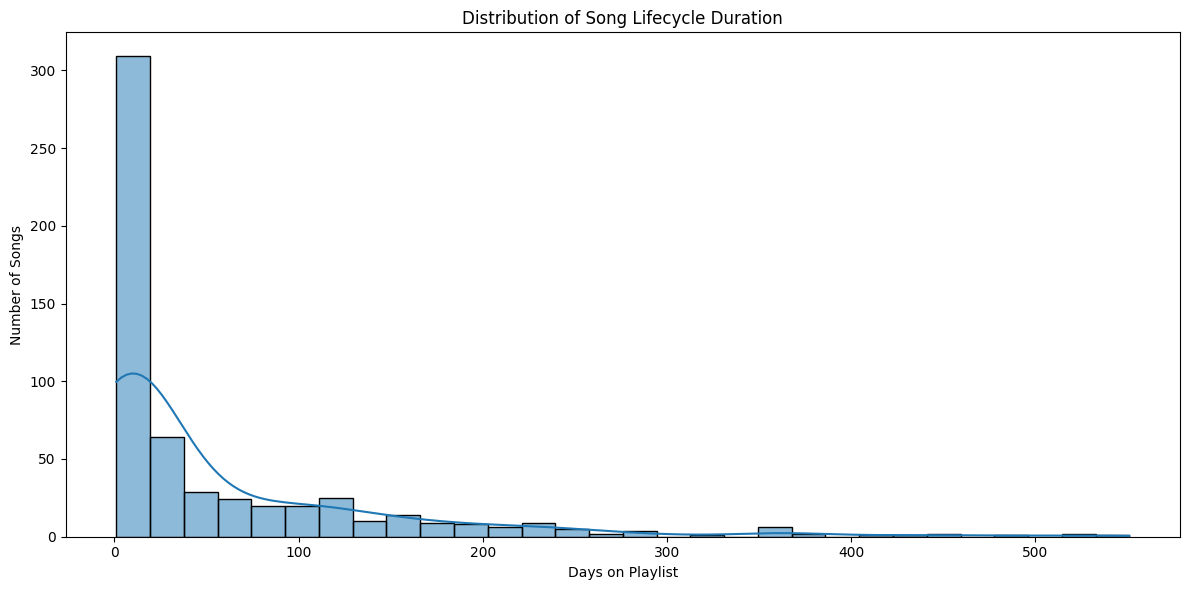

In [96]:
# Lifecycle duration distribution
plt.figure(figsize=(12, 6))

sns.histplot(
    lifecycle["days_on_playlist"],
    bins=30,
    kde=True
)

plt.title("Distribution of Song Lifecycle Duration")
plt.xlabel("Days on Playlist")
plt.ylabel("Number of Songs")

plt.tight_layout()
plt.show()

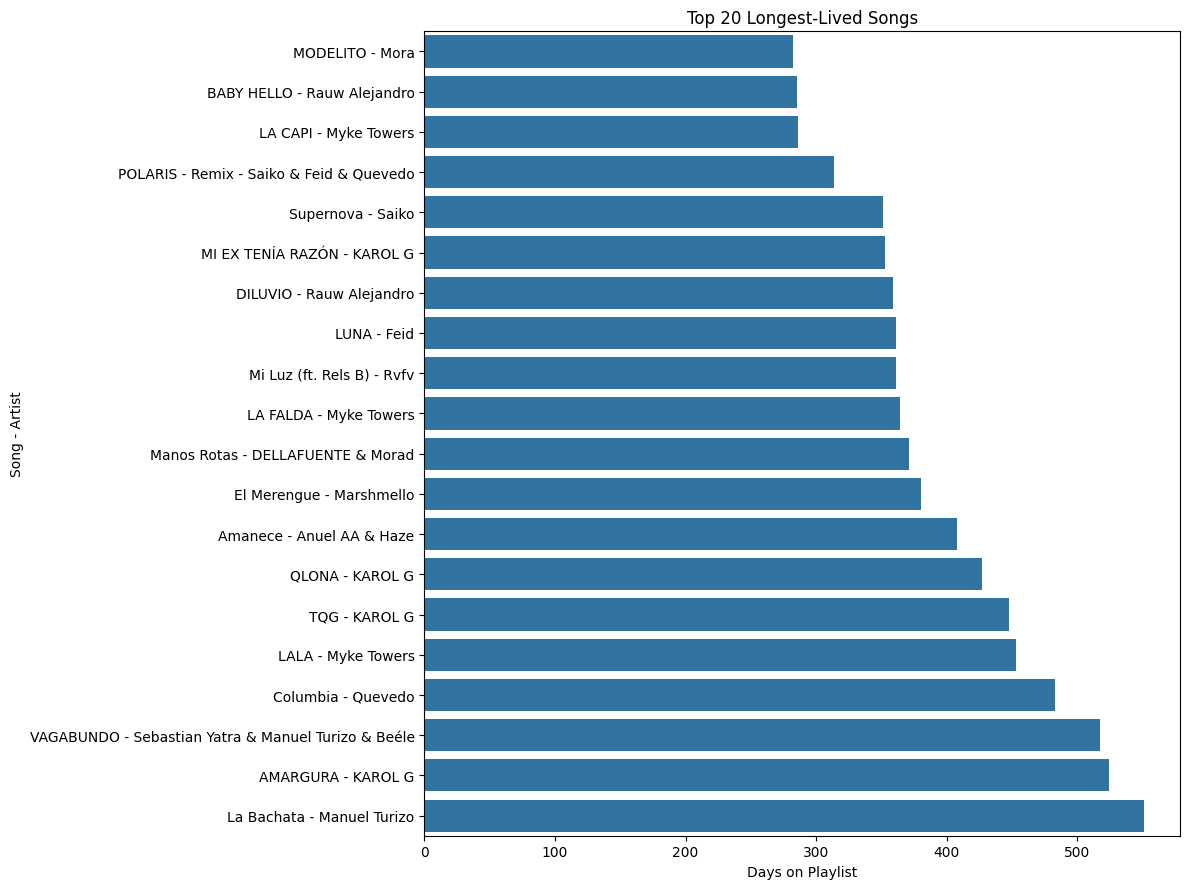

In [97]:
# Top 20 longest-lived songs visualization
plot_data = (
    lifecycle
    .sort_values(
        "days_on_playlist",
        ascending=True
    )
    .tail(20)
)

plot_data["song_artist"] = (
    plot_data["song"] +
    " - " +
    plot_data["artist"]
)

plt.figure(figsize=(12, 9))

sns.barplot(
    data=plot_data,
    x="days_on_playlist",
    y="song_artist"
)

plt.title("Top 20 Longest-Lived Songs")
plt.xlabel("Days on Playlist")
plt.ylabel("Song - Artist")

plt.tight_layout()
plt.show()

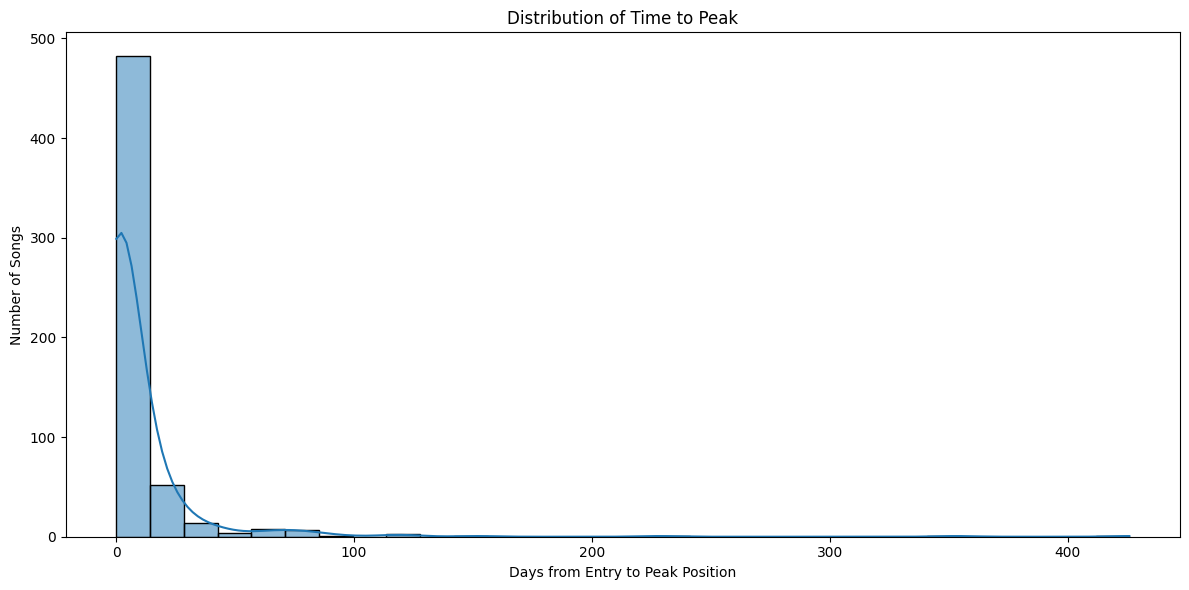

In [98]:
# Time to peak distribution
plt.figure(figsize=(12, 6))

sns.histplot(
    lifecycle["time_to_peak_days"].dropna(),
    bins=30,
    kde=True
)

plt.title("Distribution of Time to Peak")
plt.xlabel("Days from Entry to Peak Position")
plt.ylabel("Number of Songs")

plt.tight_layout()
plt.show()

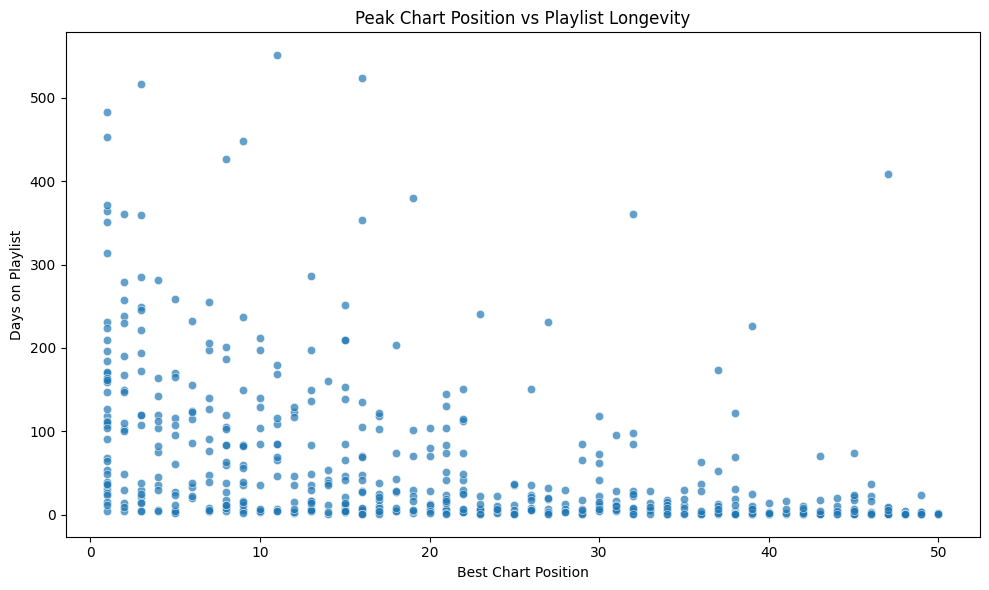

In [99]:
# Lifecycle duration vs peak position
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=lifecycle,
    x="best_position",
    y="days_on_playlist",
    alpha=0.7
)

plt.title("Peak Chart Position vs Playlist Longevity")
plt.xlabel("Best Chart Position")
plt.ylabel("Days on Playlist")

plt.tight_layout()
plt.show()

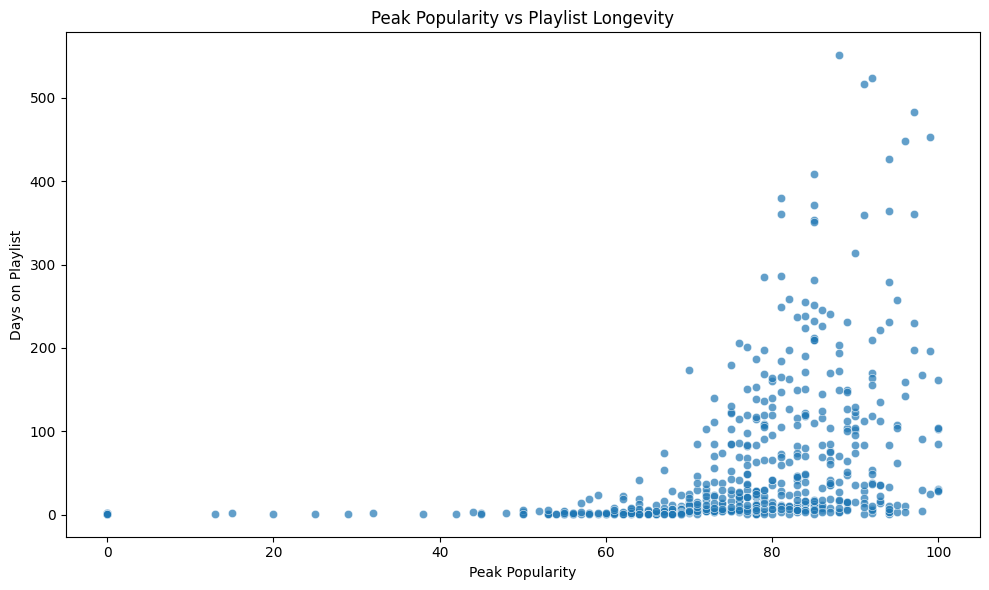

In [100]:
# Lifecycle duration vs popularity
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=lifecycle,
    x="peak_popularity",
    y="days_on_playlist",
    alpha=0.7
)

plt.title("Peak Popularity vs Playlist Longevity")
plt.xlabel("Peak Popularity")
plt.ylabel("Days on Playlist")

plt.tight_layout()
plt.show()

In [101]:
# Save lifecycle table
lifecycle.to_csv(
    "Spain_Top50_Song_Lifecycle.csv",
    index=False
)

print("Lifecycle table saved successfully.")

Lifecycle table saved successfully.


In [102]:
# Final lifecycle summary
print("=" * 60)
print("COMPLETED")
print("=" * 60)

print(f"Unique songs analyzed       : {len(lifecycle):,}")

print(
    f"Average days on playlist   : "
    f"{lifecycle['days_on_playlist'].mean():.2f}"
)

print(
    f"Median days on playlist    : "
    f"{lifecycle['days_on_playlist'].median():.2f}"
)

print(
    f"Average time to peak       : "
    f"{lifecycle['time_to_peak_days'].mean():.2f} days"
)

print(
    f"Average continuity         : "
    f"{lifecycle['continuity_percentage'].mean():.2f}%"
)

print(
    f"Longest lifecycle          : "
    f"{lifecycle['days_on_playlist'].max()} days"
)

COMPLETED
Unique songs analyzed       : 575
Average days on playlist   : 57.45
Median days on playlist    : 15.00
Average time to peak       : 9.49 days
Average continuity         : 91.73%
Longest lifecycle          : 551 days


In [103]:
# Check final lifecycle dataset
lifecycle.head(10)

,track_key,song,artist,entry_date,exit_date,entry_position,best_position,exit_position,observations,entry_popularity,peak_popularity,exit_popularity,album_type,total_tracks,is_explicit,duration_min,calendar_days,days_on_playlist,continuity,continuity_percentage,peak_date,peak_position_check,time_to_peak_days,rank_slope,popularity_slope,rank_improvement,rank_change_entry_to_exit,rank_movement,popularity_change,popularity_growth_percentage
0,0 confianza | rvfv,0 CONFIANZA,Rvfv,2025-06-02,2025-06-23,40,23,42,20,35,62,62,album,20,False,3.625000,22,22,0.909091,90.909091,2025-06-07,23,5,0.388722,0.584211,17,2,Stable,27,77.142857
1,"1 de enero, puntacana | rels b","1 de Enero, Puntacana",Rels B,2025-04-28,2025-04-28,45,45,45,1,65,65,65,album,13,False,1.583333,1,1,1.000000,100.000000,2025-04-28,45,0,0.000000,0.000000,0,0,Stable,0,0.000000
2,1000cosas | lola indigo & manuel turizo,1000COSAS,Lola Indigo & Manuel Turizo,2025-03-10,2025-11-13,3,3,44,245,65,81,72,single,1,False,3.991367,249,249,0.983936,98.393574,2025-03-10,3,0,0.121004,-0.027498,0,41,Stable,7,10.769231
3,100xciento | foreign teck & eladio carrion & d...,100xCiento,Foreign Teck & Eladio Carrion & De La Ghetto,2025-04-30,2025-05-15,42,13,37,11,72,75,75,single,1,True,3.661367,16,16,0.687500,68.750000,2025-05-11,13,11,-0.963636,0.345455,29,-5,Improving,3,4.166667
4,14 febreros | quevedo,14 FEBREROS,Quevedo,2025-11-24,2025-11-27,9,9,16,4,63,68,68,album,18,True,2.873700,4,4,1.000000,100.000000,2025-11-24,9,0,2.400000,1.700000,0,7,Declining,5,7.936508
5,2am | sebastian yatra & bad gyal,2AM,Sebastian Yatra & Bad Gyal,2025-11-24,2025-11-27,41,31,31,4,55,64,64,single,1,False,3.273767,4,4,1.000000,100.000000,2025-11-27,31,3,-3.800000,3.000000,10,-10,Improving,9,16.363636
6,2xll | jc reyes & yovngchimi & slayter,2xLL,JC Reyes & YOVNGCHIMI & Slayter,2025-07-12,2025-08-09,50,35,47,26,61,71,71,single,1,False,2.981817,29,29,0.896552,89.655172,2025-07-23,35,11,0.168889,0.309402,15,-3,Stable,10,16.393443
7,3 caídas | saiko,3 CAÍDAS,SAIKO,2025-04-28,2025-05-05,13,13,47,8,61,69,69,album,16,False,4.192750,8,8,1.000000,100.000000,2025-04-28,13,0,4.714286,0.976190,0,34,Declining,8,13.114754
8,4 prez | cruz cafuné,4 PREZ,Cruz Cafuné,2024-05-28,2024-05-29,35,35,46,2,53,56,56,album,23,True,2.491400,2,2,1.000000,100.000000,2024-05-28,35,0,11.000000,3.000000,0,11,Declining,3,5.660377
9,4to 23 | aitana,4TO 23,Aitana,2025-07-07,2025-07-16,17,17,50,9,58,69,69,single,1,False,2.805333,10,10,0.900000,90.000000,2025-07-07,17,0,4.150000,1.450000,0,33,Declining,11,18.965517


# Lifecycle Stage Classification:

In [104]:
# ============================================================
# MODULE 5 — LIFECYCLE STAGE CLASSIFICATION
# ============================================================

# Check lifecycle dataframe
print("Lifecycle shape:", lifecycle.shape)
print("\nAvailable columns:")
print(lifecycle.columns.tolist())


# ------------------------------------------------------------
# 1. Define lifecycle stage function
# ------------------------------------------------------------

def classify_lifecycle_stage(row):

    observations = row["observations"]
    best_position = row["best_position"]
    rank_slope = row["rank_slope"]

    # New Entry:
    # Song has been observed for 7 days or less
    if observations <= 7:
        return "New Entry"

    # Peak Phase:
    # Song reached Top 10 and rank is relatively stable
    elif best_position <= 10 and abs(rank_slope) < 0.75:
        return "Peak Phase"

    # Growth Phase:
    # Negative rank slope means position number is improving
    # Example: 35 -> 20 -> 10
    elif rank_slope < -0.75:
        return "Growth Phase"

    # Decline Phase:
    # Positive rank slope means position number is worsening
    # Example: 10 -> 20 -> 35
    elif rank_slope > 0.75:
        return "Decline Phase"

    # Mature Phase:
    # Stable songs that don't fall into the above categories
    else:
        return "Mature Phase"


# Apply classification
lifecycle["lifecycle_stage"] = lifecycle.apply(
    classify_lifecycle_stage,
    axis=1
)


# ------------------------------------------------------------
# 2. Check stage distribution
# ------------------------------------------------------------

stage_counts = (
    lifecycle["lifecycle_stage"]
    .value_counts()
    .reindex(
        [
            "New Entry",
            "Growth Phase",
            "Peak Phase",
            "Mature Phase",
            "Decline Phase"
        ],
        fill_value=0
    )
)

print("\nLifecycle Stage Distribution:")
print(stage_counts)


# Percentage distribution
stage_percentage = (
    stage_counts / stage_counts.sum() * 100
).round(2)

print("\nLifecycle Stage Percentage:")
print(stage_percentage)

Lifecycle shape: (575, 30)

Available columns:
['track_key', 'song', 'artist', 'entry_date', 'exit_date', 'entry_position', 'best_position', 'exit_position', 'observations', 'entry_popularity', 'peak_popularity', 'exit_popularity', 'album_type', 'total_tracks', 'is_explicit', 'duration_min', 'calendar_days', 'days_on_playlist', 'continuity', 'continuity_percentage', 'peak_date', 'peak_position_check', 'time_to_peak_days', 'rank_slope', 'popularity_slope', 'rank_improvement', 'rank_change_entry_to_exit', 'rank_movement', 'popularity_change', 'popularity_growth_percentage']

Lifecycle Stage Distribution:
lifecycle_stage
New Entry        237
Growth Phase      10
Peak Phase       113
Mature Phase     142
Decline Phase     73
Name: count, dtype: int64

Lifecycle Stage Percentage:
lifecycle_stage
New Entry        41.22
Growth Phase      1.74
Peak Phase       19.65
Mature Phase     24.70
Decline Phase    12.70
Name: count, dtype: float64


In [105]:
# Create Lifecycle Stage Summary

stage_summary = (
    lifecycle
    .groupby("lifecycle_stage")
    .agg(
        songs=("track_key", "nunique"),
        avg_days_on_playlist=("days_on_playlist", "mean"),
        median_days_on_playlist=("days_on_playlist", "median"),
        avg_time_to_peak=("time_to_peak_days", "mean"),
        avg_peak_position=("best_position", "mean"),
        avg_popularity=("peak_popularity", "mean"),
        avg_continuity=("continuity_percentage", "mean"),
        avg_rank_slope=("rank_slope", "mean")
    )
    .reset_index()
)


# Add percentage
stage_summary["percentage_of_songs"] = (
    stage_summary["songs"]
    / stage_summary["songs"].sum()
    * 100
).round(2)


# Round numerical columns
numeric_cols = [
    "avg_days_on_playlist",
    "median_days_on_playlist",
    "avg_time_to_peak",
    "avg_peak_position",
    "avg_popularity",
    "avg_continuity",
    "avg_rank_slope"
]

stage_summary[numeric_cols] = (
    stage_summary[numeric_cols]
    .round(2)
)


print("\nLifecycle Stage Summary:")
display(stage_summary)


Lifecycle Stage Summary:


,lifecycle_stage,songs,avg_days_on_playlist,median_days_on_playlist,avg_time_to_peak,avg_peak_position,avg_popularity,avg_continuity,avg_rank_slope,percentage_of_songs
0,Decline Phase,73,28.03,16.0,0.88,14.73,81.25,90.55,1.91,12.70
1,Growth Phase,10,20.00,19.5,14.40,10.10,76.30,79.27,-1.39,1.74
2,Mature Phase,142,84.55,52.5,23.31,25.15,80.87,84.82,0.16,24.70
3,New Entry,237,3.36,3.0,0.49,30.70,62.70,95.49,2.63,41.22
4,Peak Phase,113,159.13,129.0,16.11,4.48,85.53,94.38,0.22,19.65


In [106]:
# Retention Stability Index (Yahaan hum ek Retention Stability Index create karenge)
# Logic:
# Higher continuity → better stability
# Lower rank movement → better stability
# Score 0–100 ke range mein hoga

# RETENTION STABILITY INDEX
# Stability based on continuity and consistency of ranking

lifecycle["retention_stability_index"] = (
    lifecycle["continuity"]  # continuity batata hai ki song apne lifecycle mein kitna continuously present raha
    .clip(0, 1)  # Continuity ko 0 se 1 ke beech restrict karta hai.
    *
    (
        1 /
        (1 + lifecycle["rank_slope"].abs())  # Ye dekhta hai ki song ki rank kitni stable hai.
                                             # rank_slope batata hai ki time ke saath rank kis direction/rate se change ho rahi hai.
                                             # .abs() negative sign hata deta hai.
    )

    # Ab do factors combine ho rahe hain: Continuity × Rank Stability Yaani song: kitna continuously retain hua aur uski rank kitni stable rahi
    # Dono ko consider kiya ja raha hai.
   
    * 100  # Score ko percentage-like 0–100 scale par convert kar raha hai
)

# Ensure 0-100 range
lifecycle["retention_stability_index"] = (
    lifecycle["retention_stability_index"]
    .clip(0, 100)  # Ensure 0–100 range Agar calculation se accidentally: 105 aa gaya, to: 100 ho jayega. Agar: -5 aaya, to: 0 ho jayega.
    .round(2)
)


print(
    lifecycle[
        [                         # Ab hum selected columns print kar rahe hain
            "track_key",
            "song",
            "artist",
            "lifecycle_stage",
            "days_on_playlist",
             "continuity_percentage",
            "rank_slope",
            "retention_stability_index"
        ]
    ].head(10)
)

                                           track_key                   song  \
0                                 0 confianza | rvfv            0 CONFIANZA   
1                     1 de enero, puntacana | rels b  1 de Enero, Puntacana   
2            1000cosas | lola indigo & manuel turizo              1000COSAS   
3  100xciento | foreign teck & eladio carrion & d...             100xCiento   
4                              14 febreros | quevedo            14 FEBREROS   
5                   2am | sebastian yatra & bad gyal                    2AM   
6             2xll | jc reyes & yovngchimi & slayter                   2xLL   
7                                   3 caídas | saiko               3 CAÍDAS   
8                               4 prez | cruz cafuné                 4 PREZ   
9                                    4to 23 | aitana                 4TO 23   

                                         artist lifecycle_stage  \
0                                          Rvfv    Mature Phase

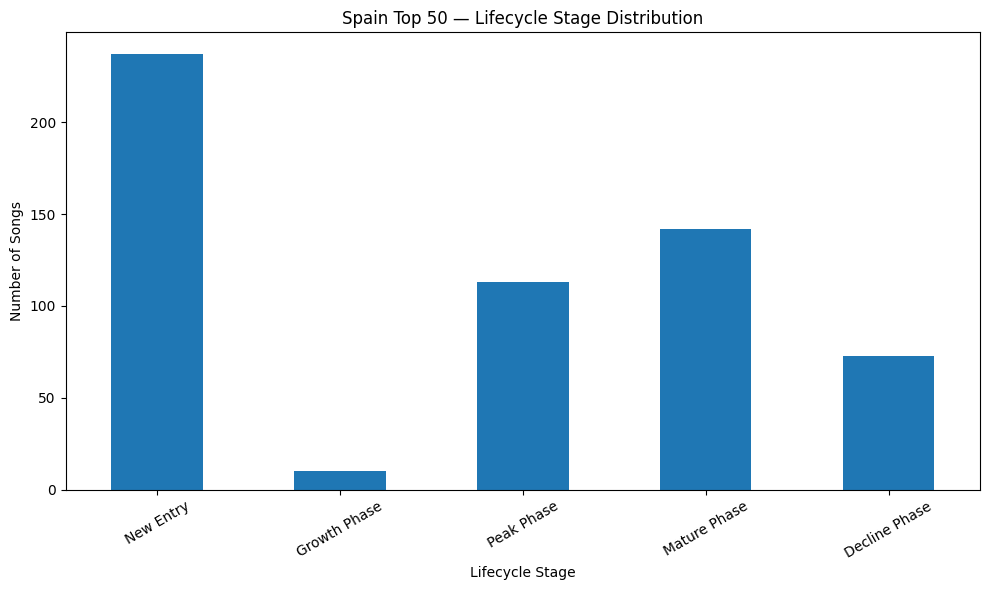

In [107]:
# LIFECYCLE STAGE DISTRIBUTION

plt.figure(figsize=(10, 6))

stage_order = [
    "New Entry",
    "Growth Phase",
    "Peak Phase",
    "Mature Phase",
    "Decline Phase"
]

plot_data = (
    lifecycle["lifecycle_stage"]
    .value_counts()
    .reindex(stage_order, fill_value=0)
)

plot_data.plot(kind="bar")

plt.title("Spain Top 50 — Lifecycle Stage Distribution")
plt.xlabel("Lifecycle Stage")
plt.ylabel("Number of Songs")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

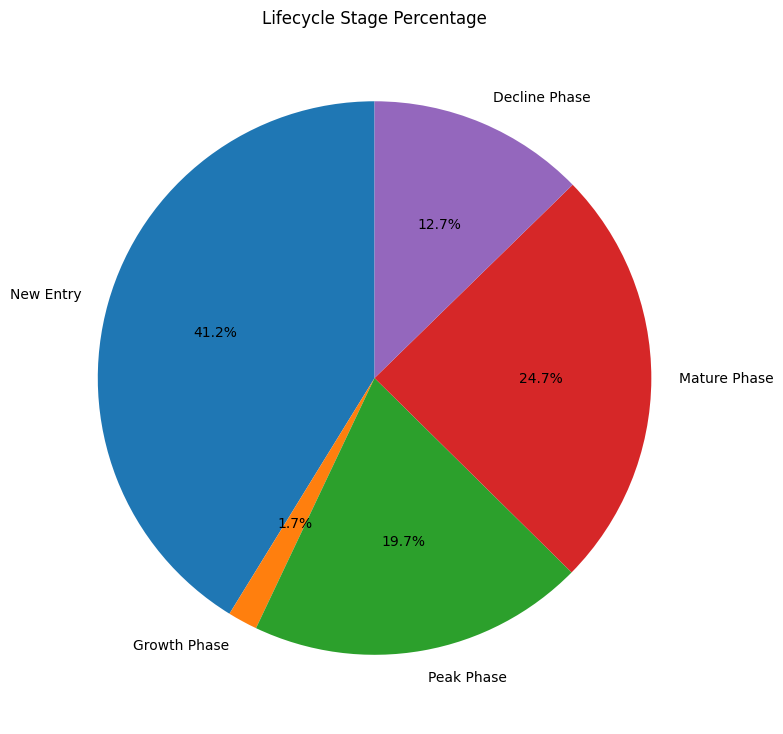

In [108]:
# LIFECYCLE STAGE PERCENTAGE

plt.figure(figsize=(8, 8))

plot_data = (
    lifecycle["lifecycle_stage"]
    .value_counts()
    .reindex(stage_order, fill_value=0)
)

plot_data.plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Lifecycle Stage Percentage")
plt.ylabel("")
plt.tight_layout()
plt.show()

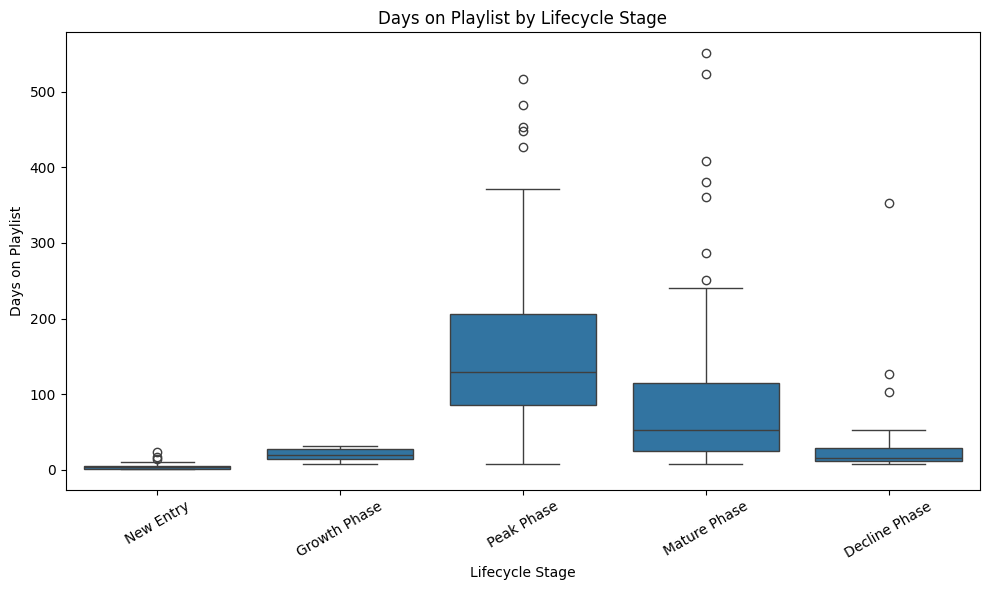

In [109]:
# DAYS ON PLAYLIST BY LIFECYCLE STAGE

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=lifecycle,
    x="lifecycle_stage",
    y="days_on_playlist",
    order=stage_order
)

plt.title("Days on Playlist by Lifecycle Stage")
plt.xlabel("Lifecycle Stage")
plt.ylabel("Days on Playlist")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

Average Retention Stability Index:
lifecycle_stage
New Entry        55.53
Growth Phase     34.56
Peak Phase       76.41
Mature Phase     69.24
Decline Phase    35.01
Name: retention_stability_index, dtype: float64


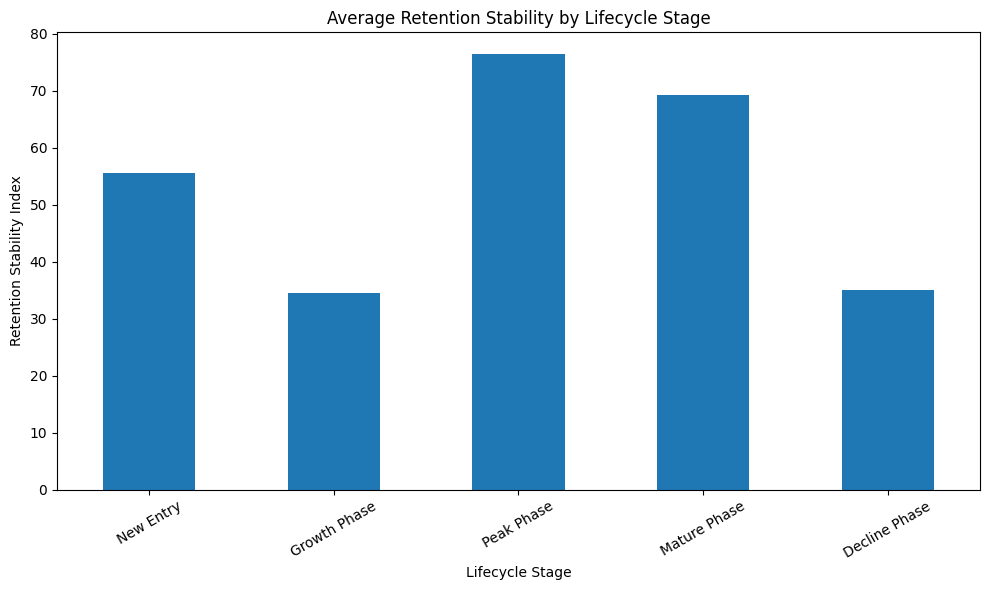

In [110]:
# RETENTION STABILITY BY LIFECYCLE STAGE

stability_summary = (
    lifecycle
    .groupby("lifecycle_stage")["retention_stability_index"]
    .mean()
    .reindex(stage_order)
)

print("Average Retention Stability Index:")
print(stability_summary.round(2))


plt.figure(figsize=(10, 6))

stability_summary.plot(kind="bar")

plt.title("Average Retention Stability by Lifecycle Stage")
plt.xlabel("Lifecycle Stage")
plt.ylabel("Retention Stability Index")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

   is_explicit lifecycle_stage  songs
0        False   Decline Phase     35
1        False    Growth Phase      5
2        False    Mature Phase     81
3        False       New Entry    136
4        False      Peak Phase     68
5         True   Decline Phase     38
6         True    Growth Phase      5
7         True    Mature Phase     61
8         True       New Entry    101
9         True      Peak Phase     45


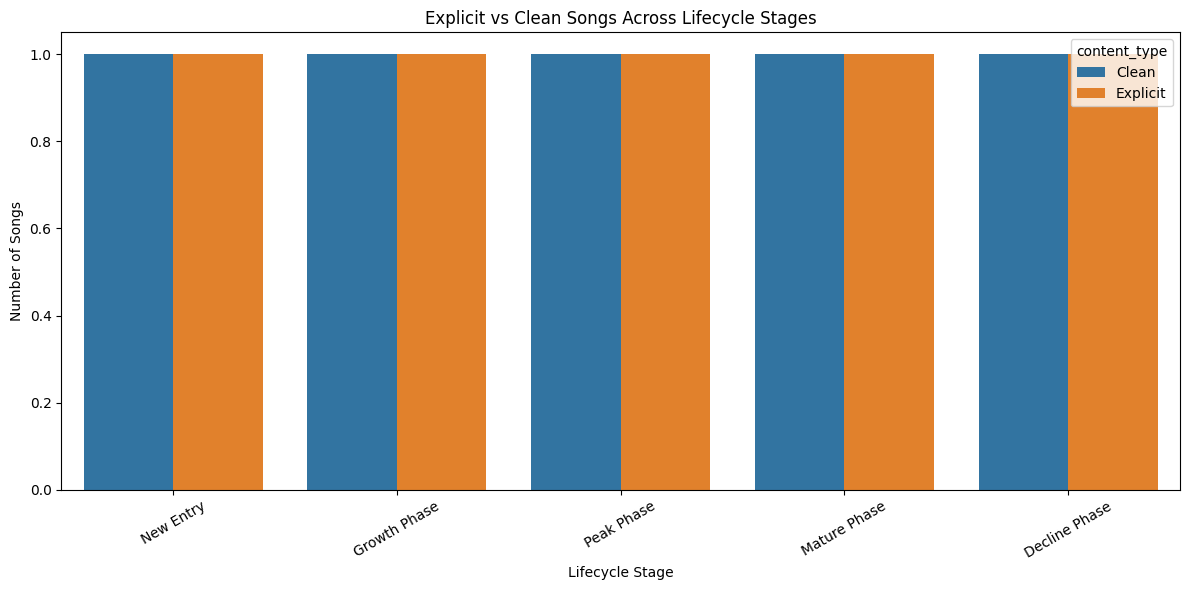

In [111]:
# EXPLICIT VS CLEAN LIFECYCLE

explicit_stage = (
    lifecycle
    .groupby(["is_explicit", "lifecycle_stage"])
    .size()
    .reset_index(name="songs")
)

print(explicit_stage)


# Convert boolean to readable labels
explicit_stage["content_type"] = explicit_stage[
    "is_explicit"
].map({
    True: "Explicit",
    False: "Clean"
})


# Plot
plt.figure(figsize=(12, 6))

sns.countplot(
    data=explicit_stage,
    x="lifecycle_stage",
    hue="content_type",
    order=stage_order
)

plt.title("Explicit vs Clean Songs Across Lifecycle Stages")
plt.xlabel("Lifecycle Stage")
plt.ylabel("Number of Songs")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [112]:
# EXPLICIT VS CLEAN — LONGEVITY

explicit_longevity = (
    lifecycle
    .groupby("is_explicit")
    .agg(
        songs=("track_key", "nunique"),
        avg_days=("days_on_playlist", "mean"),
        median_days=("days_on_playlist", "median"),
        avg_time_to_peak=("time_to_peak_days", "mean"),
        avg_stability=("retention_stability_index", "mean")
    )
    .reset_index()
)

explicit_longevity["content_type"] = (
    explicit_longevity["is_explicit"]
    .map({
        True: "Explicit",
        False: "Clean"
    })
)

explicit_longevity = explicit_longevity[
    [
        "content_type",
        "songs",
        "avg_days",
        "median_days",
        "avg_time_to_peak",
        "avg_stability"
    ]
]

explicit_longevity = explicit_longevity.round(2)

display(explicit_longevity)

,content_type,songs,avg_days,median_days,avg_time_to_peak,avg_stability
0,Clean,325,59.88,16.0,9.64,59.25
1,Explicit,250,54.28,14.5,9.28,61.08


In [113]:
# ALBUM VS SINGLE LIFECYCLE

album_lifecycle = (
    lifecycle
    .groupby("album_type")
    .agg(
        songs=("track_key", "nunique"),
        avg_days_on_playlist=("days_on_playlist", "mean"),
        median_days_on_playlist=("days_on_playlist", "median"),
        avg_time_to_peak=("time_to_peak_days", "mean"),
        avg_peak_position=("best_position", "mean"),
        avg_stability=("retention_stability_index", "mean")
    )
    .reset_index()
)

album_lifecycle = album_lifecycle.round(2)

print("Album Type Lifecycle Analysis:")
display(album_lifecycle)

Album Type Lifecycle Analysis:


,album_type,songs,avg_days_on_playlist,median_days_on_playlist,avg_time_to_peak,avg_peak_position,avg_stability
0,album,292,48.33,7.0,8.64,22.89,56.13
1,single,283,66.85,29.0,10.35,20.66,64.09


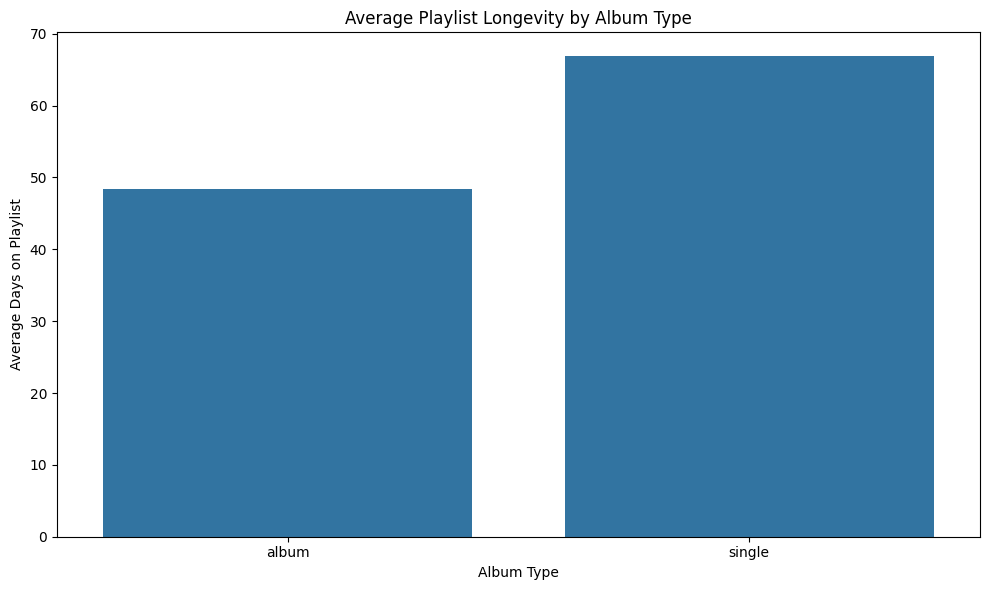

In [114]:
# Plot
plt.figure(figsize=(10, 6))

sns.barplot(
    data=album_lifecycle,
    x="album_type",
    y="avg_days_on_playlist"
)

plt.title("Average Playlist Longevity by Album Type")
plt.xlabel("Album Type")
plt.ylabel("Average Days on Playlist")
plt.tight_layout()
plt.show()

album_type       album  single
lifecycle_stage               
New Entry          151      86
Growth Phase         4       6
Peak Phase          39      74
Mature Phase        58      84
Decline Phase       40      33


<Figure size 1200x600 with 0 Axes>

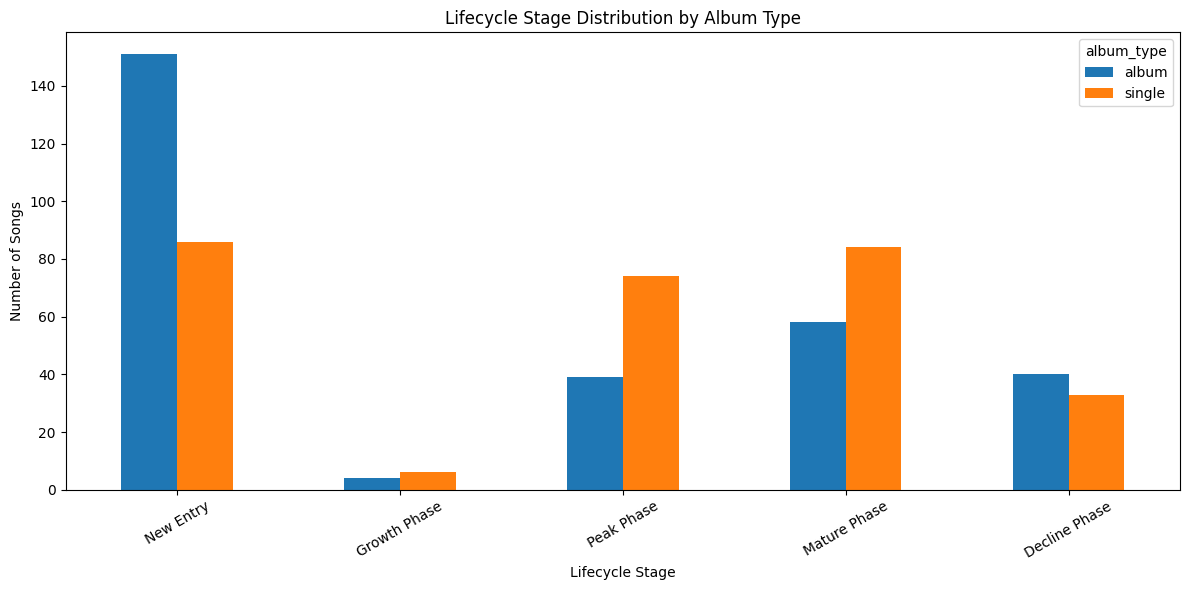

In [115]:
# LIFECYCLE STAGE × ALBUM TYPE

stage_album = pd.crosstab(
    lifecycle["lifecycle_stage"],
    lifecycle["album_type"]
).reindex(stage_order)

print(stage_album)


plt.figure(figsize=(12, 6))

stage_album.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Lifecycle Stage Distribution by Album Type")
plt.xlabel("Lifecycle Stage")
plt.ylabel("Number of Songs")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [116]:
# TOP STABLE SONGS

top_stable_songs = (
    lifecycle
    .sort_values(
        "retention_stability_index",
        ascending=False
    )
    [
        [
            "song",
            "artist",
            "album_type",
            "is_explicit",
            "days_on_playlist",
            "continuity_percentage",
            "best_position",
            "rank_slope",
            "retention_stability_index",
            "lifecycle_stage"
        ]
    ]
    .head(20)
)

display(top_stable_songs)

,song,artist,album_type,is_explicit,days_on_playlist,continuity_percentage,best_position,rank_slope,retention_stability_index,lifecycle_stage
566,Yankee 150,Yandel & Feid & Daddy Yankee,single,True,1,100.0,46,0.000000e+00,100.0,New Entry
564,Ya es Navidad Popurrí: Ya es Navidad- Zúmbale ...,Raya Real,album,False,1,100.0,34,0.000000e+00,100.0,New Entry
1,"1 de Enero, Puntacana",Rels B,album,False,1,100.0,45,0.000000e+00,100.0,New Entry
529,Tu Ritmo,Eladio Carrion,album,True,1,100.0,21,0.000000e+00,100.0,New Entry
526,Tranquila Baby,Eladio Carrion,album,True,1,100.0,32,0.000000e+00,100.0,New Entry
522,Todo Lit,Eladio Carrion,album,True,1,100.0,23,0.000000e+00,100.0,New Entry
520,Timeless (with Playboi Carti),The Weeknd & Playboi Carti,single,True,1,100.0,50,0.000000e+00,100.0,New Entry
28,Amar De Nuevo,Rauw Alejandro,album,True,1,100.0,45,0.000000e+00,100.0,New Entry
508,Tanta Droga,Eladio Carrion,album,True,1,100.0,27,0.000000e+00,100.0,New Entry
500,SPANISH TETEO,Rvfv & Rels B & Omar Montes,single,True,2,100.0,50,-2.359761e-15,100.0,New Entry


In [117]:
# Songs with Longest Lifecycle

longest_lived = (
    lifecycle
    .sort_values(
        "days_on_playlist",
        ascending=False
    )
    [
        [
            "song",
            "artist",
            "entry_date",
            "exit_date",
            "days_on_playlist",
            "best_position",
            "time_to_peak_days",
            "lifecycle_stage"
        ]
    ]
    .head(20)
)

display(longest_lived)

,song,artist,entry_date,exit_date,days_on_playlist,best_position,time_to_peak_days,lifecycle_stage
265,La Bachata,Manuel Turizo,2024-05-18,2025-11-19,551,11,228,Mature Phase
29,AMARGURA,KAROL G,2024-05-26,2025-10-31,524,16,426,Mature Phase
546,VAGABUNDO,Sebastian Yatra & Manuel Turizo & Beéle,2024-05-18,2025-10-16,517,3,17,Peak Phase
97,Columbia,Quevedo,2024-07-08,2025-11-02,483,1,1,Peak Phase
293,LALA,Myke Towers,2024-06-29,2025-09-24,453,1,6,Peak Phase
524,TQG,KAROL G,2024-05-18,2025-08-08,448,9,0,Peak Phase
429,QLONA,KAROL G,2024-08-19,2025-10-19,427,8,26,Peak Phase
26,Amanece,Anuel AA & Haze,2024-05-25,2025-07-06,408,47,29,Mature Phase
167,El Merengue,Marshmello,2024-11-04,2025-11-18,380,19,1,Mature Phase
325,Manos Rotas,DELLAFUENTE & Morad,2024-11-18,2025-11-23,371,1,11,Peak Phase


In [118]:
# Fastest Songs to Reach Peak

fastest_peak = (
    lifecycle[
        lifecycle["time_to_peak_days"].notna()
    ]
    .sort_values(
        "time_to_peak_days",
        ascending=True
    )
    [
        [
            "song",
            "artist",
            "entry_date",
            "peak_date",
            "time_to_peak_days",
            "best_position",
            "lifecycle_stage"
        ]
    ]
    .head(20)
)

display(fastest_peak)

,song,artist,entry_date,peak_date,time_to_peak_days,best_position,lifecycle_stage
46,BABY NUEVA,Bad Bunny,2024-10-14,2024-10-14,0,12,Decline Phase
7,3 CAÍDAS,SAIKO,2025-04-28,2025-04-28,0,13,Decline Phase
8,4 PREZ,Cruz Cafuné,2024-05-28,2024-05-28,0,35,New Entry
9,4TO 23,Aitana,2025-07-07,2025-07-07,0,17,Decline Phase
10,50 PALOS,Feid,2024-12-02,2024-12-02,0,38,New Entry
11,57,KAROL G & Feid & DFZM,2025-11-10,2025-11-10,0,8,Decline Phase
12,58,JHAYCO,2025-09-08,2025-09-08,0,35,Decline Phase
440,Qué Pecao,Manuel Turizo,2025-11-24,2025-11-24,0,34,New Entry
31,Antes,Rvfv & Edu García,2024-05-18,2024-05-18,0,29,Mature Phase
32,Antidepresivos,Saiko,2024-08-06,2024-08-06,0,13,Mature Phase


                 songs  avg_days  avg_stability  avg_peak_position
lifecycle_stage                                                   
New Entry          237      3.36          55.53              30.70
Growth Phase        10     20.00          34.56              10.10
Peak Phase         113    159.13          76.41               4.48
Mature Phase       142     84.55          69.24              25.15
Decline Phase       73     28.03          35.01              14.73


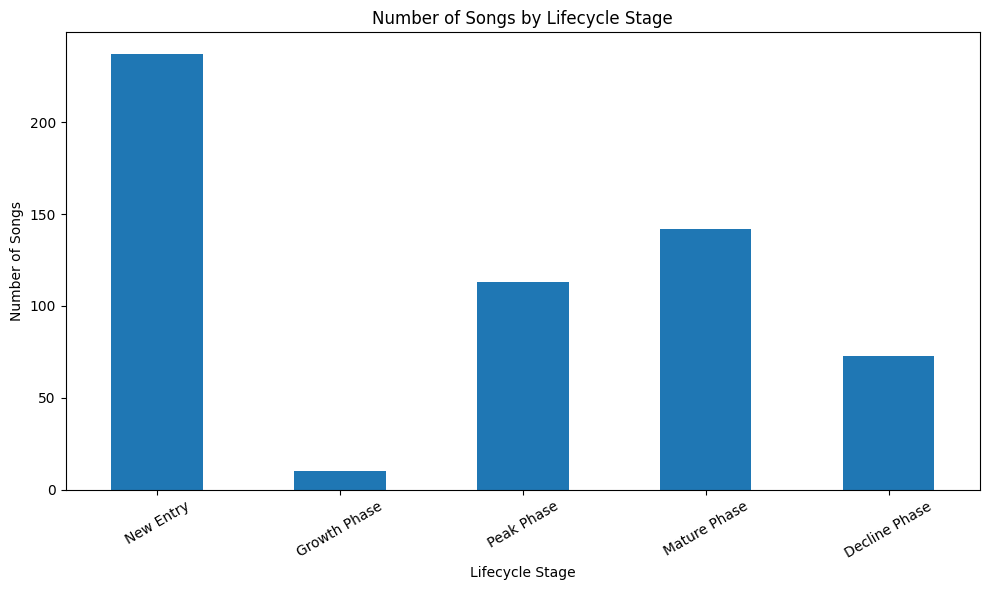

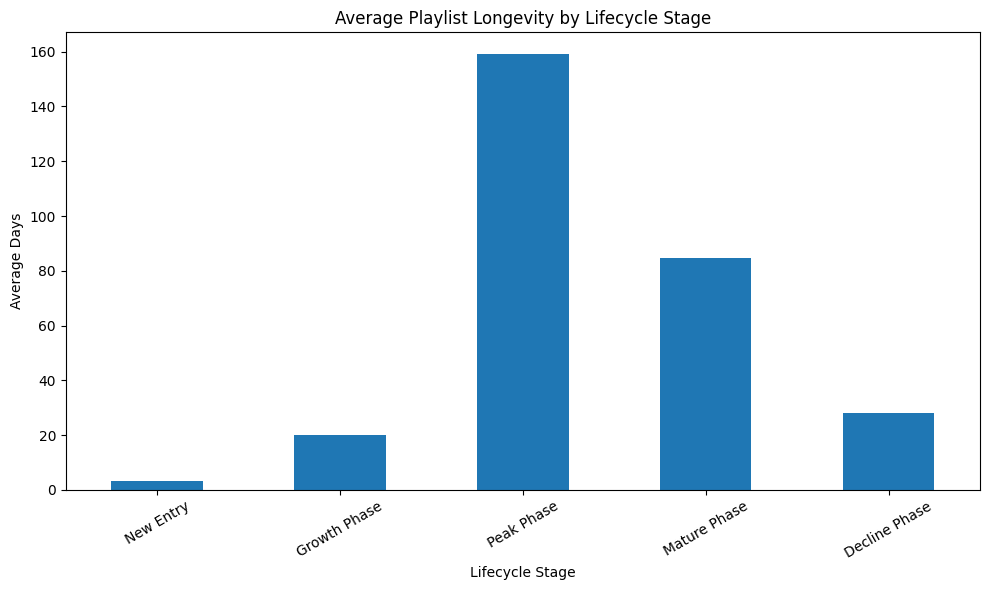

In [119]:
# Lifecycle Stage Summary Visualization

stage_plot = (
    lifecycle
    .groupby("lifecycle_stage")
    .agg(
        songs=("track_key", "nunique"),
        avg_days=("days_on_playlist", "mean"),
        avg_stability=("retention_stability_index", "mean"),
        avg_peak_position=("best_position", "mean")
    )
    .reindex(stage_order)
)

print(stage_plot.round(2))


# Number of songs
plt.figure(figsize=(10, 6))

stage_plot["songs"].plot(kind="bar")

plt.title("Number of Songs by Lifecycle Stage")
plt.xlabel("Lifecycle Stage")
plt.ylabel("Number of Songs")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


# Average longevity
plt.figure(figsize=(10, 6))

stage_plot["avg_days"].plot(kind="bar")

plt.title("Average Playlist Longevity by Lifecycle Stage")
plt.xlabel("Lifecycle Stage")
plt.ylabel("Average Days")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [120]:
# RESULTS

# Save complete lifecycle dataset
lifecycle.to_csv(
    "Spain_Top50_Lifecycle_Stage_Analysis.csv",
    index=False
)

# Save stage summary
stage_summary.to_csv(
    "Spain_Top50_Lifecycle_Stage_Summary.csv",
    index=False
)

# Save explicit vs clean analysis
explicit_longevity.to_csv(
    "Spain_Top50_Explicit_vs_Clean_Lifecycle.csv",
    index=False
)

# Save album type analysis
album_lifecycle.to_csv(
    "Spain_Top50_Album_Type_Lifecycle.csv",
    index=False
)

# Save stable songs
top_stable_songs.to_csv(
    "Spain_Top50_Top_Stable_Songs.csv",
    index=False
)

# Save longest-lived songs
longest_lived.to_csv(
    "Spain_Top50_Longest_Lived_Songs.csv",
    index=False
)

print("files exported successfully.")

files exported successfully.


In [121]:
# Field	Meaning
# lifecycle_stage	          New/Growth/Peak/Mature/Decline
# days_on_playlist	          First observed date se last observed date tak
# time_to_peak_days	          Entry se best position tak time
# rank_slope	              Ranking improve/decline speed
# continuity_percentage	      Playlist mein observed consistency
# retention_stability_index	  0–100 stability score

# Note: days_on_playlist ko actual continuous playlist presence na samjhein. Agar kisi song ke beech mein observation missing hai, 
# continuity_percentage us gap ko reflect karega.

# Playlist Rotation & Churn Analysis:

In [122]:
# Daily Playlist Snapshot

# Make sure date is sorted
df = df.sort_values(["date", "position"]).reset_index(drop=True)

# Daily playlist summary
daily_playlist = (
    df.groupby("date")
      .agg(
          songs=("track_key", "nunique"),
          avg_popularity=("popularity", "mean"),
          avg_position=("position", "mean")
      )
      .reset_index()
)

print("Daily Playlist Summary:")
display(daily_playlist.head())

print("\nNumber of days:", daily_playlist["date"].nunique())
print("Average songs per day:", daily_playlist["songs"].mean())

Daily Playlist Summary:


,date,songs,avg_popularity,avg_position
0,2024-05-18,50,84.56,25.5
1,2024-05-19,50,84.82,25.5
2,2024-05-20,50,85.00,25.5
3,2024-05-21,50,84.84,25.5
4,2024-05-22,50,85.34,25.5



Number of days: 555
Average songs per day: 50.0


In [123]:
# Identify New Entries and Exits

# Each track's first and last appearance
track_dates = (
    df.groupby("track_key")
      .agg(
          entry_date=("date", "min"),
          exit_date=("date", "max")
      )
      .reset_index()
)

# ------------------------------------------------------------
# New entries by date
# ------------------------------------------------------------

new_entries = (
    track_dates
    .groupby("entry_date")
    .size()
    .reset_index(name="new_entries")
    .rename(columns={"entry_date": "date"})
)

# ------------------------------------------------------------
# Exits by date
# ------------------------------------------------------------

exits = (
    track_dates
    .groupby("exit_date")
    .size()
    .reset_index(name="exits")
    .rename(columns={"exit_date": "date"})
)


# Merge
daily_rotation = (
    daily_playlist
    .merge(new_entries, on="date", how="left")
    .merge(exits, on="date", how="left")
)

daily_rotation[["new_entries", "exits"]] = (
    daily_rotation[["new_entries", "exits"]]
    .fillna(0)
)

print("Daily Rotation:")
display(daily_rotation.head(10))

Daily Rotation:


,date,songs,avg_popularity,avg_position,new_entries,exits
0,2024-05-18,50,84.56,25.5,50.0,0.0
1,2024-05-19,50,84.82,25.5,0.0,0.0
2,2024-05-20,50,85.00,25.5,0.0,3.0
3,2024-05-21,50,84.84,25.5,4.0,1.0
4,2024-05-22,50,85.34,25.5,1.0,0.0
5,2024-05-23,50,85.56,25.5,0.0,0.0
6,2024-05-24,50,85.70,25.5,0.0,1.0
7,2024-05-25,50,85.66,25.5,1.0,0.0
8,2024-05-26,50,86.00,25.5,1.0,0.0
9,2024-05-27,50,85.90,25.5,0.0,2.0


In [124]:
# Daily Churn Rate (Playlist mein 50 songs hain, therefore churn rate ko 50 ke against calculate kar sakte hain)

daily_rotation["entry_rate"] = (
    daily_rotation["new_entries"] / 50 * 100
)

daily_rotation["exit_rate"] = (
    daily_rotation["exits"] / 50 * 100
)

daily_rotation["churn_rate"] = (
    (
        daily_rotation["new_entries"]
        + daily_rotation["exits"]
    ) / (2 * 50) * 100
)

daily_rotation["net_change"] = (
    daily_rotation["new_entries"]
    - daily_rotation["exits"]
)


print("Churn statistics:")
display(
    daily_rotation[
        [
            "date",
            "new_entries",
            "exits",
            "entry_rate",
            "exit_rate",
            "churn_rate",
            "net_change"
        ]
    ].head(15)
)

Churn statistics:


,date,new_entries,exits,entry_rate,exit_rate,churn_rate,net_change
0,2024-05-18,50.0,0.0,100.0,0.0,50.0,50.0
1,2024-05-19,0.0,0.0,0.0,0.0,0.0,0.0
2,2024-05-20,0.0,3.0,0.0,6.0,3.0,-3.0
3,2024-05-21,4.0,1.0,8.0,2.0,5.0,3.0
4,2024-05-22,1.0,0.0,2.0,0.0,1.0,1.0
5,2024-05-23,0.0,0.0,0.0,0.0,0.0,0.0
6,2024-05-24,0.0,1.0,0.0,2.0,1.0,-1.0
7,2024-05-25,1.0,0.0,2.0,0.0,1.0,1.0
8,2024-05-26,1.0,0.0,2.0,0.0,1.0,1.0
9,2024-05-27,0.0,2.0,0.0,4.0,2.0,-2.0


In [125]:
# Overall Playlist Rotation KPIs

rotation_kpis = {
    "Average Daily New Entries":
        daily_rotation["new_entries"].mean(),

    "Average Daily Exits":
        daily_rotation["exits"].mean(),

    "Average Daily Churn Rate (%)":
        daily_rotation["churn_rate"].mean(),

    "Maximum Daily New Entries":
        daily_rotation["new_entries"].max(),

    "Maximum Daily Exits":
        daily_rotation["exits"].max(),

    "Total Unique Songs":
        df["track_key"].nunique(),

    "Total Playlist Days":
        df["date"].nunique()
}

rotation_kpis_df = pd.DataFrame(
    rotation_kpis.items(),
    columns=["KPI", "Value"]
)

rotation_kpis_df["Value"] = (
    rotation_kpis_df["Value"].round(2)
)

display(rotation_kpis_df)

,KPI,Value
0,Average Daily New Entries,1.04
1,Average Daily Exits,1.04
2,Average Daily Churn Rate (%),2.07
3,Maximum Daily New Entries,50.00
4,Maximum Daily Exits,50.00
5,Total Unique Songs,575.00
6,Total Playlist Days,555.00


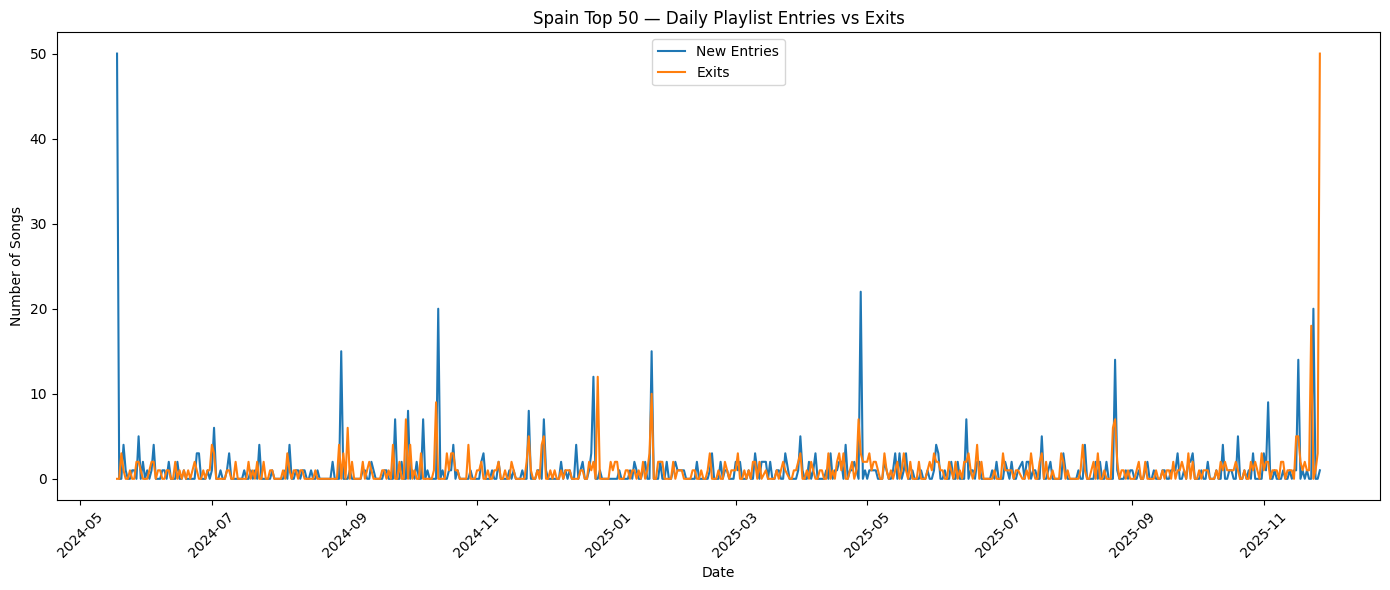

In [126]:
# Daily New Entries & Exits Chart

plt.figure(figsize=(14, 6))

plt.plot(
    daily_rotation["date"],
    daily_rotation["new_entries"],
    label="New Entries"
)

plt.plot(
    daily_rotation["date"],
    daily_rotation["exits"],
    label="Exits"
)

plt.title("Spain Top 50 — Daily Playlist Entries vs Exits")
plt.xlabel("Date")
plt.ylabel("Number of Songs")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

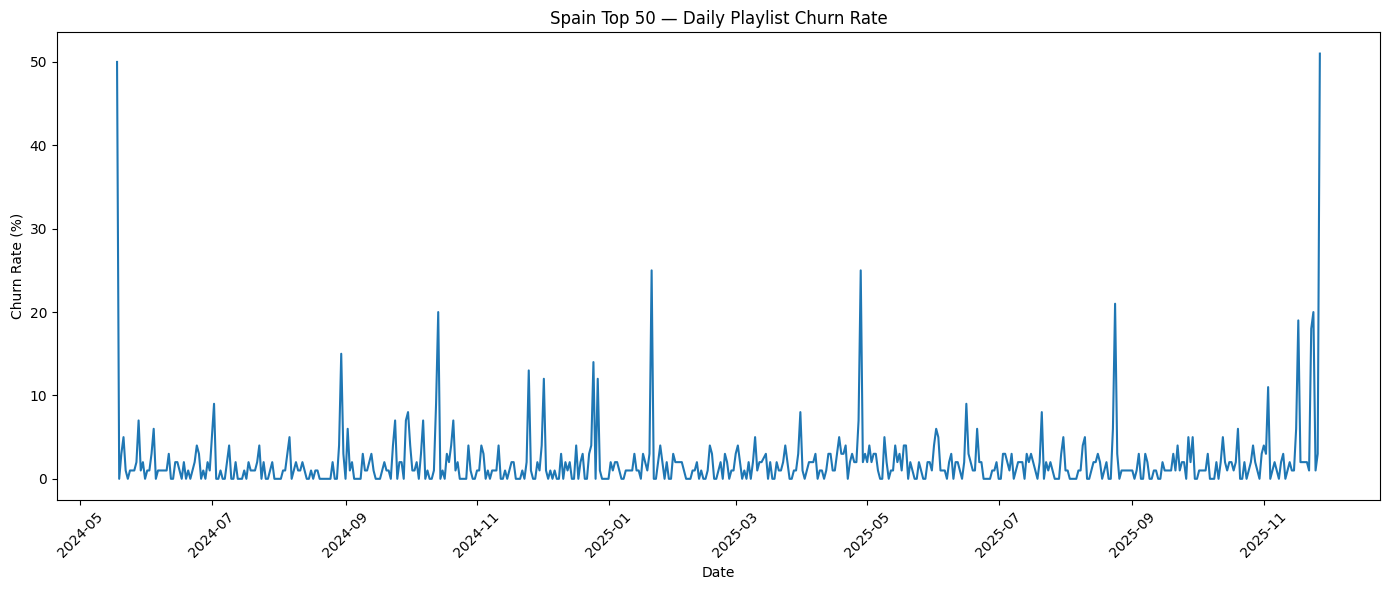

In [127]:
# Daily Churn Rate Trend

plt.figure(figsize=(14, 6))

plt.plot(
    daily_rotation["date"],
    daily_rotation["churn_rate"]
)

plt.title("Spain Top 50 — Daily Playlist Churn Rate")
plt.xlabel("Date")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [128]:
# Monthly Playlist Rotation (Ab daily churn ko monthly level par aggregate karenge)
daily_rotation["month"] = (
    daily_rotation["date"]
    .dt.to_period("M")
)

monthly_rotation = (
    daily_rotation
    .groupby("month")
    .agg(
        avg_new_entries=("new_entries", "mean"),
        avg_exits=("exits", "mean"),
        avg_churn_rate=("churn_rate", "mean"),
        total_new_entries=("new_entries", "sum"),
        total_exits=("exits", "sum"),
        avg_entry_rate=("entry_rate", "mean"),
        avg_exit_rate=("exit_rate", "mean")
    )
    .reset_index()
)

monthly_rotation["month"] = (
    monthly_rotation["month"]
    .astype(str)
)

monthly_rotation = monthly_rotation.round(2)

display(monthly_rotation)

,month,avg_new_entries,avg_exits,avg_churn_rate,total_new_entries,total_exits,avg_entry_rate,avg_exit_rate
0,2024-05,4.57,0.71,5.29,64.0,10.0,9.14,1.43
1,2024-06,0.67,0.70,1.37,20.0,21.0,1.33,1.40
2,2024-07,0.65,0.65,1.29,20.0,20.0,1.29,1.29
3,2024-08,0.90,0.55,1.45,28.0,17.0,1.81,1.10
4,2024-09,0.83,1.00,1.83,25.0,30.0,1.67,2.00
5,2024-10,1.29,1.10,2.39,40.0,34.0,2.58,2.19
6,2024-11,0.70,0.73,1.43,21.0,22.0,1.40,1.47
7,2024-12,1.16,1.10,2.26,36.0,34.0,2.32,2.19
8,2025-01,0.90,1.16,2.06,28.0,36.0,1.81,2.32
9,2025-02,0.57,0.57,1.14,16.0,16.0,1.14,1.14


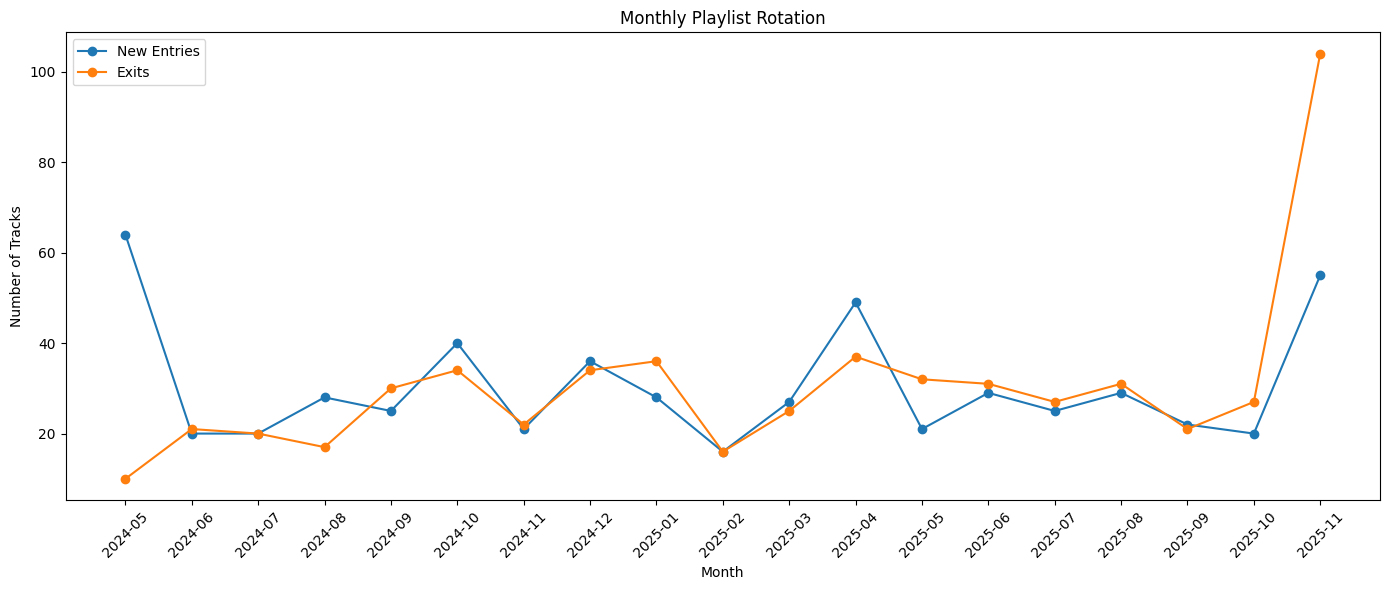

In [129]:
# MONTHLY ROTATION CHART

plt.figure(figsize=(14, 6))

plt.plot(
    monthly_rotation["month"],
    monthly_rotation["total_new_entries"],
    marker="o",
    label="New Entries"
)

plt.plot(
    monthly_rotation["month"],
    monthly_rotation["total_exits"],
    marker="o",
    label="Exits"
)

plt.title("Monthly Playlist Rotation")
plt.xlabel("Month")
plt.ylabel("Number of Tracks")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

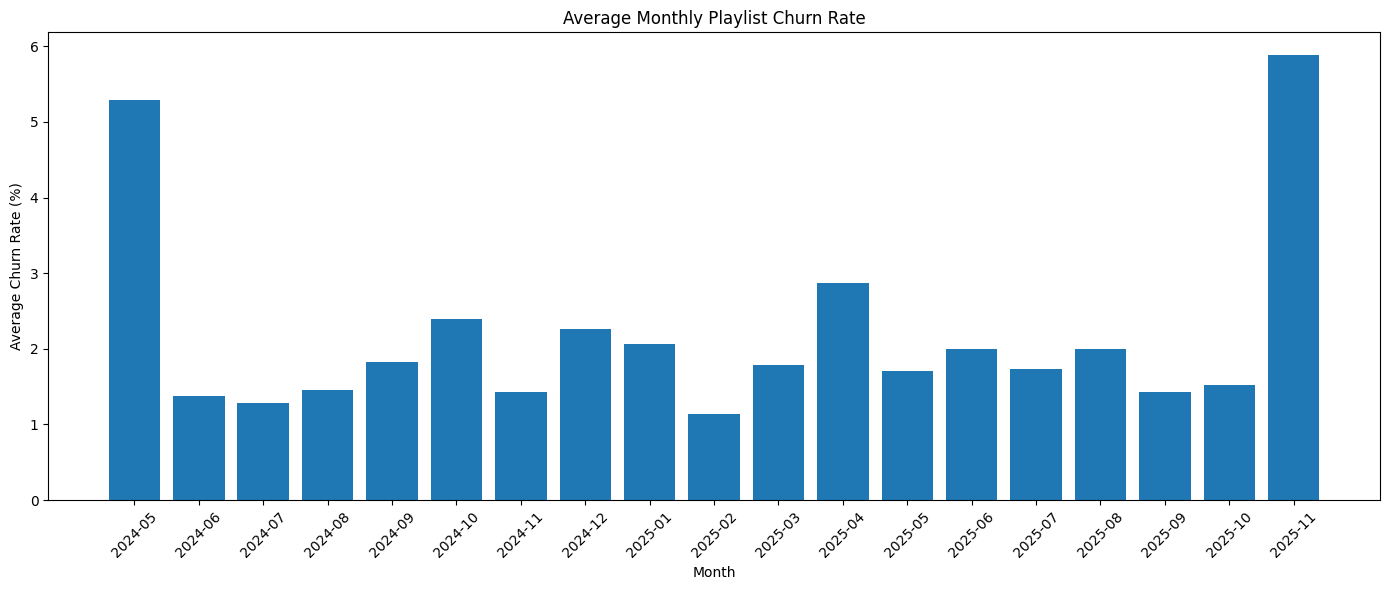

In [130]:
# Monthly Churn Rate

plt.figure(figsize=(14, 6))

plt.bar(
    monthly_rotation["month"],
    monthly_rotation["avg_churn_rate"]
)

plt.title("Average Monthly Playlist Churn Rate")
plt.xlabel("Month")
plt.ylabel("Average Churn Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [131]:
# Playlist Stability Index
# High churn = low stability. Hum ek simple stability score calculate karenge: Playlist Stability Index = 100 − Churn Rate

monthly_rotation["playlist_stability_index"] = (
    100 - monthly_rotation["avg_churn_rate"]
)

monthly_rotation["playlist_stability_index"] = (
    monthly_rotation["playlist_stability_index"]
    .clip(0, 100)
    .round(2)
)

display(
    monthly_rotation[
        [
            "month",
            "avg_churn_rate",
            "playlist_stability_index"
        ]
    ]
)

,month,avg_churn_rate,playlist_stability_index
0,2024-05,5.29,94.71
1,2024-06,1.37,98.63
2,2024-07,1.29,98.71
3,2024-08,1.45,98.55
4,2024-09,1.83,98.17
5,2024-10,2.39,97.61
6,2024-11,1.43,98.57
7,2024-12,2.26,97.74
8,2025-01,2.06,97.94
9,2025-02,1.14,98.86


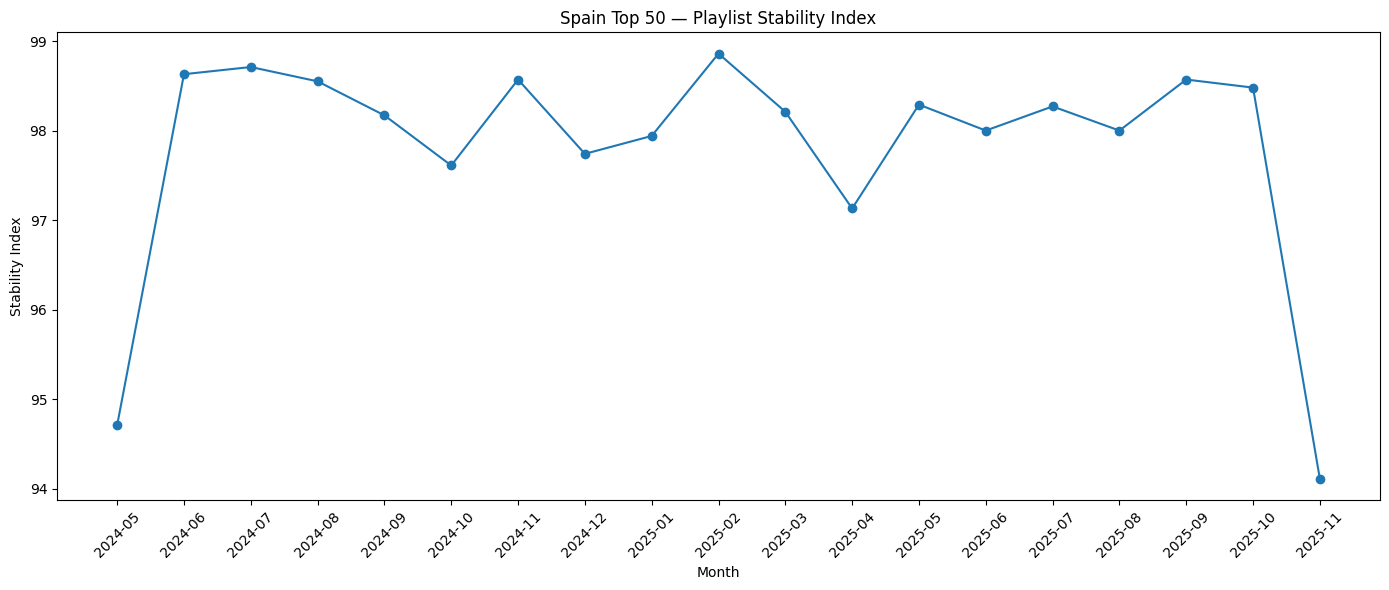

In [132]:
# Stability visualization
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_rotation["month"],
    monthly_rotation["playlist_stability_index"],
    marker="o"
)

plt.title("Spain Top 50 — Playlist Stability Index")
plt.xlabel("Month")
plt.ylabel("Stability Index")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [133]:
# Most Frequently Rotated Songs (Ye identify karega ki kaunse tracks playlist mein relatively short lifecycle ke saath appear hue)

high_rotation_songs = (
    lifecycle[
        lifecycle["days_on_playlist"] <=
        lifecycle["days_on_playlist"].quantile(0.25)
    ]
    .sort_values(
        "days_on_playlist",
        ascending=True
    )
    [
        [
            "song",
            "artist",
            "entry_date",
            "exit_date",
            "days_on_playlist",
            "observations",
            "continuity_percentage",
            "best_position",
            "lifecycle_stage"
        ]
    ]
)

display(high_rotation_songs.head(20))

,song,artist,entry_date,exit_date,days_on_playlist,observations,continuity_percentage,best_position,lifecycle_stage
1,"1 de Enero, Puntacana",Rels B,2025-04-28,2025-04-28,1,1,100.0,45,New Entry
10,50 PALOS,Feid,2024-12-02,2024-12-02,1,1,100.0,38,New Entry
28,Amar De Nuevo,Rauw Alejandro,2025-11-17,2025-11-17,1,1,100.0,45,New Entry
40,ATTITUDE (FEAT. CHARLIE WILSON & CASH COBAIN),Don Toliver,2025-06-21,2025-06-21,1,1,100.0,46,New Entry
53,Barro,Duki,2025-10-20,2025-10-20,1,1,100.0,40,New Entry
52,BANDIT,Don Toliver,2025-06-21,2025-06-21,1,1,100.0,27,New Entry
41,AUNQUE LLEGUE OTRO (feat. Jay Wheeler),Myke Towers,2025-08-24,2025-08-24,1,1,100.0,23,New Entry
60,Beso Prohibido,Beny Jr,2025-09-07,2025-09-07,1,1,100.0,49,New Entry
80,Caserio,Yandel & SAIKO,2025-03-10,2025-03-10,1,1,100.0,41,New Entry
89,Cine 🚬,Duki,2025-11-03,2025-11-03,1,1,100.0,42,New Entry


In [134]:
# Longest Retained Songs

long_retention = (
    lifecycle
    .sort_values(
        ["days_on_playlist", "continuity_percentage"],
        ascending=[False, False]
    )
    [
        [
            "song",
            "artist",
            "entry_date",
            "exit_date",
            "days_on_playlist",
            "continuity_percentage",
            "best_position",
            "retention_stability_index",
            "lifecycle_stage"
        ]
    ]
    .head(20)
)

display(long_retention)

,song,artist,entry_date,exit_date,days_on_playlist,continuity_percentage,best_position,retention_stability_index,lifecycle_stage
265,La Bachata,Manuel Turizo,2024-05-18,2025-11-19,551,97.640653,11,96.74,Mature Phase
29,AMARGURA,KAROL G,2024-05-26,2025-10-31,524,29.198473,16,26.49,Mature Phase
546,VAGABUNDO,Sebastian Yatra & Manuel Turizo & Beéle,2024-05-18,2025-10-16,517,74.468085,3,65.92,Peak Phase
97,Columbia,Quevedo,2024-07-08,2025-11-02,483,95.859213,1,86.95,Peak Phase
293,LALA,Myke Towers,2024-06-29,2025-09-24,453,68.432671,1,58.77,Peak Phase
524,TQG,KAROL G,2024-05-18,2025-08-08,448,26.785714,9,20.85,Peak Phase
429,QLONA,KAROL G,2024-08-19,2025-10-19,427,80.093677,8,74.11,Peak Phase
26,Amanece,Anuel AA & Haze,2024-05-25,2025-07-06,408,3.676471,47,3.61,Mature Phase
167,El Merengue,Marshmello,2024-11-04,2025-11-18,380,83.421053,19,80.66,Mature Phase
325,Manos Rotas,DELLAFUENTE & Morad,2024-11-18,2025-11-23,371,88.679245,1,75.13,Peak Phase


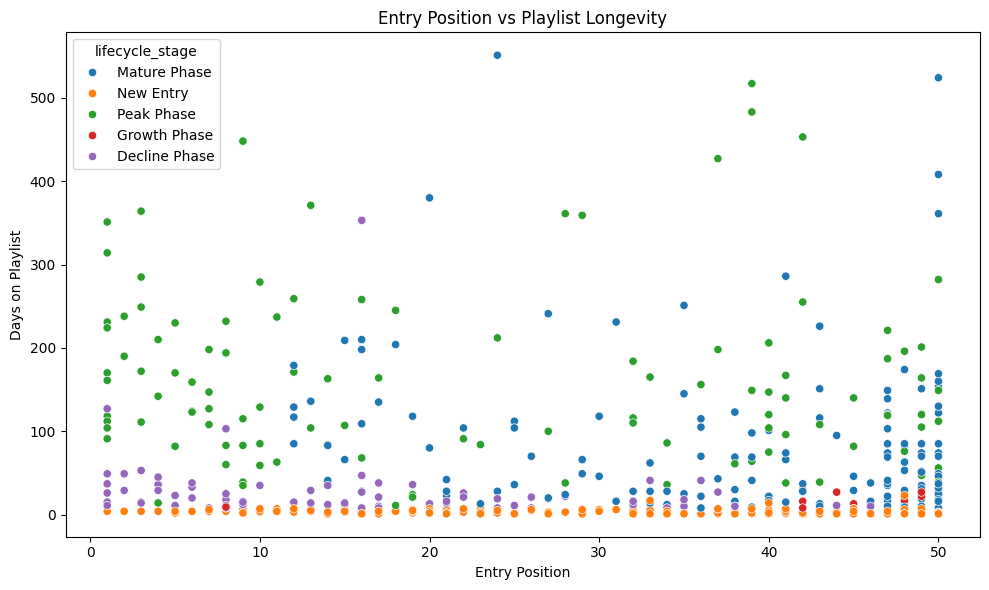

In [135]:
# Entry Position vs Retention (Ye check karega ki initial position ka relationship song longevity ke saath hai ya nahi)

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=lifecycle,
    x="entry_position",
    y="days_on_playlist",
    hue="lifecycle_stage"
)

plt.title("Entry Position vs Playlist Longevity")
plt.xlabel("Entry Position")
plt.ylabel("Days on Playlist")
plt.tight_layout()
plt.show()

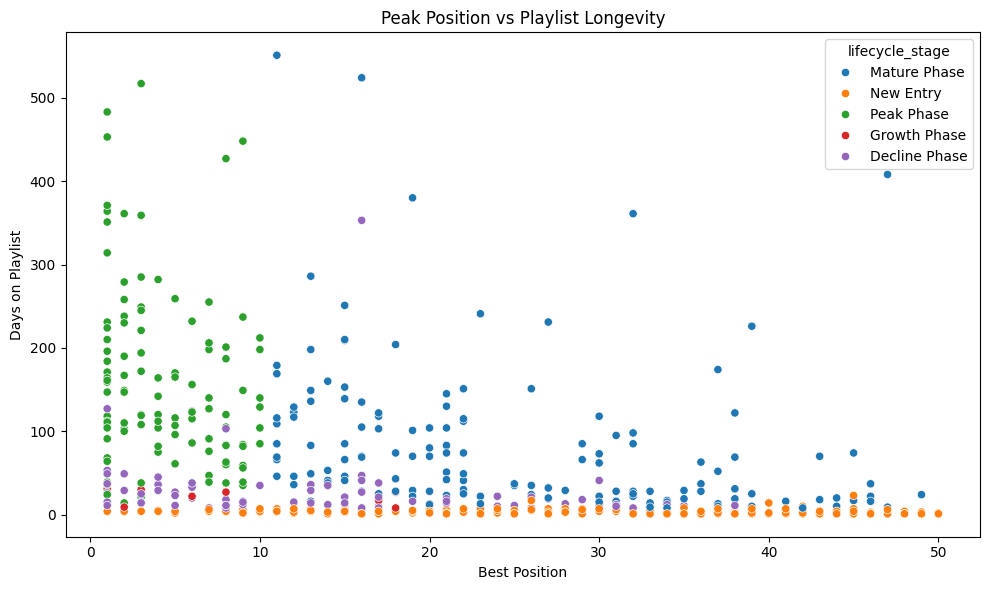

In [136]:
# PEAK POSITION VS LONGEVITY

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=lifecycle,
    x="best_position",
    y="days_on_playlist",
    hue="lifecycle_stage"
)

plt.title("Peak Position vs Playlist Longevity")
plt.xlabel("Best Position")
plt.ylabel("Days on Playlist")
plt.tight_layout()
plt.show()

In [137]:
# Calculate Rotation Correlation

correlation_data = lifecycle[
    [
        "entry_position",
        "best_position",
        "time_to_peak_days",
        "days_on_playlist",
        "continuity_percentage",
        "rank_slope",
        "retention_stability_index",
        "entry_popularity",
        "peak_popularity",
        "popularity_change"
    ]
].corr()

display(
    correlation_data.round(2)
)

,entry_position,best_position,time_to_peak_days,days_on_playlist,continuity_percentage,rank_slope,retention_stability_index,entry_popularity,peak_popularity,popularity_change
entry_position,1.00,0.65,0.20,-0.12,-0.18,-0.24,0.23,0.21,-0.22,-0.36
best_position,0.65,1.00,-0.11,-0.44,-0.11,-0.02,0.12,0.02,-0.47,-0.30
time_to_peak_days,0.20,-0.11,1.00,0.49,-0.25,-0.12,0.07,0.11,0.15,-0.04
days_on_playlist,-0.12,-0.44,0.49,1.00,-0.29,-0.18,0.17,0.14,0.37,0.02
continuity_percentage,-0.18,-0.11,-0.25,-0.29,1.00,0.06,0.36,-0.11,-0.12,0.05
rank_slope,-0.24,-0.02,-0.12,-0.18,0.06,1.00,-0.50,-0.26,-0.02,0.29
retention_stability_index,0.23,0.12,0.07,0.17,0.36,-0.50,1.00,0.09,-0.19,-0.26
entry_popularity,0.21,0.02,0.11,0.14,-0.11,-0.26,0.09,1.00,0.46,-0.79
peak_popularity,-0.22,-0.47,0.15,0.37,-0.12,-0.02,-0.19,0.46,1.00,0.18
popularity_change,-0.36,-0.30,-0.04,0.02,0.05,0.29,-0.26,-0.79,0.18,1.00


In [138]:
# Entry Speed Analysis (Yahaan hum identify karenge ki songs Top 50 mein kis position se enter karte hain)

entry_position_summary = (
    lifecycle
    .groupby(
        pd.cut(
            lifecycle["entry_position"],
            bins=[0, 10, 20, 30, 40, 50],
            labels=[
                "1-10",
                "11-20",
                "21-30",
                "31-40",
                "41-50"
            ]
        )
    )
    .size()
    .reset_index(name="songs")
)

display(entry_position_summary)

C:\Users\preks\AppData\Local\Temp\ipykernel_6836\4157330353.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(


,entry_position,songs
0,1-10,93
1,11-20,92
2,21-30,77
3,31-40,108
4,41-50,205


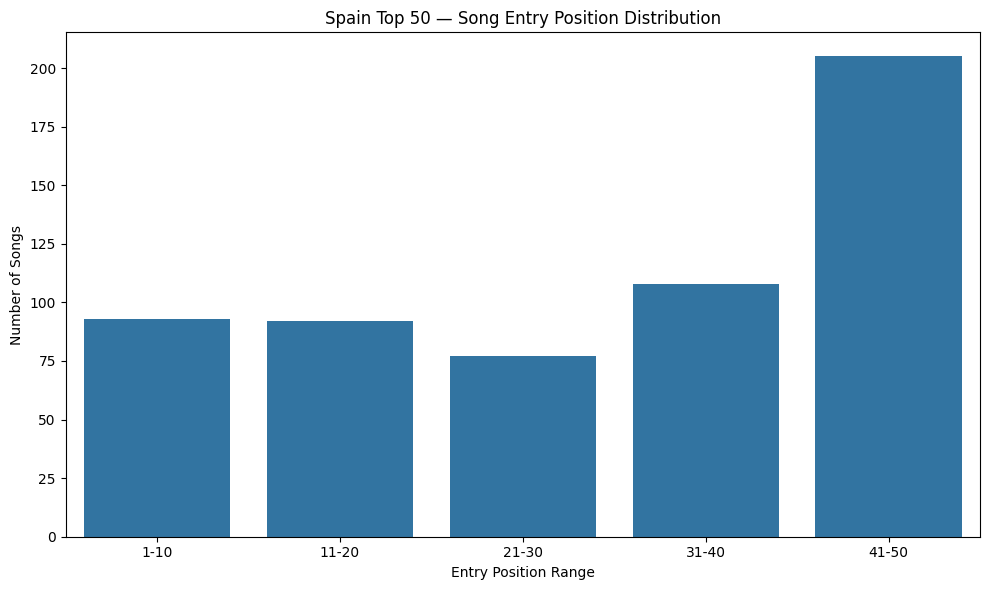

In [139]:
# Plot
plt.figure(figsize=(10, 6))

sns.barplot(
    data=entry_position_summary,
    x="entry_position",
    y="songs"
)

plt.title("Spain Top 50 — Song Entry Position Distribution")
plt.xlabel("Entry Position Range")
plt.ylabel("Number of Songs")
plt.tight_layout()
plt.show()

In [140]:
# Churn by Lifecycle Stage
# LIFECYCLE STAGE VS LONGEVITY

stage_rotation = (
    lifecycle
    .groupby("lifecycle_stage")
    .agg(
        songs=("track_key", "nunique"),
        avg_days=("days_on_playlist", "mean"),
        median_days=("days_on_playlist", "median"),
        avg_continuity=("continuity_percentage", "mean"),
        avg_stability=("retention_stability_index", "mean")
    )
    .reindex(stage_order)
    .round(2)
)

display(stage_rotation)

,songs,avg_days,median_days,avg_continuity,avg_stability
lifecycle_stage,,,,,
New Entry,237,3.36,3.0,95.49,55.53
Growth Phase,10,20.00,19.5,79.27,34.56
Peak Phase,113,159.13,129.0,94.38,76.41
Mature Phase,142,84.55,52.5,84.82,69.24
Decline Phase,73,28.03,16.0,90.55,35.01


In [141]:
# Final Rotation Dashboard Table

final_rotation_summary = pd.DataFrame({
    "Metric": [
        "Total Playlist Days",
        "Total Unique Songs",
        "Average Daily New Entries",
        "Average Daily Exits",
        "Average Daily Churn Rate (%)",
        "Average Playlist Stability (%)",
        "Average Song Longevity (Days)",
        "Average Song Continuity (%)"
    ],

    "Value": [
        df["date"].nunique(),
        df["track_key"].nunique(),
        daily_rotation["new_entries"].mean(),
        daily_rotation["exits"].mean(),
        daily_rotation["churn_rate"].mean(),
        100 - daily_rotation["churn_rate"].mean(),
        lifecycle["days_on_playlist"].mean(),
        lifecycle["continuity_percentage"].mean()
    ]
})

final_rotation_summary["Value"] = (
    final_rotation_summary["Value"]
    .round(2)
)

display(final_rotation_summary)

,Metric,Value
0,Total Playlist Days,555.00
1,Total Unique Songs,575.00
2,Average Daily New Entries,1.04
3,Average Daily Exits,1.04
4,Average Daily Churn Rate (%),2.07
5,Average Playlist Stability (%),97.93
6,Average Song Longevity (Days),57.45
7,Average Song Continuity (%),91.73


In [142]:
# Export Results

daily_rotation.to_csv(
    "Spain_Top50_Daily_Rotation.csv",
    index=False
)

monthly_rotation.to_csv(
    "Spain_Top50_Monthly_Rotation.csv",
    index=False
)

rotation_kpis_df.to_csv(
    "Spain_Top50_Rotation_KPIs.csv",
    index=False
)

high_rotation_songs.to_csv(
    "Spain_Top50_High_Rotation_Songs.csv",
    index=False
)

long_retention.to_csv(
    "Spain_Top50_Longest_Retention.csv",
    index=False
)

final_rotation_summary.to_csv(
    "Spain_Top50_Final_Rotation_Summary.csv",
    index=False
)

print("completed successfully.")
print("Rotation and churn files exported.")

completed successfully.
Rotation and churn files exported.


# Content Maturity Analysis:

In [143]:
# Define Content Age

# Make sure dates are datetime
df["date"] = pd.to_datetime(df["date"])
lifecycle["entry_date"] = pd.to_datetime(lifecycle["entry_date"])

# Dataset observation date range
analysis_start_date = df["date"].min()
analysis_end_date = df["date"].max()

print("Analysis Start Date:", analysis_start_date.date())
print("Analysis End Date:", analysis_end_date.date())

Analysis Start Date: 2024-05-18
Analysis End Date: 2025-11-27


In [144]:
# Freshness at Playlist Entry (Yahaan ek important distinction hai: Dataset mein actual song release date available nahi hai.
# Isliye hum true "song age since release" calculate nahi kar sakte. Instead, hum playlist freshness ko define karenge based on first 
#bobserved appearance in the Spain Top 50.


# PLAYLIST FRESHNESS
lifecycle["entry_age_days"] = (
    lifecycle["entry_date"] - analysis_start_date
).dt.days

print(
    lifecycle[
        [
            "song",
            "artist",
            "entry_date",
            "entry_age_days"
        ]
    ].head(10)
)

                    song                                        artist  \
0            0 CONFIANZA                                          Rvfv   
1  1 de Enero, Puntacana                                        Rels B   
2              1000COSAS                   Lola Indigo & Manuel Turizo   
3             100xCiento  Foreign Teck & Eladio Carrion & De La Ghetto   
4            14 FEBREROS                                       Quevedo   
5                    2AM                    Sebastian Yatra & Bad Gyal   
6                   2xLL               JC Reyes & YOVNGCHIMI & Slayter   
7               3 CAÍDAS                                         SAIKO   
8                 4 PREZ                                   Cruz Cafuné   
9                 4TO 23                                        Aitana   

  entry_date  entry_age_days  
0 2025-06-02             380  
1 2025-04-28             345  
2 2025-03-10             296  
3 2025-04-30             347  
4 2025-11-24             555  

In [145]:
# Fresh vs Mature Classification (Hum playlist observation period ke according categories create karenge)

def classify_content_maturity(days):

    if days <= 30:
        return "Fresh"

    elif days <= 90:
        return "Developing"

    elif days <= 180:
        return "Mature"

    else:
        return "Established"


lifecycle["content_maturity"] = (
    lifecycle["entry_age_days"]
    .apply(classify_content_maturity)
)

maturity_order = [
    "Fresh",
    "Developing",
    "Mature",
    "Established"
]

print("Content Maturity Distribution:")
display(
    lifecycle["content_maturity"]
    .value_counts()
    .reindex(maturity_order, fill_value=0)
)

# Ye "song release age" nahi hai. Ye analysis-window ke andar playlist entry timing ko maturity proxy ke roop mein use karta hai

Content Maturity Distribution:


content_maturity
Fresh           76
Developing      38
Mature          91
Established    370
Name: count, dtype: int64

In [146]:
# Content Maturity Distribution

maturity_counts = (
    lifecycle["content_maturity"]
    .value_counts()
    .reindex(maturity_order, fill_value=0)
)

maturity_percentage = (
    maturity_counts /
    maturity_counts.sum() * 100
).round(2)

maturity_summary = pd.DataFrame({
    "songs": maturity_counts,
    "percentage": maturity_percentage
})

display(maturity_summary)

,songs,percentage
content_maturity,,
Fresh,76,13.22
Developing,38,6.61
Mature,91,15.83
Established,370,64.35


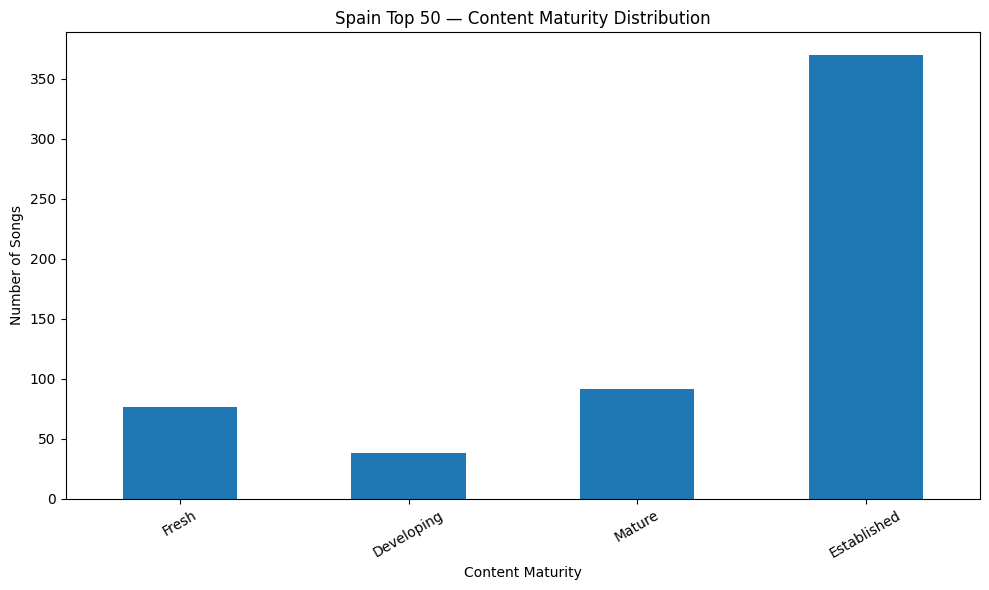

In [147]:
# Maturity Distribution Plot

plt.figure(figsize=(10, 6))

maturity_counts.plot(kind="bar")

plt.title("Spain Top 50 — Content Maturity Distribution")
plt.xlabel("Content Maturity")
plt.ylabel("Number of Songs")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

In [148]:
# Maturity vs Playlist Longevity (Ab check karenge ki different maturity groups ki average playlist longevity kya hai)

maturity_lifecycle = (
    lifecycle
    .groupby("content_maturity")
    .agg(
        songs=("track_key", "nunique"),
        avg_days_on_playlist=("days_on_playlist", "mean"),
        median_days_on_playlist=("days_on_playlist", "median"),
        avg_time_to_peak=("time_to_peak_days", "mean"),
        avg_peak_position=("best_position", "mean"),
        avg_continuity=("continuity_percentage", "mean"),
        avg_stability=("retention_stability_index", "mean"),
        avg_peak_popularity=("peak_popularity", "mean")
    )
    .reindex(maturity_order)
    .round(2)
    .reset_index()
)

display(maturity_lifecycle)

,content_maturity,songs,avg_days_on_playlist,median_days_on_playlist,avg_time_to_peak,avg_peak_position,avg_continuity,avg_stability,avg_peak_popularity
0,Fresh,76,120.12,72.0,15.21,23.78,85.14,64.37,84.07
1,Developing,38,91.03,38.0,13.50,21.79,93.60,67.54,82.18
2,Mature,91,67.65,12.0,12.24,16.55,92.88,46.85,75.80
3,Established,370,38.61,9.5,7.22,22.68,92.60,61.64,71.06


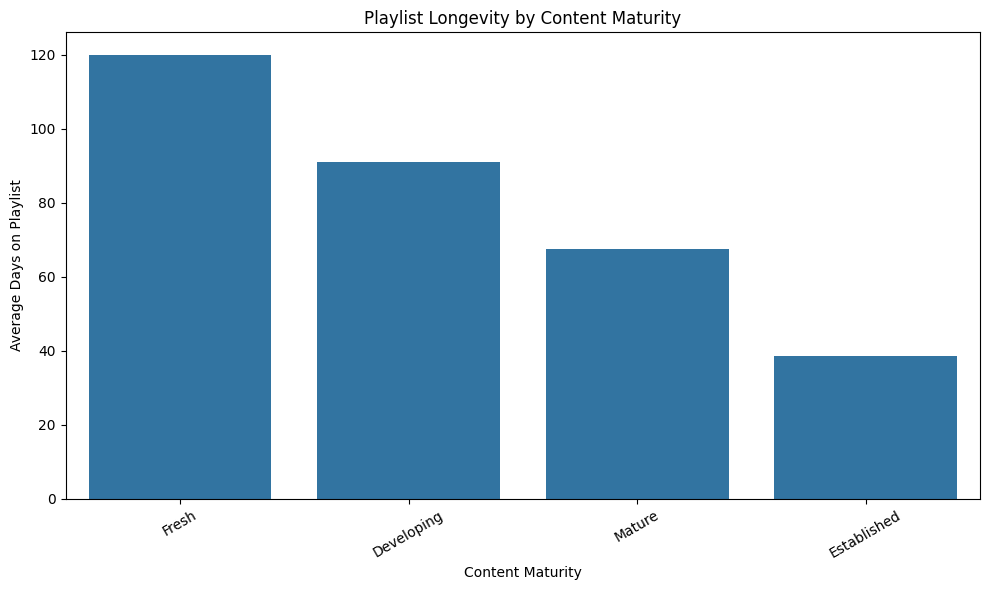

In [149]:
# Maturity vs Longevity Visualization

plt.figure(figsize=(10, 6))

sns.barplot(
    data=maturity_lifecycle,
    x="content_maturity",
    y="avg_days_on_playlist"
)

plt.title("Playlist Longevity by Content Maturity")
plt.xlabel("Content Maturity")
plt.ylabel("Average Days on Playlist")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

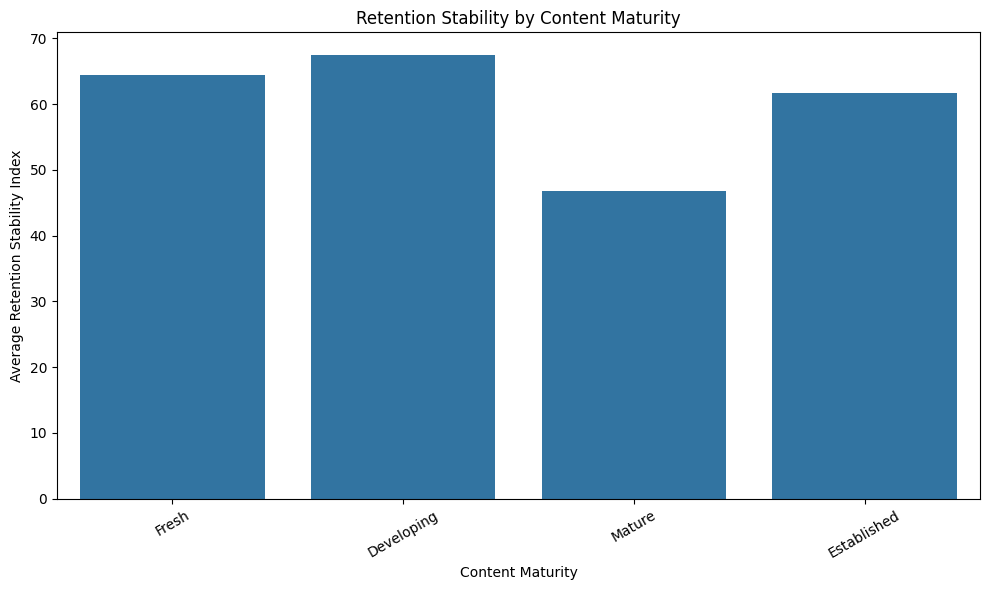

In [150]:
# Maturity vs Retention Stability

plt.figure(figsize=(10, 6))

sns.barplot(
    data=maturity_lifecycle,
    x="content_maturity",
    y="avg_stability"
)

plt.title("Retention Stability by Content Maturity")
plt.xlabel("Content Maturity")
plt.ylabel("Average Retention Stability Index")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

In [151]:
# Explicit vs Clean Content Maturity

explicit_maturity = (
    lifecycle
    .groupby(
        ["is_explicit", "content_maturity"]
    )
    .agg(
        songs=("track_key", "nunique"),
        avg_days=("days_on_playlist", "mean"),
        avg_stability=("retention_stability_index", "mean"),
        avg_peak_position=("best_position", "mean"),
        avg_popularity=("peak_popularity", "mean")
    )
    .reset_index()
)

explicit_maturity["content_type"] = (
    explicit_maturity["is_explicit"]
    .map({
        True: "Explicit",
        False: "Clean"
    })
)

display(
    explicit_maturity.round(2)
)

,is_explicit,content_maturity,songs,avg_days,avg_stability,avg_peak_position,avg_popularity,content_type
0,False,Developing,17,115.18,63.39,22.41,81.06,Clean
1,False,Established,219,37.87,58.22,22.19,73.25,Clean
2,False,Fresh,46,133.98,63.65,23.22,84.15,Clean
3,False,Mature,43,70.84,58.20,19.98,68.56,Clean
4,True,Developing,21,71.48,70.91,21.29,83.10,Explicit
5,True,Established,151,39.70,66.60,23.38,67.89,Explicit
6,True,Fresh,30,98.87,65.46,24.63,83.93,Explicit
7,True,Mature,48,64.79,36.68,13.48,82.29,Explicit


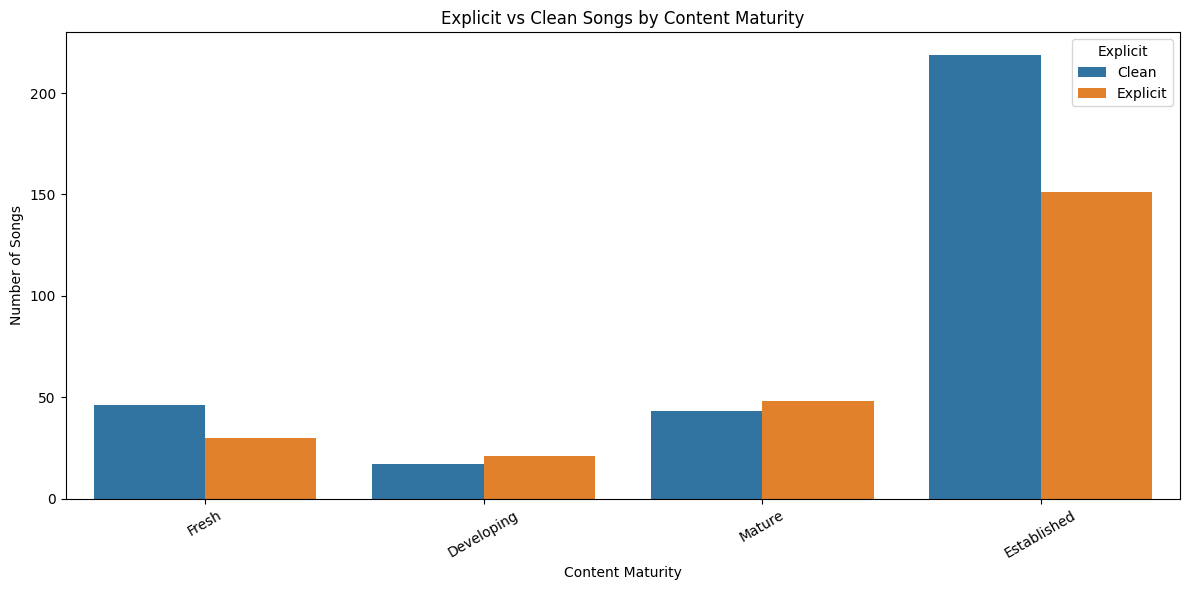

In [152]:
# Explicit vs Clean — Maturity Distribution

plt.figure(figsize=(12, 6))

sns.countplot(
    data=lifecycle,
    x="content_maturity",
    hue="is_explicit",
    order=maturity_order
)

plt.title("Explicit vs Clean Songs by Content Maturity")
plt.xlabel("Content Maturity")
plt.ylabel("Number of Songs")

plt.xticks(rotation=30)
plt.legend(
    title="Explicit",
    labels=["Clean", "Explicit"]
)

plt.tight_layout()
plt.show()

In [153]:
# Explicit Content Lifecycle Score (Hum ise average retention stability ke basis par calculate karenge)

explicit_score = (
    lifecycle
    .groupby("is_explicit")
    .agg(
        songs=("track_key", "nunique"),
        avg_longevity=("days_on_playlist", "mean"),
        avg_stability=("retention_stability_index", "mean"),
        avg_continuity=("continuity_percentage", "mean"),
        avg_peak_position=("best_position", "mean")
    )
    .reset_index()
)

explicit_score["content_type"] = (
    explicit_score["is_explicit"]
    .map({
        True: "Explicit",
        False: "Clean"
    })
)


# Lifecycle Score
explicit_score["explicit_content_lifecycle_score"] = (
    (
        explicit_score["avg_stability"] * 0.5
        +
        explicit_score["avg_continuity"] * 0.3
        +
        (
            (51 - explicit_score["avg_peak_position"])
            / 50 * 100
        ) * 0.2
    )
    .clip(0, 100)
    .round(2)
)

display(explicit_score)

# Score higher hone ka matlab:
# better retention
# better continuity
# stronger chart position
# more stable playlist presence

,is_explicit,songs,avg_longevity,avg_stability,avg_continuity,avg_peak_position,content_type,explicit_content_lifecycle_score
0,False,325,59.876923,59.254646,91.377756,22.052308,Clean,68.62
1,True,250,54.284000,61.082360,92.179746,21.456000,Explicit,70.01


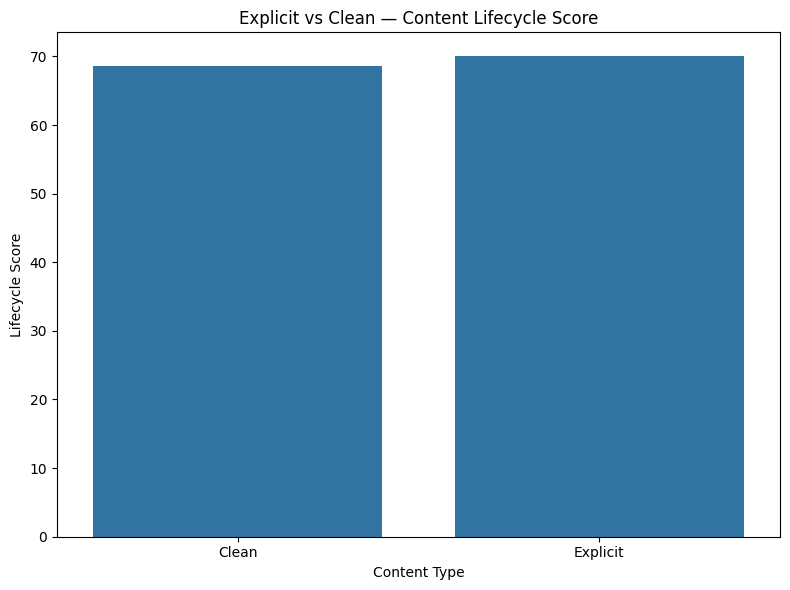

In [154]:
# Explicit Lifecycle Score Plot

plt.figure(figsize=(8, 6))

sns.barplot(
    data=explicit_score,
    x="content_type",
    y="explicit_content_lifecycle_score"
)

plt.title("Explicit vs Clean — Content Lifecycle Score")
plt.xlabel("Content Type")
plt.ylabel("Lifecycle Score")

plt.tight_layout()
plt.show()

In [155]:
# Lifecycle Stage × Content Maturity

maturity_stage = pd.crosstab(
    lifecycle["content_maturity"],
    lifecycle["lifecycle_stage"]
)

maturity_stage = maturity_stage.reindex(
    maturity_order
)

maturity_stage = maturity_stage.reindex(
    columns=stage_order,
    fill_value=0
)

display(maturity_stage)

lifecycle_stage,New Entry,Growth Phase,Peak Phase,Mature Phase,Decline Phase
content_maturity,,,,,
Fresh,10,0,19,40,7
Developing,10,0,10,11,7
Mature,39,2,19,11,20
Established,178,8,65,80,39


In [156]:
# Percentage Distribution (Raw count ke saath percentage distribution bhi useful hai)

maturity_stage_percentage = (
    maturity_stage
    .div(maturity_stage.sum(axis=1), axis=0)
    * 100
)

maturity_stage_percentage = (
    maturity_stage_percentage.round(2)
)

display(maturity_stage_percentage)

lifecycle_stage,New Entry,Growth Phase,Peak Phase,Mature Phase,Decline Phase
content_maturity,,,,,
Fresh,13.16,0.00,25.00,52.63,9.21
Developing,26.32,0.00,26.32,28.95,18.42
Mature,42.86,2.20,20.88,12.09,21.98
Established,48.11,2.16,17.57,21.62,10.54


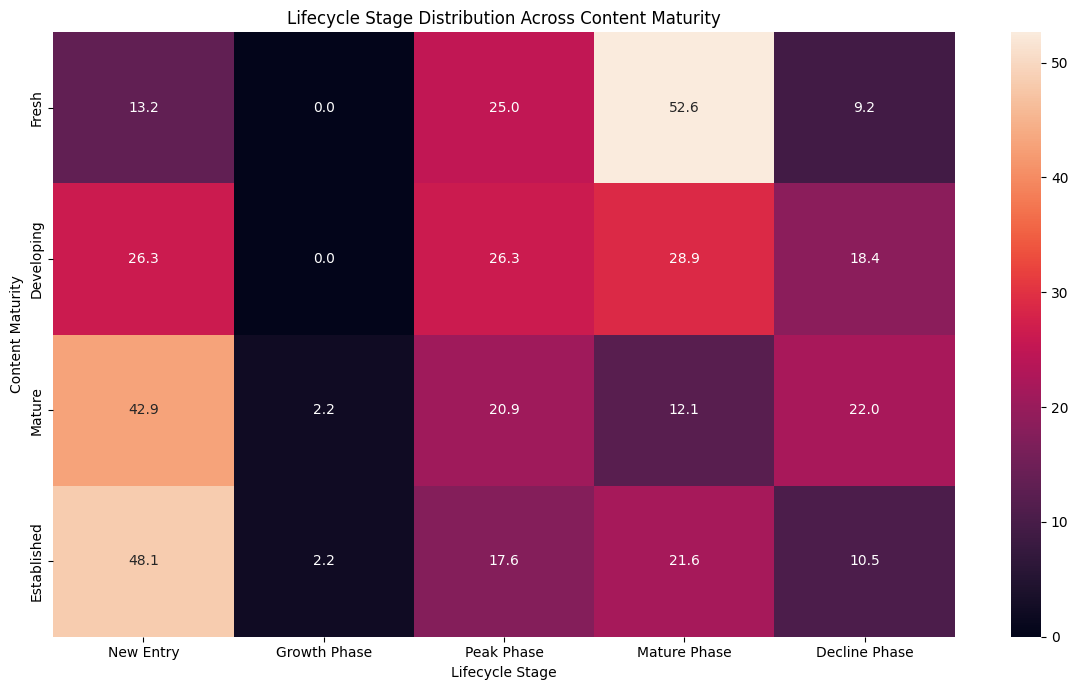

In [157]:
# Heatmap

# MATURITY × LIFECYCLE HEATMAP

plt.figure(figsize=(12, 7))

sns.heatmap(
    maturity_stage_percentage,
    annot=True,
    fmt=".1f"
)

plt.title(
    "Lifecycle Stage Distribution Across Content Maturity"
)

plt.xlabel("Lifecycle Stage")
plt.ylabel("Content Maturity")

plt.tight_layout()
plt.show()

In [158]:
# Fresh Content Performance (Fresh entries ko separately analyse karenge)

fresh_content = lifecycle[
    lifecycle["content_maturity"] == "Fresh"
].copy()

fresh_summary = {
    "Fresh Songs": fresh_content["track_key"].nunique(),
    "Average Days on Playlist":
        fresh_content["days_on_playlist"].mean(),
    "Average Time to Peak":
        fresh_content["time_to_peak_days"].mean(),
    "Average Peak Position":
        fresh_content["best_position"].mean(),
    "Average Stability":
        fresh_content["retention_stability_index"].mean(),
    "Average Continuity":
        fresh_content["continuity_percentage"].mean()
}

fresh_summary_df = pd.DataFrame(
    fresh_summary.items(),
    columns=["Metric", "Value"]
)

fresh_summary_df["Value"] = (
    fresh_summary_df["Value"].round(2)
)

display(fresh_summary_df)

,Metric,Value
0,Fresh Songs,76.00
1,Average Days on Playlist,120.12
2,Average Time to Peak,15.21
3,Average Peak Position,23.78
4,Average Stability,64.37
5,Average Continuity,85.14


In [159]:
# ESTABLISHED CONTENT PERFORMANCE

established_content = lifecycle[
    lifecycle["content_maturity"] == "Established"
].copy()

established_summary = {
    "Established Songs":
        established_content["track_key"].nunique(),

    "Average Days on Playlist":
        established_content["days_on_playlist"].mean(),

    "Average Time to Peak":
        established_content["time_to_peak_days"].mean(),

    "Average Peak Position":
        established_content["best_position"].mean(),

    "Average Stability":
        established_content["retention_stability_index"].mean(),

    "Average Continuity":
        established_content["continuity_percentage"].mean()
}

established_summary_df = pd.DataFrame(
    established_summary.items(),
    columns=["Metric", "Value"]
)

established_summary_df["Value"] = (
    established_summary_df["Value"].round(2)
)

display(established_summary_df)

,Metric,Value
0,Established Songs,370.00
1,Average Days on Playlist,38.61
2,Average Time to Peak,7.22
3,Average Peak Position,22.68
4,Average Stability,61.64
5,Average Continuity,92.60


In [160]:
# FRESH VS ESTABLISHED COMPARISON

fresh_vs_established = (
    lifecycle[
        lifecycle["content_maturity"].isin(
            ["Fresh", "Established"]
        )
    ]
    .groupby("content_maturity")
    .agg(
        songs=("track_key", "nunique"),
        avg_days_on_playlist=("days_on_playlist", "mean"),
        median_days_on_playlist=("days_on_playlist", "median"),
        avg_time_to_peak=("time_to_peak_days", "mean"),
        avg_peak_position=("best_position", "mean"),
        avg_stability=("retention_stability_index", "mean"),
        avg_continuity=("continuity_percentage", "mean"),
        avg_popularity=("peak_popularity", "mean")
    )
    .reindex(["Fresh", "Established"])
    .round(2)
)

display(fresh_vs_established)

,songs,avg_days_on_playlist,median_days_on_playlist,avg_time_to_peak,avg_peak_position,avg_stability,avg_continuity,avg_popularity
content_maturity,,,,,,,,
Fresh,76,120.12,72.0,15.21,23.78,64.37,85.14,84.07
Established,370,38.61,9.5,7.22,22.68,61.64,92.60,71.06


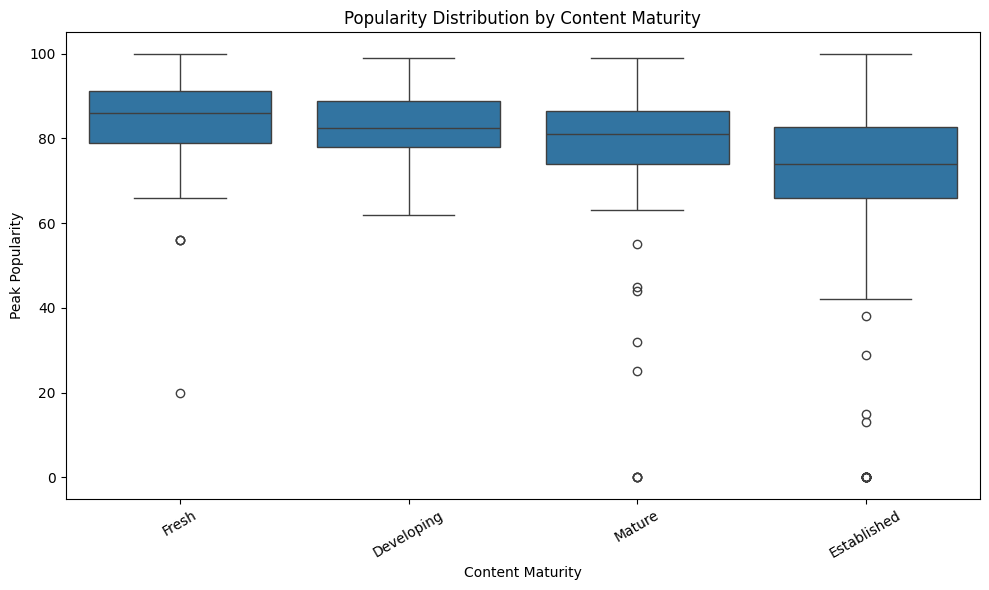

In [161]:
# Content Maturity vs Popularity

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=lifecycle,
    x="content_maturity",
    y="peak_popularity",
    order=maturity_order
)

plt.title("Popularity Distribution by Content Maturity")
plt.xlabel("Content Maturity")
plt.ylabel("Peak Popularity")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

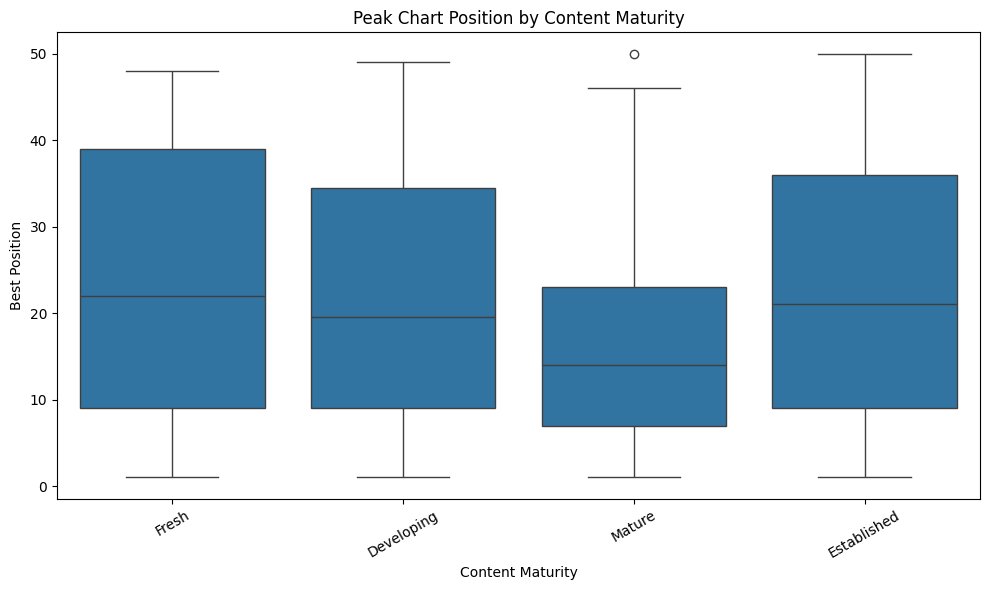

In [162]:
# Content Maturity vs Peak Position

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=lifecycle,
    x="content_maturity",
    y="best_position",
    order=maturity_order
)

plt.title("Peak Chart Position by Content Maturity")
plt.xlabel("Content Maturity")
plt.ylabel("Best Position")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

# chart position mein lower number = better performance.

In [163]:
# Content Maturity × Album Type

maturity_album = (
    lifecycle
    .groupby(
        ["content_maturity", "album_type"]
    )
    .agg(
        songs=("track_key", "nunique"),
        avg_days=("days_on_playlist", "mean"),
        avg_stability=("retention_stability_index", "mean"),
        avg_peak_position=("best_position", "mean")
    )
    .reset_index()
)

display(
    maturity_album.round(2)
)

,content_maturity,album_type,songs,avg_days,avg_stability,avg_peak_position
0,Developing,album,15,90.87,55.91,26.20
1,Developing,single,23,91.13,75.13,18.91
2,Established,album,188,26.90,60.15,23.82
3,Established,single,182,50.71,63.18,21.49
4,Fresh,album,31,119.39,60.27,29.19
5,Fresh,single,45,120.62,67.19,20.04
6,Mature,album,58,68.83,40.95,15.66
7,Mature,single,33,65.58,57.22,18.12


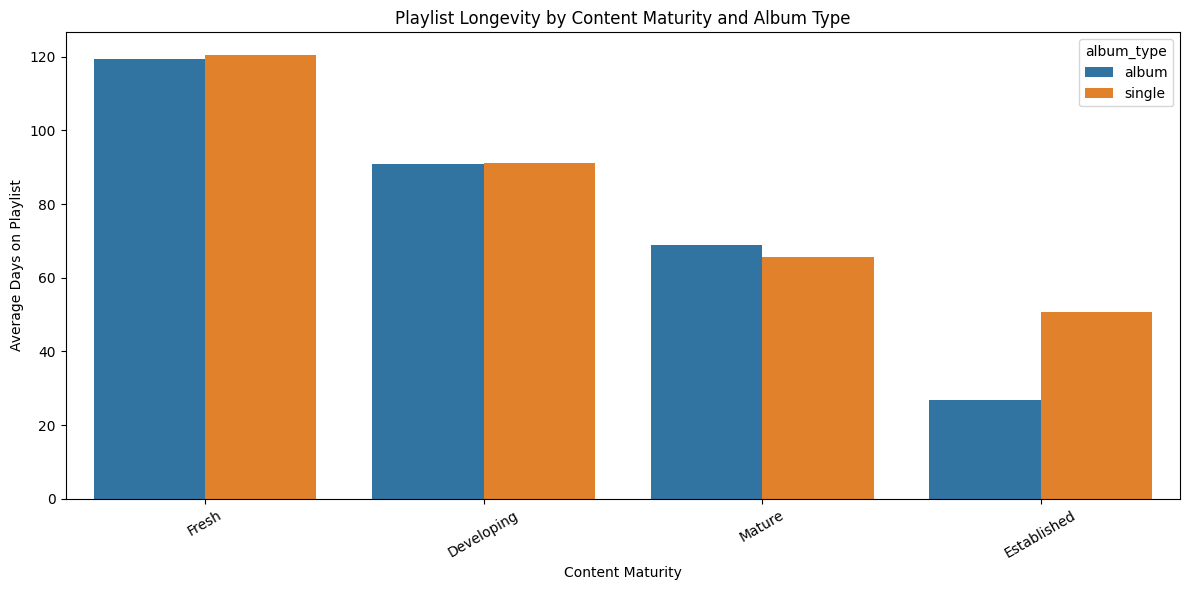

In [164]:
# Maturity × Album Type Visualization

plt.figure(figsize=(12, 6))

sns.barplot(
    data=maturity_album,
    x="content_maturity",
    y="avg_days",
    hue="album_type",
    order=maturity_order
)

plt.title(
    "Playlist Longevity by Content Maturity and Album Type"
)

plt.xlabel("Content Maturity")
plt.ylabel("Average Days on Playlist")

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [165]:
# FINAL CONTENT MATURITY KPIs

content_maturity_kpis = pd.DataFrame({
    "KPI": [
        "Total Unique Songs",
        "Fresh Songs",
        "Developing Songs",
        "Mature Songs",
        "Established Songs",
        "Average Song Longevity",
        "Average Retention Stability",
        "Average Continuity",
        "Explicit Songs",
        "Clean Songs"
    ],

    "Value": [
        lifecycle["track_key"].nunique(),

        (lifecycle["content_maturity"] == "Fresh").sum(),

        (lifecycle["content_maturity"] == "Developing").sum(),

        (lifecycle["content_maturity"] == "Mature").sum(),

        (lifecycle["content_maturity"] == "Established").sum(),

        lifecycle["days_on_playlist"].mean(),

        lifecycle["retention_stability_index"].mean(),

        lifecycle["continuity_percentage"].mean(),

        lifecycle["is_explicit"].sum(),

        (~lifecycle["is_explicit"]).sum()
    ]
})

content_maturity_kpis["Value"] = (
    content_maturity_kpis["Value"]
    .round(2)
)

display(content_maturity_kpis)

,KPI,Value
0,Total Unique Songs,575.00
1,Fresh Songs,76.00
2,Developing Songs,38.00
3,Mature Songs,91.00
4,Established Songs,370.00
5,Average Song Longevity,57.45
6,Average Retention Stability,60.05
7,Average Continuity,91.73
8,Explicit Songs,250.00
9,Clean Songs,325.00


In [166]:
# EXPORT RESULTS

lifecycle.to_csv(
    "Spain_Top50_Content_Maturity_Analysis.csv",
    index=False
)

maturity_summary.to_csv(
    "Spain_Top50_Content_Maturity_Summary.csv"
)

maturity_lifecycle.to_csv(
    "Spain_Top50_Maturity_Lifecycle_Performance.csv",
    index=False
)

explicit_maturity.to_csv(
    "Spain_Top50_Explicit_Maturity_Analysis.csv",
    index=False
)

explicit_score.to_csv(
    "Spain_Top50_Explicit_Content_Lifecycle_Score.csv",
    index=False
)

maturity_stage.to_csv(
    "Spain_Top50_Maturity_Lifecycle_Crosstab.csv"
)

fresh_vs_established.to_csv(
    "Spain_Top50_Fresh_vs_Established.csv"
)

content_maturity_kpis.to_csv(
    "Spain_Top50_Content_Maturity_KPIs.csv",
    index=False
)

print("completed successfully.")
print("Content maturity analysis files exported.")

completed successfully.
Content maturity analysis files exported.


In [167]:
# main outputs

# Content Maturity
# → Fresh → Developing → Mature → Established

# Content Maturity vs Lifecycle
# → Kaunsi maturity category zyada time Top 50 mein survive karti hai.

# Explicit vs Clean
# → Kis content type ka retention/stability better hai.

# Fresh vs Established
# → New playlist additions aur established catalog tracks ka comparison.

# Lifecycle Stage × Maturity
# → New/fresh content Growth Phase mein zyada hai ya established content Mature/Decline phase mein.

# Is analysis ko use karke Atlantic Recording Corporation new-release promotion, catalog support, playlist rotation aur content strategy ke liye
# data-backed decisions le sakta hai.

# Track Attributes & Lifecycle Drivers Analysis:

In [168]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import pearsonr, spearmanr

In [169]:
# DATA PREPARATION

# Make a copy so original lifecycle dataframe remains unchanged
drivers = lifecycle.copy()

print("Lifecycle Dataset Shape:", drivers.shape)
print("\nColumns:")
print(drivers.columns.tolist())

Lifecycle Dataset Shape: (575, 34)

Columns:
['track_key', 'song', 'artist', 'entry_date', 'exit_date', 'entry_position', 'best_position', 'exit_position', 'observations', 'entry_popularity', 'peak_popularity', 'exit_popularity', 'album_type', 'total_tracks', 'is_explicit', 'duration_min', 'calendar_days', 'days_on_playlist', 'continuity', 'continuity_percentage', 'peak_date', 'peak_position_check', 'time_to_peak_days', 'rank_slope', 'popularity_slope', 'rank_improvement', 'rank_change_entry_to_exit', 'rank_movement', 'popularity_change', 'popularity_growth_percentage', 'lifecycle_stage', 'retention_stability_index', 'entry_age_days', 'content_maturity']


In [170]:
# CHECK REQUIRED COLUMNS

required_columns = [
    "days_on_playlist",
    "time_to_peak_days",
    "best_position",
    "entry_position",
    "exit_position",
    "entry_popularity",
    "peak_popularity",
    "exit_popularity",
    "popularity_change",
    "rank_slope",
    "continuity",
    "retention_stability_index",
    "duration_min",
    "total_tracks",
    "is_explicit",
    "album_type"
]

missing_columns = [
    col for col in required_columns
    if col not in drivers.columns
]

if missing_columns:
    print("\nMissing columns:")
    print(missing_columns)
else:
    print("\nAll required columns are available.")



All required columns are available.


In [171]:
#  CREATE ADDITIONAL DRIVER METRICS

# Popularity growth from entry to peak
drivers["popularity_growth_to_peak"] = (
    drivers["peak_popularity"] -
    drivers["entry_popularity"]
)

# Popularity decay from peak to exit
drivers["popularity_decay_from_peak"] = (
    drivers["exit_popularity"] -
    drivers["peak_popularity"]
)

# Percentage popularity growth
drivers["popularity_growth_pct"] = np.where(
    drivers["entry_popularity"] > 0,
    (
        drivers["peak_popularity"] -
        drivers["entry_popularity"]
    ) / drivers["entry_popularity"] * 100,
    np.nan
)

# Percentage popularity decay
drivers["popularity_decay_pct"] = np.where(
    drivers["peak_popularity"] > 0,
    (
        drivers["exit_popularity"] -
        drivers["peak_popularity"]
    ) / drivers["peak_popularity"] * 100,
    np.nan
)

# Rank improvement
drivers["rank_improvement"] = (
    drivers["entry_position"] -
    drivers["best_position"]
)

# Absolute rank movement
drivers["absolute_rank_slope"] = (
    drivers["rank_slope"].abs()
)
print("\nAdditional driver metrics created.")


Additional driver metrics created.


In [172]:
# DURATION VS PLAYLIST LONGEVITY

print("\n--- Duration vs Playlist Longevity ---")

duration_analysis = (
    drivers
    .groupby(
        pd.cut(
            drivers["duration_min"],
            bins=[0, 2.5, 3.0, 3.5, 4.0, np.inf],
            labels=[
                "<2.5 min",
                "2.5-3 min",
                "3-3.5 min",
                "3.5-4 min",
                "4+ min"
            ]
        ),
        observed=False
    )
    .agg(
        songs=("song", "count"),
        avg_days=("days_on_playlist", "mean"),
        median_days=("days_on_playlist", "median"),
        avg_stability=("retention_stability_index", "mean"),
        avg_peak_position=("best_position", "mean"),
        avg_time_to_peak=("time_to_peak_days", "mean")
    )
    .reset_index()
)

print(duration_analysis)



--- Duration vs Playlist Longevity ---
  duration_min  songs   avg_days  median_days  avg_stability  \
0     <2.5 min     71  39.338028          7.0      64.584507   
1    2.5-3 min    159  60.232704         14.0      61.187107   
2    3-3.5 min    163  68.042945         17.0      54.703926   
3    3.5-4 min    105  55.219048         18.0      64.388190   
4       4+ min     77  48.987013         15.0      58.916883   

   avg_peak_position  avg_time_to_peak  
0          23.901408          8.492958  
1          23.150943         15.899371  
2          20.742331          6.889571  
3          20.238095          5.952381  
4          21.389610          7.467532  


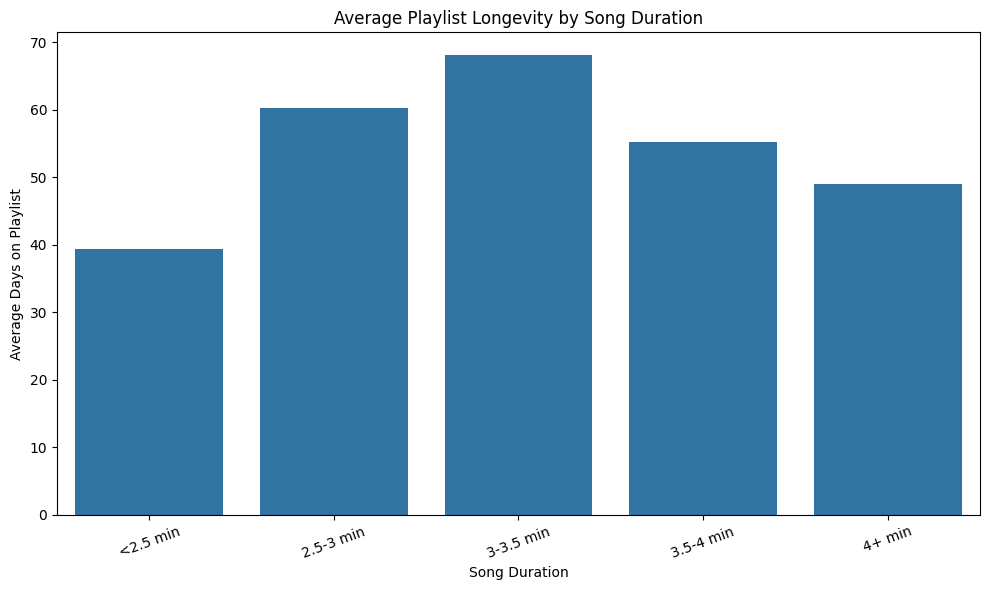

In [173]:
# Plot
plt.figure(figsize=(10, 6))

sns.barplot(
    data=duration_analysis,
    x="duration_min",
    y="avg_days"
)

plt.title("Average Playlist Longevity by Song Duration")
plt.xlabel("Song Duration")
plt.ylabel("Average Days on Playlist")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

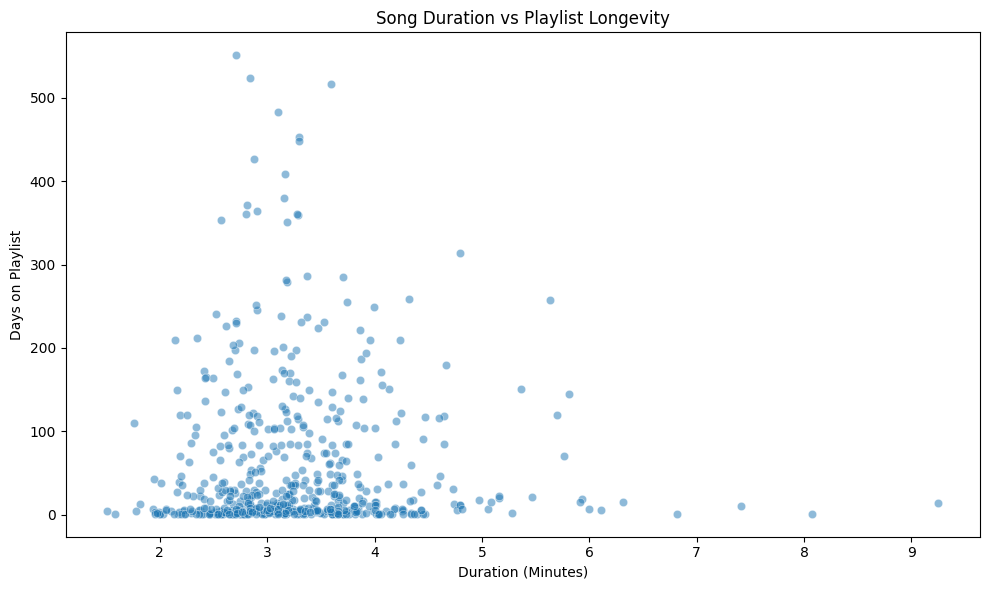

In [174]:
# Scatter plot
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=drivers,
    x="duration_min",
    y="days_on_playlist",
    alpha=0.5
)

plt.title("Song Duration vs Playlist Longevity")
plt.xlabel("Duration (Minutes)")
plt.ylabel("Days on Playlist")
plt.tight_layout()
plt.show()

In [175]:
# Correlation
duration_corr = drivers[
    ["duration_min", "days_on_playlist"]
].corr().iloc[0, 1]

print(
    f"\nDuration vs Longevity Correlation: "
    f"{duration_corr:.3f}"
)



Duration vs Longevity Correlation: 0.000


In [176]:
# 0.000 exactly aa raha hai to ye bhi check karo ki columns mein variation aur missing values hain ya nahi:

print(drivers[["duration_min", "days_on_playlist"]].describe())

print("\nMissing values:")
print(
    drivers[["duration_min", "days_on_playlist"]]
    .isna()
    .sum()
)

print("\nUnique values:")
print(
    drivers[["duration_min", "days_on_playlist"]]
    .nunique()
)

       duration_min  days_on_playlist
count    575.000000        575.000000
mean       3.272171         57.445217
std        0.834902         89.966777
min        1.510217          1.000000
25%        2.741167          4.000000
50%        3.163367         15.000000
75%        3.646533         82.500000
max        9.251183        551.000000

Missing values:
duration_min        0
days_on_playlist    0
dtype: int64

Unique values:
duration_min        535
days_on_playlist    167
dtype: int64


In [177]:
# Ab exact correlation check karo
duration_corr = drivers[
    ["duration_min", "days_on_playlist"]
].corr().iloc[0, 1]

print("Exact correlation:", duration_corr)

Exact correlation: 0.000324335781228242


In [178]:
# Correlation
duration_corr = drivers[
    ["duration_min", "days_on_playlist"]
].corr().iloc[0, 1]

print(
    f"\nDuration vs Longevity Correlation: "
    f"{duration_corr:.6f}"
)

# f"{duration_corr:.3f}" Isliye agar actual value, for example, 0.0004 ya -0.0004 hai, to output 0.000 dikhega. So use 6f


Duration vs Longevity Correlation: 0.000324


In [179]:
# ALBUM SIZE VS SONG LONGEVITY

print("\n--- Album Size vs Longevity ---")

album_size_analysis = (
    drivers
    .groupby(
        pd.cut(
            drivers["total_tracks"],
            bins=[0, 5, 10, 15, 20, 50, np.inf],
            labels=[
                "1-5",
                "6-10",
                "11-15",
                "16-20",
                "21-50",
                "50+"
            ]
        ),
        observed=False
    )
    .agg(
        songs=("song", "count"),
        avg_days=("days_on_playlist", "mean"),
        avg_stability=("retention_stability_index", "mean"),
        avg_peak_position=("best_position", "mean")
    )
    .reset_index()
)

print(album_size_analysis)



--- Album Size vs Longevity ---
  total_tracks  songs   avg_days  avg_stability  avg_peak_position
0          1-5    275  68.374545      63.605345          20.323636
1         6-10     56  51.303571      63.736607          25.946429
2        11-15     85  50.858824      51.485294          23.600000
3        16-20    119  40.226891      59.954202          22.235294
4        21-50     40  56.125000      48.920750          20.925000
5          50+      0        NaN            NaN                NaN


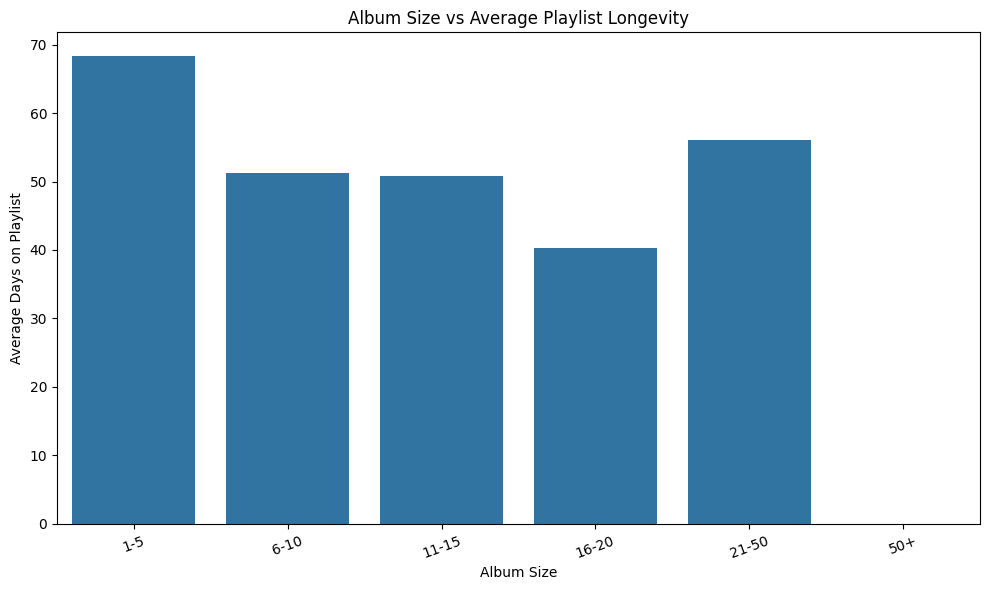

In [180]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=album_size_analysis,
    x="total_tracks",
    y="avg_days"
)

plt.title("Album Size vs Average Playlist Longevity")
plt.xlabel("Album Size")
plt.ylabel("Average Days on Playlist")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [181]:
# Correlation
album_size_corr = drivers[
    ["total_tracks", "days_on_playlist"]
].corr().iloc[0, 1]

print(
    f"\nAlbum Size vs Longevity Correlation: "
    f"{album_size_corr:.3f}"
)


Album Size vs Longevity Correlation: -0.121


In [182]:
# ENTRY POPULARITY VS LIFECYCLE PERFORMANCE

print("\n--- Entry Popularity Analysis ---")

entry_popularity_analysis = (
    drivers
    .groupby(
        pd.qcut(
            drivers["entry_popularity"],
            q=4,
            duplicates="drop"
        ),
        observed=False
    )
    .agg(
        songs=("song", "count"),
        avg_days=("days_on_playlist", "mean"),
        avg_time_to_peak=("time_to_peak_days", "mean"),
        avg_peak_position=("best_position", "mean"),
        avg_stability=("retention_stability_index", "mean"),
        avg_peak_popularity=("peak_popularity", "mean")
    )
    .reset_index()
)

print(entry_popularity_analysis)



--- Entry Popularity Analysis ---
  entry_popularity  songs   avg_days  avg_time_to_peak  avg_peak_position  \
0   (-0.001, 53.0]    148  44.243243          5.662162          21.986486   
1     (53.0, 64.0]    143  39.349650          4.629371          22.377622   
2     (64.0, 74.0]    148  55.891892         11.141892          20.581081   
3    (74.0, 100.0]    136  92.529412         16.948529          22.286765   

   avg_stability  avg_peak_popularity  
0      56.418446            61.689189  
1      57.124476            70.895105  
2      65.040743            77.641892  
3      61.644044            87.816176  


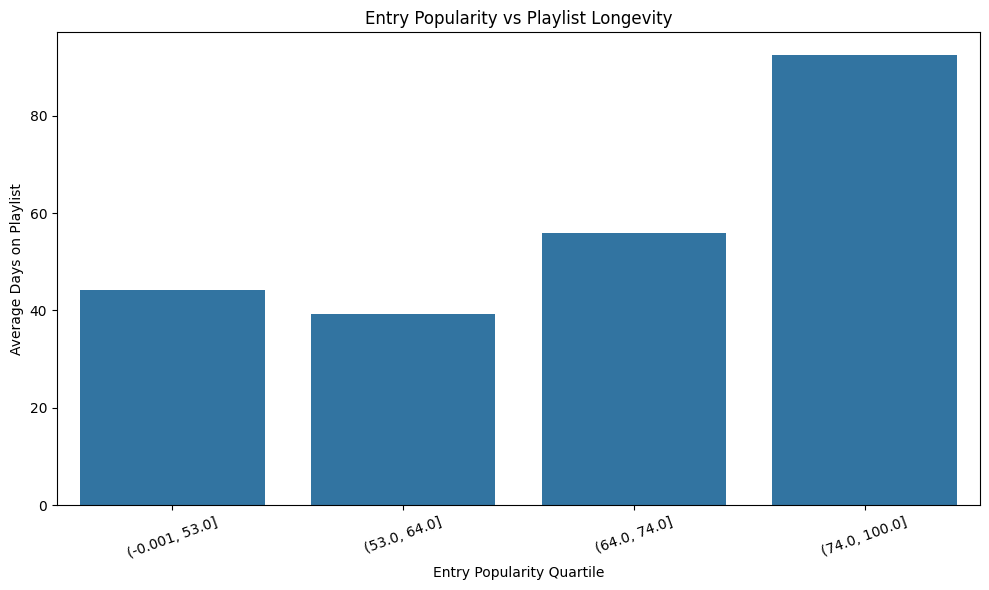

In [183]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=entry_popularity_analysis,
    x="entry_popularity",
    y="avg_days"
)

plt.title("Entry Popularity vs Playlist Longevity")
plt.xlabel("Entry Popularity Quartile")
plt.ylabel("Average Days on Playlist")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

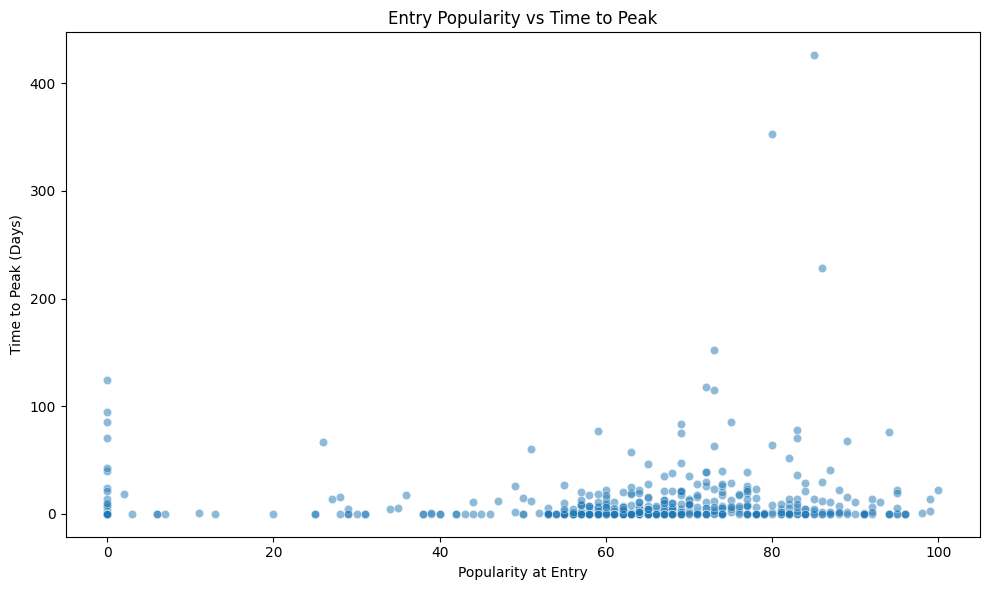

In [184]:
# ENTRY POPULARITY VS TIME TO PEAK

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=drivers,
    x="entry_popularity",
    y="time_to_peak_days",
    alpha=0.5
)

plt.title("Entry Popularity vs Time to Peak")
plt.xlabel("Popularity at Entry")
plt.ylabel("Time to Peak (Days)")
plt.tight_layout()
plt.show()

In [185]:
entry_peak_corr = drivers[
    ["entry_popularity", "time_to_peak_days"]
].corr().iloc[0, 1]

print(
    f"\nEntry Popularity vs Time to Peak Correlation: "
    f"{entry_peak_corr:.3f}"
)


Entry Popularity vs Time to Peak Correlation: 0.110



--- Popularity Growth vs Rank Improvement ---


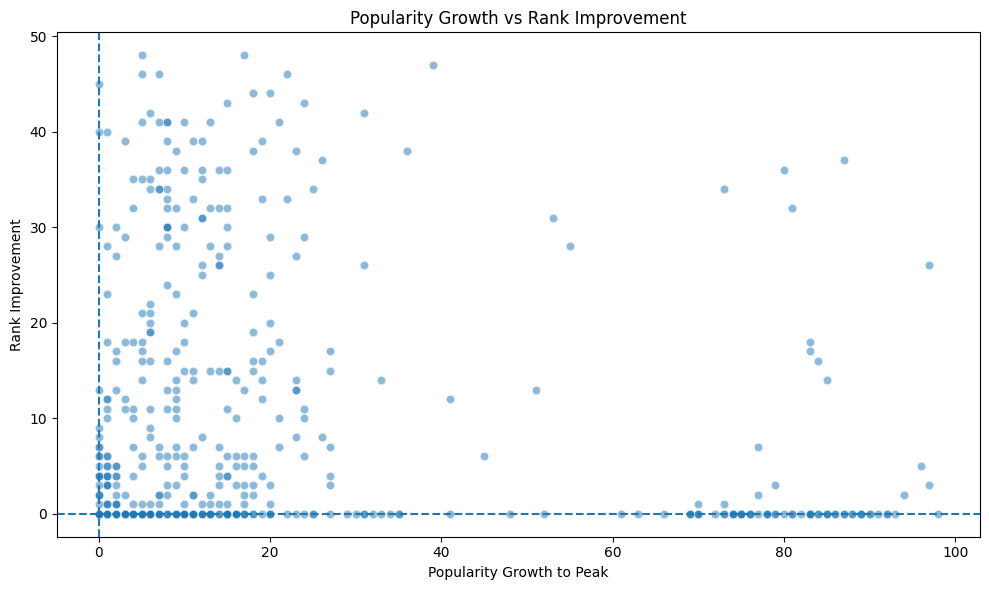

In [186]:
# POPULARITY GROWTH VS RANK IMPROVEMENT
# ============================================================

print("\n--- Popularity Growth vs Rank Improvement ---")

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=drivers,
    x="popularity_growth_to_peak",
    y="rank_improvement",
    alpha=0.5
)

plt.axhline(0, linestyle="--")
plt.axvline(0, linestyle="--")

plt.title("Popularity Growth vs Rank Improvement")
plt.xlabel("Popularity Growth to Peak")
plt.ylabel("Rank Improvement")
plt.tight_layout()
plt.show()


In [187]:
growth_rank_corr = drivers[
    [
        "popularity_growth_to_peak",
        "rank_improvement"
    ]
].corr().iloc[0, 1]

print(
    f"\nPopularity Growth vs Rank Improvement "
    f"Correlation: {growth_rank_corr:.3f}"
)


Popularity Growth vs Rank Improvement Correlation: -0.051


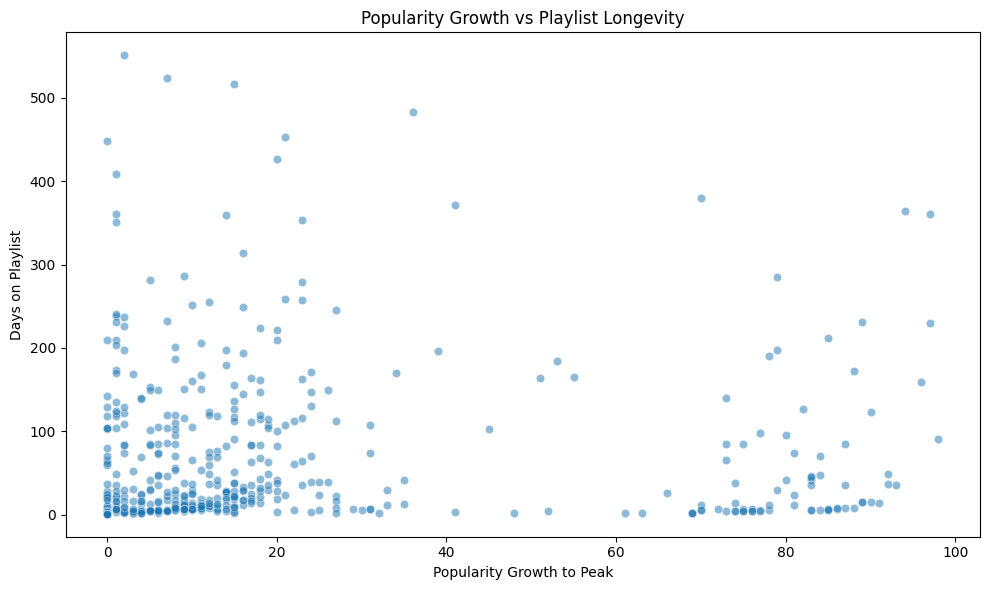

In [188]:
# POPULARITY GROWTH VS PLAYLIST LONGEVITY

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=drivers,
    x="popularity_growth_to_peak",
    y="days_on_playlist",
    alpha=0.5
)

plt.title("Popularity Growth vs Playlist Longevity")
plt.xlabel("Popularity Growth to Peak")
plt.ylabel("Days on Playlist")
plt.tight_layout()
plt.show()


In [189]:
growth_longevity_corr = drivers[
    [
        "popularity_growth_to_peak",
        "days_on_playlist"
    ]
].corr().iloc[0, 1]

print(
    f"\nPopularity Growth vs Longevity Correlation: "
    f"{growth_longevity_corr:.3f}"
)



Popularity Growth vs Longevity Correlation: 0.115


In [190]:
# EXPLICIT VS CLEAN DRIVER COMPARISON


print("\n--- Explicit vs Clean Driver Comparison ---")

explicit_driver_analysis = (
    drivers
    .groupby("is_explicit")
    .agg(
        songs=("song", "count"),
        avg_days=("days_on_playlist", "mean"),
        avg_time_to_peak=("time_to_peak_days", "mean"),
        avg_peak_position=("best_position", "mean"),
        avg_stability=("retention_stability_index", "mean"),
        avg_popularity_growth=("popularity_growth_to_peak", "mean"),
        avg_duration=("duration_min", "mean")
    )
    .reset_index()
)

explicit_driver_analysis["content_type"] = (
    explicit_driver_analysis["is_explicit"]
    .map({
        True: "Explicit",
        False: "Clean"
    })
)

print(
    explicit_driver_analysis[
        [
            "content_type",
            "songs",
            "avg_days",
            "avg_time_to_peak",
            "avg_peak_position",
            "avg_stability",
            "avg_popularity_growth",
            "avg_duration"
        ]
    ]
)


--- Explicit vs Clean Driver Comparison ---
  content_type  songs   avg_days  avg_time_to_peak  avg_peak_position  \
0        Clean    325  59.876923             9.640          22.052308   
1     Explicit    250  54.284000             9.284          21.456000   

   avg_stability  avg_popularity_growth  avg_duration  
0      59.254646                  14.88      3.148342  
1      61.082360                  22.68      3.433148  


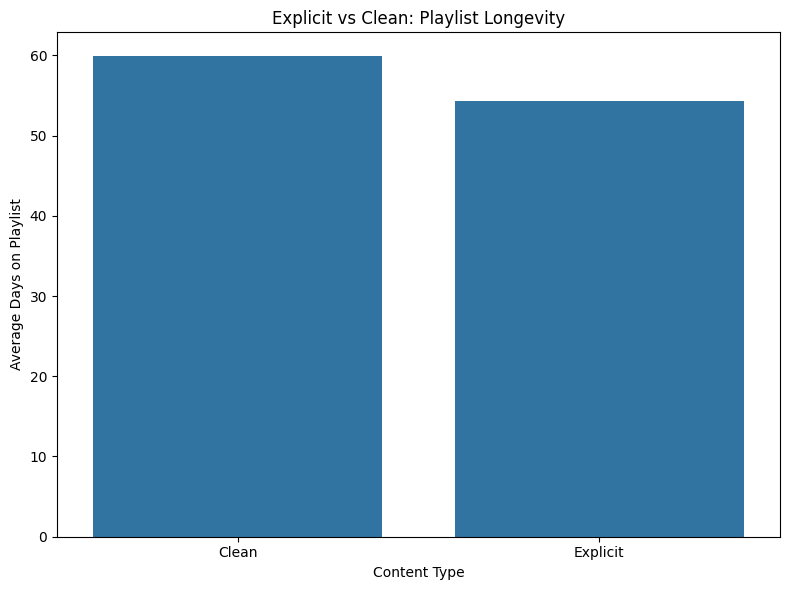

In [191]:
plt.figure(figsize=(8, 6))

sns.barplot(
    data=explicit_driver_analysis,
    x="content_type",
    y="avg_days"
)

plt.title("Explicit vs Clean: Playlist Longevity")
plt.xlabel("Content Type")
plt.ylabel("Average Days on Playlist")
plt.tight_layout()
plt.show()


In [192]:
# SINGLE VS ALBUM DRIVER COMPARISON

print("\n--- Single vs Album Driver Comparison ---")

album_driver_analysis = (
    drivers
    .groupby("album_type")
    .agg(
        songs=("song", "count"),
        avg_days=("days_on_playlist", "mean"),
        avg_time_to_peak=("time_to_peak_days", "mean"),
        avg_peak_position=("best_position", "mean"),
        avg_stability=("retention_stability_index", "mean"),
        avg_popularity_growth=("popularity_growth_to_peak", "mean"),
        avg_entry_popularity=("entry_popularity", "mean")
    )
    .reset_index()
)

print(album_driver_analysis)


--- Single vs Album Driver Comparison ---
  album_type  songs   avg_days  avg_time_to_peak  avg_peak_position  \
0      album    292  48.332192          8.643836          22.893836   
1     single    283  66.848057         10.353357          20.657244   

   avg_stability  avg_popularity_growth  avg_entry_popularity  
0      56.130959              22.736301             47.842466  
1      64.092261              13.664311             64.402827  


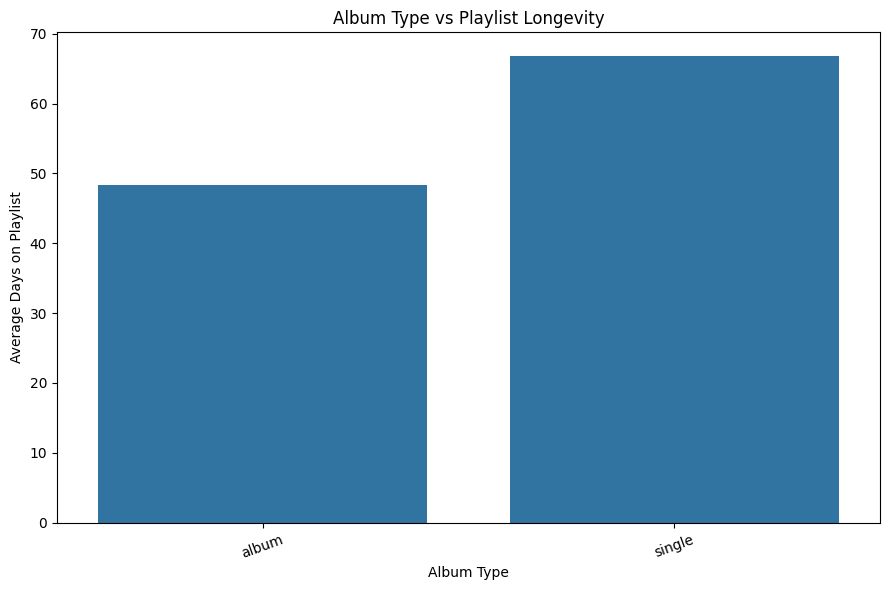

In [193]:
plt.figure(figsize=(9, 6))

sns.barplot(
    data=album_driver_analysis,
    x="album_type",
    y="avg_days"
)

plt.title("Album Type vs Playlist Longevity")
plt.xlabel("Album Type")
plt.ylabel("Average Days on Playlist")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


In [194]:
# CORRELATION MATRIX — LIFECYCLE DRIVERS

driver_columns = [
    "duration_min",
    "total_tracks",
    "entry_position",
    "best_position",
    "entry_popularity",
    "peak_popularity",
    "exit_popularity",
    "popularity_growth_to_peak",
    "popularity_decay_from_peak",
    "time_to_peak_days",
    "days_on_playlist",
    "continuity",
    "rank_slope",
    "rank_improvement",
    "retention_stability_index"
]

driver_corr = drivers[driver_columns].corr()


plt.figure(figsize=(15, 11))


<Figure size 1500x1100 with 0 Axes>

<Figure size 1500x1100 with 0 Axes>

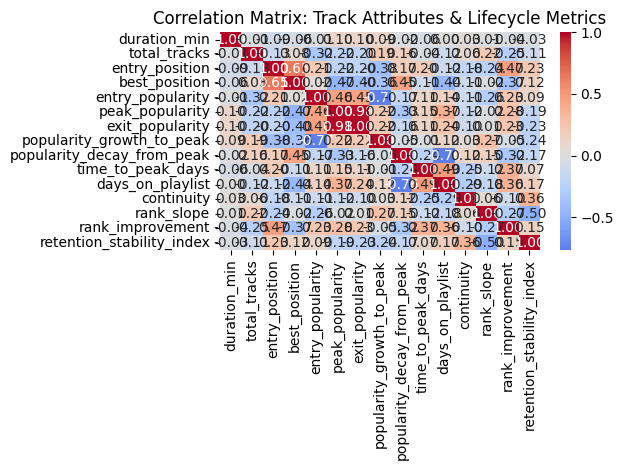

In [195]:
sns.heatmap(
    driver_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix: Track Attributes & Lifecycle Metrics")
plt.tight_layout()
plt.show()


In [196]:
# SPEARMAN CORRELATION
# Spearman is useful because relationships may not be linear.

spearman_results = []

for column in [
    "duration_min",
    "total_tracks",
    "entry_position",
    "entry_popularity",
    "peak_popularity",
    "popularity_growth_to_peak",
    "time_to_peak_days"
]:

    temp = drivers[
        [column, "days_on_playlist"]
    ].dropna()

    if len(temp) > 2:

        correlation, p_value = spearmanr(
            temp[column],
            temp["days_on_playlist"]
        )

        spearman_results.append({
            "variable": column,
            "spearman_correlation": correlation,
            "p_value": p_value
        })


spearman_results = pd.DataFrame(
    spearman_results
)

print("\nSpearman Correlations:")
print(spearman_results)



Spearman Correlations:
                    variable  spearman_correlation       p_value
0               duration_min              0.083958  4.417562e-02
1               total_tracks             -0.253849  6.604981e-10
2             entry_position             -0.148794  3.434210e-04
3           entry_popularity              0.254307  6.140233e-10
4            peak_popularity              0.649160  4.255751e-70
5  popularity_growth_to_peak              0.458576  3.038231e-31
6          time_to_peak_days              0.626663  4.658093e-64


In [197]:
# TOP POSITIVE / NEGATIVE LIFECYCLE DRIVERS

driver_target_corr = (
    driver_corr["days_on_playlist"]
    .drop("days_on_playlist")
    .sort_values()
)

print("\n--- Negative Relationships with Longevity ---")
print(driver_target_corr.head(5))

print("\n--- Positive Relationships with Longevity ---")
print(driver_target_corr.tail(5))


--- Negative Relationships with Longevity ---
popularity_decay_from_peak   -0.763969
best_position                -0.438132
continuity                   -0.286020
rank_slope                   -0.180468
entry_position               -0.124560
Name: days_on_playlist, dtype: float64

--- Positive Relationships with Longevity ---
retention_stability_index    0.169362
exit_popularity              0.240613
rank_improvement             0.356668
peak_popularity              0.366242
time_to_peak_days            0.487957
Name: days_on_playlist, dtype: float64


In [198]:
# TRACK PERFORMANCE SEGMENTATION

def classify_track_performance(row):

    if (
        row["days_on_playlist"] >=
        drivers["days_on_playlist"].quantile(0.75)
        and
        row["retention_stability_index"] >=
        drivers["retention_stability_index"].quantile(0.75)
    ):
        return "High Retention & Stable"

    elif (
        row["days_on_playlist"] >=
        drivers["days_on_playlist"].median()
    ):
        return "Long Retention"

    elif (
        row["retention_stability_index"] >=
        drivers["retention_stability_index"].median()
    ):
        return "Stable but Shorter"

    else:
        return "Low Retention"


drivers["performance_segment"] = drivers.apply(
    classify_track_performance,
    axis=1
)


performance_summary = (
    drivers
    .groupby("performance_segment")
    .agg(
        songs=("song", "count"),
        avg_days=("days_on_playlist", "mean"),
        avg_stability=("retention_stability_index", "mean"),
        avg_entry_popularity=("entry_popularity", "mean"),
        avg_peak_popularity=("peak_popularity", "mean"),
        avg_peak_position=("best_position", "mean"),
        avg_duration=("duration_min", "mean")
      )
    .reset_index()
)

print("\nTrack Performance Segments:")
print(performance_summary)


Track Performance Segments:
       performance_segment  songs    avg_days  avg_stability  \
0  High Retention & Stable     29  207.379310      91.127241   
1           Long Retention    262   98.236641      62.753511   
2            Low Retention    165    5.915152      24.475394   
3       Stable but Shorter    119    2.546218      95.847059   

   avg_entry_popularity  avg_peak_popularity  avg_peak_position  avg_duration  
0             52.689655            85.172414           6.241379      3.072591  
1             61.969466            82.732824          15.396947      3.335958  
2             49.569697            72.806061          24.115152      3.271371  
3             52.546218            54.983193          36.445378      3.181479  


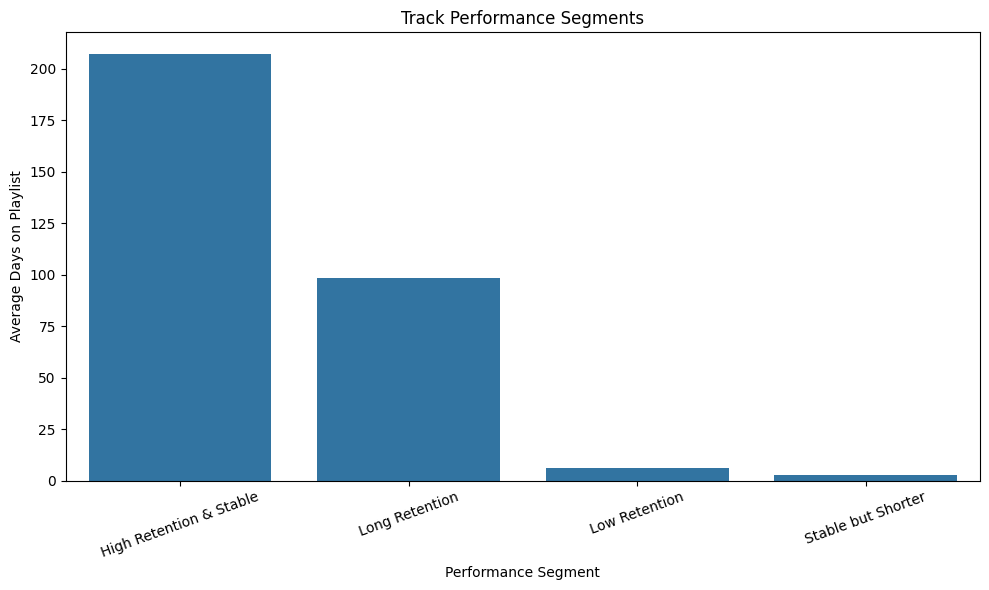

In [199]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=performance_summary,
    x="performance_segment",
    y="avg_days"
)

plt.title("Track Performance Segments")
plt.xlabel("Performance Segment")
plt.ylabel("Average Days on Playlist")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [200]:
# TOP HIGH-RETENTION SONGS

top_retention_songs = (
    drivers
    .sort_values(
        [
            "days_on_playlist",
            "retention_stability_index"
        ],
        ascending=[False, False]
    )
    [
        [
            "song",
            "artist",
            "days_on_playlist",
            "retention_stability_index",
            "best_position",
            "entry_popularity",
            "peak_popularity",
            "album_type",
            "is_explicit"
        ]
    ]
    .head(20)
)

print("\nTop 20 High-Retention Songs:")
print(top_retention_songs)


Top 20 High-Retention Songs:
                    song                                   artist  \
265           La Bachata                            Manuel Turizo   
29              AMARGURA                                  KAROL G   
546            VAGABUNDO  Sebastian Yatra & Manuel Turizo & Beéle   
97              Columbia                                  Quevedo   
293                 LALA                              Myke Towers   
524                  TQG                                  KAROL G   
429                QLONA                                  KAROL G   
26               Amanece                          Anuel AA & Haze   
167          El Merengue                               Marshmello   
325          Manos Rotas                      DELLAFUENTE & Morad   
269             LA FALDA                              Myke Towers   
312                 LUNA                                     Feid   
342  Mi Luz (ft. Rels B)                                     Rvfv   
145 

In [201]:
# FASTEST GROWING SONGS

fastest_growing = (
    drivers
    .sort_values(
        "rank_slope",
        ascending=True
    )
    [
        [
            "song",
            "artist",
            "rank_slope",
            "rank_improvement",
            "entry_position",
            "best_position",
            "time_to_peak_days",
            "days_on_playlist"
        ]
    ]
    .head(20)
)

print("\nTop 20 Fastest Improving Songs:")
print(fastest_growing)



Top 20 Fastest Improving Songs:
                                       song                           artist  \
117                        Cosas Pendientes                           Maluma   
296         Last Christmas - Single Version                            Wham!   
458       Rockin' Around The Christmas Tree                       Brenda Lee   
103                                COMUNA 3         JC Reyes & The Rude Boyz   
132  DEMO #5: nostalgIA - Spanglish Version                          FlowGPT   
106                                Conexión                  Cano & JC Reyes   
462                               rompeolas                   Martin Urrutia   
133                               DEPORTIVO                Blessd & Anuel AA   
5                                       2AM       Sebastian Yatra & Bad Gyal   
327                      Maquillaje - Remix  Renn & Myke Towers & Nio Garcia   
115                                CORLEONE                   Saiko & Yandel   
210    

In [202]:
# STRONGEST POPULARITY GROWTH

strongest_popularity_growth = (
    drivers
    .sort_values(
        "popularity_growth_to_peak",
        ascending=False
    )
    [
        [
            "song",
            "artist",
            "entry_popularity",
            "peak_popularity",
            "popularity_growth_to_peak",
            "popularity_growth_pct",
            "days_on_playlist"
        ]
    ]
    .head(20)
)

print("\nTop 20 Songs by Popularity Growth:")
print(strongest_popularity_growth)


Top 20 Songs by Popularity Growth:
                             song          artist  entry_popularity  \
354                        MONACO       Bad Bunny                 0   
408                   PERRO NEGRO       Bad Bunny                 0   
312                          LUNA            Feid                 0   
483  Si Antes Te Hubiera Conocido         KAROL G                 0   
269                      LA FALDA     Myke Towers                 0   
199                          FINA       Bad Bunny                 0   
240                        HIBIKI       Bad Bunny                 0   
536                    UN PREVIEW       Bad Bunny                 0   
363     New Woman (feat. ROSALÍA)  LISA & ROSALÍA                 0   
46                     BABY NUEVA       Bad Bunny                 0   
476                          SEDA       Bad Bunny                 0   
359                    NADIE SABE       Bad Bunny                 0   
513                TELEFONO NUEVO       B

In [203]:
# DRIVER SUMMARY TABLE

driver_summary = pd.DataFrame({
    "Driver": [
        "Song Duration",
        "Album Size",
        "Entry Position",
        "Entry Popularity",
        "Peak Popularity",
        "Popularity Growth",
        "Time to Peak",
        "Rank Improvement",
        "Continuity",
        "Retention Stability"
    ],

    "Correlation_with_Longevity": [
        drivers["duration_min"].corr(
            drivers["days_on_playlist"]
        ),

        drivers["total_tracks"].corr(
            drivers["days_on_playlist"]
        ),

        drivers["entry_position"].corr(
            drivers["days_on_playlist"]
        ),

        drivers["entry_popularity"].corr(
            drivers["days_on_playlist"]
        ),

        drivers["peak_popularity"].corr(
            drivers["days_on_playlist"]
        ),

        drivers["popularity_growth_to_peak"].corr(
            drivers["days_on_playlist"]
        ),

        drivers["time_to_peak_days"].corr(
            drivers["days_on_playlist"]
        ),drivers["rank_improvement"].corr(
            drivers["days_on_playlist"]
        ),

        drivers["continuity"].corr(
            drivers["days_on_playlist"]
        ),

        drivers["retention_stability_index"].corr(
            drivers["days_on_playlist"]
        )
    ]
})


driver_summary["Absolute_Correlation"] = (
    driver_summary[
        "Correlation_with_Longevity"
    ].abs()
)

driver_summary = driver_summary.sort_values(
    "Absolute_Correlation",
    ascending=False
)

print("\n================================================")
print("LIFECYCLE DRIVER SUMMARY")
print("================================================")

print(driver_summary)




LIFECYCLE DRIVER SUMMARY
                Driver  Correlation_with_Longevity  Absolute_Correlation
6         Time to Peak                    0.487957              0.487957
4      Peak Popularity                    0.366242              0.366242
7     Rank Improvement                    0.356668              0.356668
8           Continuity                   -0.286020              0.286020
9  Retention Stability                    0.169362              0.169362
3     Entry Popularity                    0.136922              0.136922
2       Entry Position                   -0.124560              0.124560
1           Album Size                   -0.120789              0.120789
5    Popularity Growth                    0.115168              0.115168
0        Song Duration                    0.000324              0.000324


In [204]:
# FINAL INSIGHT TABLE

final_driver_insights = pd.DataFrame({

    "Metric": [
        "Duration-Longevity Correlation",
        "Album Size-Longevity Correlation",
        "Entry Popularity-Longevity Correlation",
        "Popularity Growth-Longevity Correlation",
        "Entry Popularity-Time to Peak Correlation",
        "Popularity Growth-Rank Improvement Correlation",
        "Average Explicit Longevity",
        "Average Clean Longevity"
    ],

    "Value": [
        round(duration_corr, 4),
        round(album_size_corr, 4),
        round(
            drivers[
                "entry_popularity"
            ].corr(
                drivers["days_on_playlist"]
            ),
            4
        ),
        round(growth_longevity_corr, 4),
        round(entry_peak_corr, 4),
        round(growth_rank_corr, 4),

        round(
            explicit_driver_analysis.loc[
                explicit_driver_analysis["is_explicit"] == True,
                "avg_days"
            ].iloc[0],
            2
        )
        if True in explicit_driver_analysis["is_explicit"].values
        else np.nan,

        round(
            explicit_driver_analysis.loc[
                explicit_driver_analysis["is_explicit"] == False,
                "avg_days"  ].iloc[0],
            2
        )
        if False in explicit_driver_analysis["is_explicit"].values
        else np.nan
    ]
})

print("\nFinal Driver Insights:")
print(final_driver_insights)


Final Driver Insights:
                                           Metric    Value
0                  Duration-Longevity Correlation   0.0003
1                Album Size-Longevity Correlation  -0.1208
2          Entry Popularity-Longevity Correlation   0.1369
3         Popularity Growth-Longevity Correlation   0.1152
4       Entry Popularity-Time to Peak Correlation   0.1097
5  Popularity Growth-Rank Improvement Correlation  -0.0505
6                      Average Explicit Longevity  54.2800
7                         Average Clean Longevity  59.8800


In [205]:
# EXPORT RESULTS

duration_analysis.to_csv(
    "Spain_Top50_Duration_Longevity_Analysis.csv",
    index=False
)

album_size_analysis.to_csv(
    "Spain_Top50_Album_Size_Longevity_Analysis.csv",
    index=False
)

entry_popularity_analysis.to_csv(
    "Spain_Top50_Entry_Popularity_Analysis.csv",
    index=False
)

explicit_driver_analysis.to_csv(
    "Spain_Top50_Explicit_vs_Clean_Drivers.csv",
    index=False
)

album_driver_analysis.to_csv(
    "Spain_Top50_Album_Type_Drivers.csv",
    index=False
)

spearman_results.to_csv(
    "Spain_Top50_Spearman_Driver_Analysis.csv",
    index=False
)

driver_summary.to_csv(
    "Spain_Top50_Lifecycle_Driver_Summary.csv",
    index=False
)

top_retention_songs.to_csv(
    "Spain_Top50_Top_Retention_Songs.csv",
    index=False
)

fastest_growing.to_csv(
    "Spain_Top50_Fastest_Growing_Songs.csv",
    index=False)

strongest_popularity_growth.to_csv(
    "Spain_Top50_Strongest_Popularity_Growth.csv",
    index=False
)

performance_summary.to_csv(
    "Spain_Top50_Track_Performance_Segments.csv",
    index=False
)

final_driver_insights.to_csv(
    "Spain_Top50_Final_Driver_Insights.csv",
    index=False
)

print("\n================================================")
print("COMPLETED SUCCESSFULLY")
print("================================================")
print("All driver analysis files exported.")


COMPLETED SUCCESSFULLY
All driver analysis files exported.


In [206]:
# main outputs:
# Analysis	                            Business Question
# Duration vs Longevity	                Kya song length retention se associated hai?
# Album Size vs Longevity	            Album size ka lifecycle se relation
# Entry Popularity	                    Popular songs kitni jaldi peak karte hain
# Popularity Growth	                    Growth aur ranking improvement ka relation
# Explicit vs Clean	                    Content type lifecycle difference
# Single vs Album	                    Release format longevity
# Correlation Matrix	                Strongest lifecycle relationships
# Performance Segmentation	            High-retention songs identify karna
# Top Retention Songs	                Longest-lasting tracks
# Fastest Growing Songs	                Rapidly improving tracks

# Statistical Testing & Driver Validation:

In [207]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import (
    pearsonr,
    spearmanr,
    ttest_ind,
    mannwhitneyu,
    f_oneway,
    kruskal,
    chi2_contingency
)

import warnings
warnings.filterwarnings("ignore")


In [208]:
#  DATA PREPARATION

stats_df = lifecycle.copy()

print("Dataset Shape:", stats_df.shape)

print("\nColumns:")
print(stats_df.columns.tolist())


Dataset Shape: (575, 34)

Columns:
['track_key', 'song', 'artist', 'entry_date', 'exit_date', 'entry_position', 'best_position', 'exit_position', 'observations', 'entry_popularity', 'peak_popularity', 'exit_popularity', 'album_type', 'total_tracks', 'is_explicit', 'duration_min', 'calendar_days', 'days_on_playlist', 'continuity', 'continuity_percentage', 'peak_date', 'peak_position_check', 'time_to_peak_days', 'rank_slope', 'popularity_slope', 'rank_improvement', 'rank_change_entry_to_exit', 'rank_movement', 'popularity_change', 'popularity_growth_percentage', 'lifecycle_stage', 'retention_stability_index', 'entry_age_days', 'content_maturity']


In [209]:
# Ensure numeric columns

numeric_columns = [
    "days_on_playlist",
    "time_to_peak_days",
    "best_position",
    "entry_position",
    "exit_position",
    "entry_popularity",
    "peak_popularity",
    "exit_popularity",
    "rank_slope",
    "continuity",
    "retention_stability_index",
    "duration_min",
    "total_tracks"
]

for col in numeric_columns:
    if col in stats_df.columns:
        stats_df[col] = pd.to_numeric(
            stats_df[col],
            errors="coerce"
        )


In [210]:
# STATISTICAL SIGNIFICANCE HELPER

def significance_label(p_value):

    if p_value < 0.001:
        return "Highly Significant"

    elif p_value < 0.01:
        return "Very Significant"

    elif p_value < 0.05:
        return "Significant"

    else:
        return "Not Significant"


def effect_strength(correlation):

    value = abs(correlation)

    if value < 0.10:
        return "Very Weak"

    elif value < 0.30:
        return "Weak"

    elif value < 0.50:
        return "Moderate"

    elif value < 0.70:
        return "Strong"

    else:
        return "Very Strong"

In [211]:
# PEARSON CORRELATION TESTS

print("\n================================================")
print("PEARSON CORRELATION TESTS")
print("================================================")


pearson_variables = [
    "duration_min",
    "total_tracks",
    "entry_position",
    "entry_popularity",
    "peak_popularity",
    "time_to_peak_days",
    "rank_slope",
    "continuity"
]


pearson_results = []


for variable in pearson_variables:

    temp = stats_df[
        [variable, "days_on_playlist"]
    ].dropna()

    if len(temp) >= 3:

        r_value, p_value = pearsonr(
            temp[variable],
            temp["days_on_playlist"]
        )

        pearson_results.append({ "Variable": variable,

            "Correlation": r_value,

            "P_Value": p_value,

            "Significance": significance_label(
                p_value
            ),

            "Effect_Strength": effect_strength(
                r_value
            ),

            "Sample_Size": len(temp)
        })


pearson_results = pd.DataFrame(
    pearson_results
)

print(pearson_results)

# The correlation analysis indicates that track duration has virtually no relationship with playlist longevity. 
# In contrast, peak popularity and time to peak show moderate and statistically significant relationships with longevity. 
# Among the examined variables, time to peak exhibits the strongest association (r = 0.488), suggesting that tracks with a more gradual 
# rise toward peak performance may have longer playlist lifecycles. These findings indicate that lifecycle dynamics and popularity are more 
# relevant to playlist retention than song duration alone


PEARSON CORRELATION TESTS
            Variable  Correlation       P_Value        Significance  \
0       duration_min     0.000324  9.938082e-01     Not Significant   
1       total_tracks    -0.120789  3.722690e-03    Very Significant   
2     entry_position    -0.124560  2.771453e-03    Very Significant   
3   entry_popularity     0.136922  9.960685e-04  Highly Significant   
4    peak_popularity     0.366242  1.081131e-19  Highly Significant   
5  time_to_peak_days     0.487957  9.895138e-36  Highly Significant   
6         rank_slope    -0.180468  1.337718e-05  Highly Significant   
7         continuity    -0.286020  2.746153e-12  Highly Significant   

  Effect_Strength  Sample_Size  
0       Very Weak          575  
1            Weak          575  
2            Weak          575  
3            Weak          575  
4        Moderate          575  
5        Moderate          575  
6            Weak          575  
7            Weak          575  


In [212]:
# SPEARMAN CORRELATION TESTS

print("\n================================================")
print("SPEARMAN CORRELATION TESTS")
print("================================================")


spearman_results = []


for variable in pearson_variables:

    temp = stats_df[
        [variable, "days_on_playlist"]
    ].dropna()

    if len(temp) >= 3:

        rho, p_value = spearmanr(
            temp[variable],
            temp["days_on_playlist"]
        )

        spearman_results.append({

            "Variable": variable,

            "Spearman_Rho": rho,

            "P_Value": p_value,

            "Significance": significance_label(
                p_value
            ),

            "Effect_Strength": effect_strength(
                rho
            ),

            "Sample_Size": len(temp)
        })


spearman_results = pd.DataFrame(
    spearman_results
)

print(spearman_results)

# Why is Spearman useful here?
# our music data isn't necessarily perfectly linear. Spearman checks whether variables move in a consistently increasing/decreasing order, 
# even when the relationship isn't a straight line.
# For a playlist lifecycle project, that's useful because relationships such as: popularity ↑ → longevity generally ↑
# don't necessarily have to follow a perfectly linear pattern.

# Spearman correlation analysis reveals that peak popularity (ρ = 0.649) and time to peak (ρ = 0.627) have the strongest 
# positive associations with playlist longevity. In contrast, track duration exhibits only a very weak association (ρ = 0.084), 
# suggesting that song length is not a major factor in determining playlist persistence. The results indicate that performance trajectory 
# and popularity are more relevant indicators of lifecycle longevity than basic audio duration.


SPEARMAN CORRELATION TESTS
            Variable  Spearman_Rho       P_Value        Significance  \
0       duration_min      0.083958  4.417562e-02         Significant   
1       total_tracks     -0.253849  6.604981e-10  Highly Significant   
2     entry_position     -0.148794  3.434210e-04  Highly Significant   
3   entry_popularity      0.254307  6.140233e-10  Highly Significant   
4    peak_popularity      0.649160  4.255751e-70  Highly Significant   
5  time_to_peak_days      0.626663  4.658093e-64  Highly Significant   
6         rank_slope      0.009717  8.161376e-01     Not Significant   
7         continuity     -0.586869  1.647677e-54  Highly Significant   

  Effect_Strength  Sample_Size  
0       Very Weak          575  
1            Weak          575  
2            Weak          575  
3            Weak          575  
4          Strong          575  
5          Strong          575  
6       Very Weak          575  
7          Strong          575  


In [213]:
# EXPLICIT VS CLEAN
# TWO-SAMPLE TEST

print("\n================================================")
print("EXPLICIT VS CLEAN STATISTICAL TEST")
print("================================================")


explicit = stats_df[
    stats_df["is_explicit"] == True
]["days_on_playlist"].dropna()


clean = stats_df[
    stats_df["is_explicit"] == False
]["days_on_playlist"].dropna()


print("Explicit Songs:", len(explicit))
print("Clean Songs:", len(clean))


EXPLICIT VS CLEAN STATISTICAL TEST
Explicit Songs: 250
Clean Songs: 325


In [214]:
# Independent T-Test

t_stat, t_p = ttest_ind(
    explicit,
    clean,
    equal_var=False
)


print("\nWelch's T-Test")
print("T-statistic:", t_stat)
print("P-value:", t_p)
print("Result:", significance_label(t_p))


Welch's T-Test
T-statistic: -0.7401335827740632
P-value: 0.45954083681027647
Result: Not Significant


In [215]:
# Mann-Whitney U Test

u_stat, u_p = mannwhitneyu(
    explicit,
    clean,
    alternative="two-sided"
)


print("\nMann-Whitney U Test")
print("U-statistic:", u_stat)
print("P-value:", u_p)
print("Result:", significance_label(u_p))



Mann-Whitney U Test
U-statistic: 38120.5
P-value: 0.2039688982029284
Result: Not Significant


In [216]:
# Mean comparison

explicit_mean = explicit.mean()
clean_mean = clean.mean()

difference = explicit_mean - clean_mean


print("\nMean Days on Playlist")
print("Explicit:", explicit_mean)
print("Clean:", clean_mean)
print("Difference:", difference)


Mean Days on Playlist
Explicit: 54.284
Clean: 59.87692307692308
Difference: -5.592923076923078


In [217]:
# Effect size — Cohen's d

pooled_std = np.sqrt(
    (
        (len(explicit)-1) * explicit.var()
        +
        (len(clean)-1) * clean.var()
    )
    /
    (
        len(explicit) + len(clean) - 2
    )
)

cohens_d = (
    (explicit_mean - clean_mean)
    /
    pooled_std
)


print("\nCohen's d:", cohens_d)

# Cohen’s d = -0.0621 ka matlab hai ki dono groups ke means mein bahut hi small difference hai.
# Cohen's d effect size measure karta hai — yani do groups ke beech difference kitna practically important hai.


Cohen's d: -0.062141930124320906


In [218]:
# EXPLICIT VS CLEAN — OTHER LIFECYCLE METRICS

print("\n================================================")
print("EXPLICIT VS CLEAN — MULTIPLE METRICS")
print("================================================")


content_metrics = [
    "days_on_playlist",
    "time_to_peak_days",
    "best_position",
    "entry_popularity",
    "peak_popularity",
    "retention_stability_index"
]


explicit_clean_tests = []


for metric in content_metrics:

    group1 = stats_df[
        stats_df["is_explicit"] == True
    ][metric].dropna()

    group2 = stats_df[
        stats_df["is_explicit"] == False
    ][metric].dropna()

    if len(group1) >= 3 and len(group2) >= 3:

        t_stat, p_value = ttest_ind(
            group1,
            group2,
            equal_var=False
        )

        explicit_clean_tests.append({"Metric": metric,

            "Explicit_Mean": group1.mean(),

            "Clean_Mean": group2.mean(),

            "Difference": group1.mean() - group2.mean(),

            "T_Statistic": t_stat,

            "P_Value": p_value,

            "Significance": significance_label(
                p_value
            )
        })


explicit_clean_tests = pd.DataFrame(
    explicit_clean_tests
)

print(explicit_clean_tests)


EXPLICIT VS CLEAN — MULTIPLE METRICS
                      Metric  Explicit_Mean  Clean_Mean  Difference  \
0           days_on_playlist       54.28400   59.876923   -5.592923   
1          time_to_peak_days        9.28400    9.640000   -0.356000   
2              best_position       21.45600   22.052308   -0.596308   
3           entry_popularity       51.17600   59.698462   -8.522462   
4            peak_popularity       73.85600   74.578462   -0.722462   
5  retention_stability_index       61.08236   59.254646    1.827714   

   T_Statistic   P_Value        Significance  
0    -0.740134  0.459541     Not Significant  
1    -0.139683  0.888965     Not Significant  
2    -0.475122  0.634890     Not Significant  
3    -3.471673  0.000566  Highly Significant  
4    -0.443644  0.657501     Not Significant  
5     0.686361  0.492799     Not Significant  


In [219]:
# SINGLE VS ALBUM TEST

print("\n================================================")
print("SINGLE VS ALBUM TEST")
print("================================================")


album_types = stats_df[
    "album_type"
].dropna().unique()

print("Album Types:", album_types)


album_test_results = []


if len(album_types) >= 2:

    type1 = album_types[0]
    type2 = album_types[1]

    group1 = stats_df[
        stats_df["album_type"] == type1
    ]["days_on_playlist"].dropna()

    group2 = stats_df[
        stats_df["album_type"] == type2
    ]["days_on_playlist"].dropna()

    if len(group1) >= 3 and len(group2) >= 3:

        t_stat, p_value = ttest_ind(
            group1,
            group2,
            equal_var=False
        )

        print(
            f"\n{type1} Mean:",
            group1.mean()
        )

        print(
            f"{type2} Mean:",
            group2.mean()
        )

        print("\nWelch's T-Test")
        print("T-statistic:", t_stat)
        print("P-value:", p_value)
        print(
            "Result:",
            significance_label(p_value)
        )
         
        album_test_results.append({

            "Group_1": type1,

            "Group_2": type2,

            "Group_1_Mean": group1.mean(),

            "Group_2_Mean": group2.mean(),

            "Difference":
                group1.mean() - group2.mean(),

            "T_Statistic": t_stat,

            "P_Value": p_value,

            "Significance":
                significance_label(p_value)
        })


album_test_results = pd.DataFrame(
    album_test_results
)


SINGLE VS ALBUM TEST
Album Types: ['album' 'single']

album Mean: 48.332191780821915
single Mean: 66.84805653710248

Welch's T-Test
T-statistic: -2.4820113421451375
P-value: 0.013350961396429183
Result: Significant


In [220]:
# ANOVA — LIFECYCLE STAGE

print("\n================================================")
print("ANOVA: LIFECYCLE STAGE")
print("================================================")


stage_groups = []

stage_names = stats_df[
    "lifecycle_stage"
].dropna().unique()


for stage in stage_names:

    values = stats_df[
        stats_df["lifecycle_stage"] == stage
    ]["days_on_playlist"].dropna()

    if len(values) >= 3:
        stage_groups.append(values)


if len(stage_groups) >= 2:

    f_stat, p_value = f_oneway(
        *stage_groups
    )

    print("F-statistic:", f_stat)
    print("P-value:", p_value)
    print(
        "Result:",
        significance_label(p_value)
    )


ANOVA: LIFECYCLE STAGE
F-statistic: 111.86155250824352
P-value: 2.4271340716680376e-70
Result: Highly Significant


In [221]:
# KRUSKAL-WALLIS TEST

print("\n================================================")
print("KRUSKAL-WALLIS TEST")
print("================================================")


if len(stage_groups) >= 2:

    h_stat, p_value = kruskal(
        *stage_groups
    )

    print("H-statistic:", h_stat)
    print("P-value:", p_value)
    print(
        "Result:",
        significance_label(p_value)
    )


KRUSKAL-WALLIS TEST
H-statistic: 462.91903963072
P-value: 6.994474586677095e-99
Result: Highly Significant


In [222]:
# DURATION GROUP TEST

print("\n================================================")
print("DURATION GROUP STATISTICAL TEST")
print("================================================")


stats_df["duration_group"] = pd.cut(

    stats_df["duration_min"],

    bins=[
        0,
        2.5,
        3.0,
        3.5,
        4.0,
        np.inf
    ],

    labels=[
        "<2.5 min",
        "2.5-3 min",
        "3-3.5 min",
        "3.5-4 min",
        "4+ min"
    ]
)


duration_groups = []


for group in stats_df[
    "duration_group"
].dropna().unique():

    values = stats_df[
        stats_df["duration_group"] == group
    ]["days_on_playlist"].dropna()

    if len(values) >= 3:

        duration_groups.append(values)
        

if len(duration_groups) >= 2:

    f_stat, p_value = f_oneway(
        *duration_groups
    )

    print("ANOVA F-statistic:", f_stat)
    print("ANOVA P-value:", p_value)
    print(
        "ANOVA Result:",
        significance_label(p_value)
    )


    h_stat, p_value = kruskal(
        *duration_groups
    )

    print("\nKruskal-Wallis H-statistic:", h_stat)
    print("Kruskal-Wallis P-value:", p_value)
    print(
        "Kruskal-Wallis Result:",
        significance_label(p_value)
    )



DURATION GROUP STATISTICAL TEST
ANOVA F-statistic: 1.5142398322648207
ANOVA P-value: 0.19650863688301504
ANOVA Result: Not Significant

Kruskal-Wallis H-statistic: 6.3967156865041845
Kruskal-Wallis P-value: 0.17141557903070284
Kruskal-Wallis Result: Not Significant


In [223]:
# ENTRY POPULARITY QUARTILE TEST

print("\n================================================")
print("ENTRY POPULARITY QUARTILE TEST")
print("================================================")


stats_df["entry_popularity_group"] = pd.qcut(

    stats_df["entry_popularity"],

    q=4,

    duplicates="drop"

)


popularity_groups = []


for group in stats_df[
    "entry_popularity_group"
].dropna().unique():

    values = stats_df[
        stats_df["entry_popularity_group"] == group
    ]["days_on_playlist"].dropna()

    if len(values) >= 3:

        popularity_groups.append(values)


if len(popularity_groups) >= 2:

    f_stat, p_value = f_oneway(
        *popularity_groups
    )

    print("ANOVA F-statistic:", f_stat)
    print("P-value:", p_value)
    print(
        "Result:",
        significance_label(p_value)
    )


ENTRY POPULARITY QUARTILE TEST
ANOVA F-statistic: 10.385072025192938
P-value: 1.1584159805477848e-06
Result: Highly Significant


In [224]:
# CHI-SQUARE TEST
# LIFECYCLE STAGE VS EXPLICIT CONTENT

print("\n================================================")
print("CHI-SQUARE TEST")
print("LIFECYCLE STAGE VS EXPLICIT CONTENT")
print("================================================")


contingency_table = pd.crosstab(

    stats_df["lifecycle_stage"],

    stats_df["is_explicit"]
)


print("\nContingency Table:")
print(contingency_table)


CHI-SQUARE TEST
LIFECYCLE STAGE VS EXPLICIT CONTENT

Contingency Table:
is_explicit      False  True 
lifecycle_stage              
Decline Phase       35     38
Growth Phase         5      5
Mature Phase        81     61
New Entry          136    101
Peak Phase          68     45


In [225]:
chi2, p_value, dof, expected = (
    chi2_contingency(
        contingency_table
    )
)


print("\nChi-square Statistic:", chi2)
print("Degrees of Freedom:", dof)
print("P-value:", p_value)
print(
    "Result:",
    significance_label(p_value)
)


Chi-square Statistic: 3.0598302886985147
Degrees of Freedom: 4
P-value: 0.5478633513633526
Result: Not Significant


In [226]:
# ALBUM TYPE VS LIFECYCLE STAGE

print("\n================================================")
print("CHI-SQUARE TEST")
print("ALBUM TYPE VS LIFECYCLE STAGE")
print("================================================")


album_stage_table = pd.crosstab(

    stats_df["album_type"],

    stats_df["lifecycle_stage"]
)


print("\nContingency Table:")
print(album_stage_table)



CHI-SQUARE TEST
ALBUM TYPE VS LIFECYCLE STAGE

Contingency Table:
lifecycle_stage  Decline Phase  Growth Phase  Mature Phase  New Entry  \
album_type                                                              
album                       40             4            58        151   
single                      33             6            84         86   

lifecycle_stage  Peak Phase  
album_type                   
album                    39  
single                   74  


In [227]:
if (
    album_stage_table.shape[0] >= 2
    and album_stage_table.shape[1] >= 2
):

    chi2, p_value, dof, expected = (
        chi2_contingency(
            album_stage_table
        )
    )

    print(
        "\nChi-square Statistic:",
        chi2
    )

    print(
        "Degrees of Freedom:",
        dof
    )

    print(
        "P-value:",
        p_value
    )

    print(
        "Result:",
        significance_label(p_value)
    )


Chi-square Statistic: 34.36705848028493
Degrees of Freedom: 4
P-value: 6.265651719179195e-07
Result: Highly Significant


In [228]:
# CORRELATION SIGNIFICANCE TABLE

print("\n================================================")
print("CORRELATION SIGNIFICANCE SUMMARY")
print("================================================")


correlation_summary = pd.merge(

    pearson_results[
        [
            "Variable",
            "Correlation",
            "P_Value",
            "Significance",
            "Effect_Strength"
        ]
    ],

    spearman_results[
        [
            "Variable",
            "Spearman_Rho"
        ]
    ],

    on="Variable",

    how="left"
)


print(correlation_summary)


CORRELATION SIGNIFICANCE SUMMARY
            Variable  Correlation       P_Value        Significance  \
0       duration_min     0.000324  9.938082e-01     Not Significant   
1       total_tracks    -0.120789  3.722690e-03    Very Significant   
2     entry_position    -0.124560  2.771453e-03    Very Significant   
3   entry_popularity     0.136922  9.960685e-04  Highly Significant   
4    peak_popularity     0.366242  1.081131e-19  Highly Significant   
5  time_to_peak_days     0.487957  9.895138e-36  Highly Significant   
6         rank_slope    -0.180468  1.337718e-05  Highly Significant   
7         continuity    -0.286020  2.746153e-12  Highly Significant   

  Effect_Strength  Spearman_Rho  
0       Very Weak      0.083958  
1            Weak     -0.253849  
2            Weak     -0.148794  
3            Weak      0.254307  
4        Moderate      0.649160  
5        Moderate      0.626663  
6            Weak      0.009717  
7            Weak     -0.586869  



Significant Drivers:
            Variable  Correlation       P_Value        Significance  \
1       total_tracks    -0.120789  3.722690e-03    Very Significant   
2     entry_position    -0.124560  2.771453e-03    Very Significant   
3   entry_popularity     0.136922  9.960685e-04  Highly Significant   
4    peak_popularity     0.366242  1.081131e-19  Highly Significant   
5  time_to_peak_days     0.487957  9.895138e-36  Highly Significant   
6         rank_slope    -0.180468  1.337718e-05  Highly Significant   
7         continuity    -0.286020  2.746153e-12  Highly Significant   

  Effect_Strength  Spearman_Rho  
1            Weak     -0.253849  
2            Weak     -0.148794  
3            Weak      0.254307  
4        Moderate      0.649160  
5        Moderate      0.626663  
6            Weak      0.009717  
7            Weak     -0.586869  


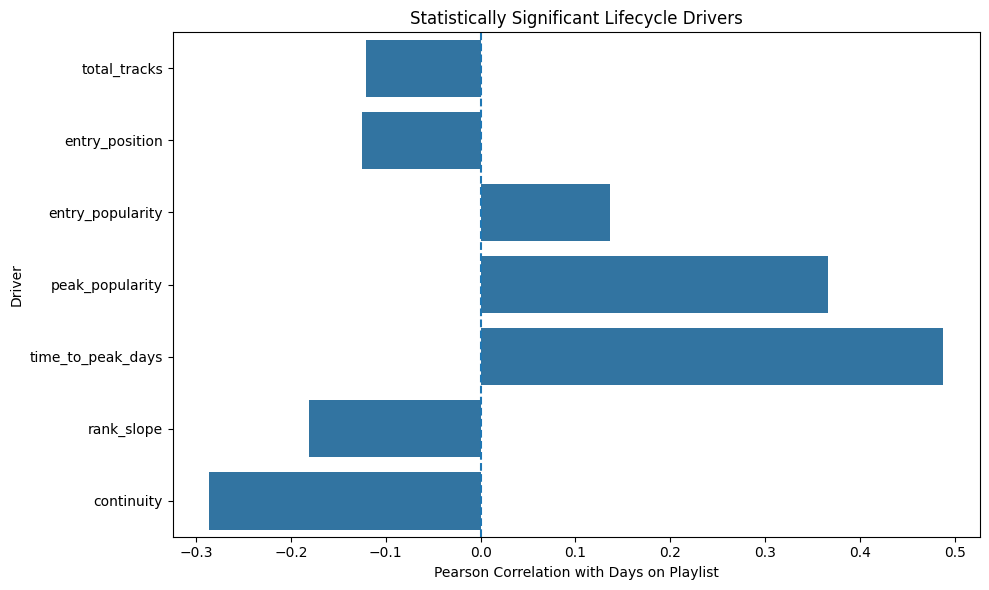

In [229]:
# VISUALIZE SIGNIFICANT DRIVERS

significant_drivers = correlation_summary[
    correlation_summary["P_Value"] < 0.05
].copy()


print("\nSignificant Drivers:")
print(significant_drivers)


if len(significant_drivers) > 0:

    plt.figure(figsize=(10, 6))

    sns.barplot(
        data=significant_drivers,
        x="Correlation",
        y="Variable"
    )

    plt.axvline(
        0,
        linestyle="--"
    )

    plt.title(
        "Statistically Significant Lifecycle Drivers"
    )

    plt.xlabel(
        "Pearson Correlation with Days on Playlist"
    )

    plt.ylabel(
        "Driver"
    )

    plt.tight_layout()

    plt.show()

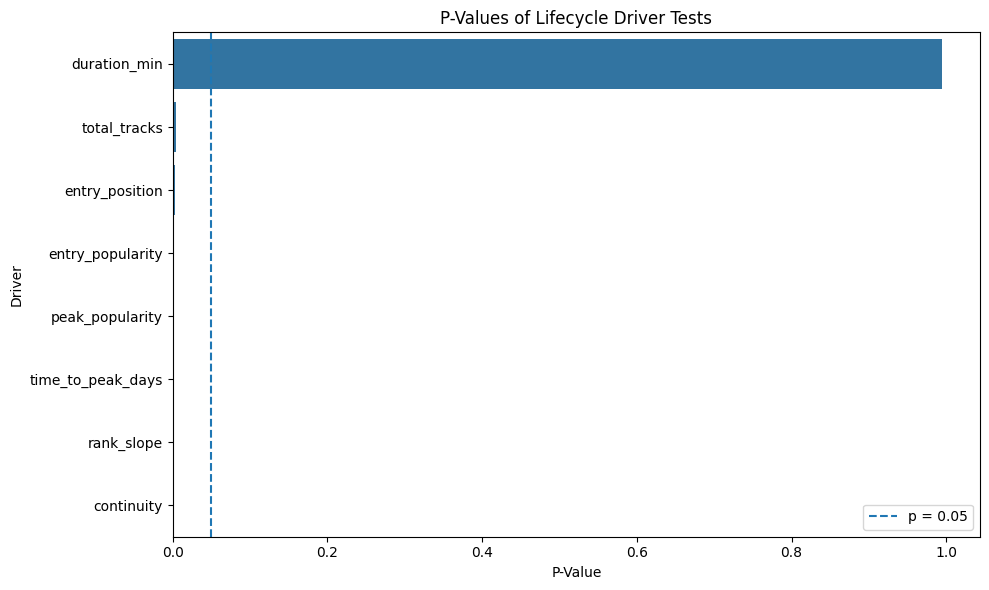

In [230]:
# P-VALUE VISUALIZATION

if len(correlation_summary) > 0:

    plot_data = correlation_summary.copy()

    plot_data["Significant"] = (
        plot_data["P_Value"] < 0.05
    )

    plt.figure(figsize=(10, 6))

    sns.barplot(
        data=plot_data,
        x="P_Value",
        y="Variable"
    )

    plt.axvline(
        0.05,
        linestyle="--",
        label="p = 0.05"
    )

    plt.title(
        "P-Values of Lifecycle Driver Tests"
    )

    plt.xlabel("P-Value")
    plt.ylabel("Driver")

    plt.legend()

    plt.tight_layout()

    plt.show()

In [231]:
# MULTIPLE TESTING CORRECTION

print("\n================================================")
print("MULTIPLE TESTING CORRECTION")
print("================================================")


# Bonferroni correction

if len(correlation_summary) > 0:

    n_tests = len(correlation_summary)

    alpha = 0.05

    bonferroni_alpha = (
        alpha / n_tests
    )

    correlation_summary[
        "Bonferroni_Significant"
    ] = (
        correlation_summary["P_Value"]
        < bonferroni_alpha
    )

    print(
        "Number of Tests:",
        n_tests
    )

    print(
        "Original Alpha:",
        alpha
    )

    print(
        "Bonferroni Alpha:",
        bonferroni_alpha
    )

    print(
        "\nCorrected Results:"
    )

    print(
        correlation_summary[          
        [
                "Variable",
                "P_Value",
                "Bonferroni_Significant"
            ]
        ]
    )



MULTIPLE TESTING CORRECTION
Number of Tests: 8
Original Alpha: 0.05
Bonferroni Alpha: 0.00625

Corrected Results:
            Variable       P_Value  Bonferroni_Significant
0       duration_min  9.938082e-01                   False
1       total_tracks  3.722690e-03                    True
2     entry_position  2.771453e-03                    True
3   entry_popularity  9.960685e-04                    True
4    peak_popularity  1.081131e-19                    True
5  time_to_peak_days  9.895138e-36                    True
6         rank_slope  1.337718e-05                    True
7         continuity  2.746153e-12                    True


In [232]:
# CONFIDENCE INTERVAL FOR EXPLICIT-CLEAN DIFFERENCE

print("\n================================================")
print("95% CONFIDENCE INTERVAL")
print("EXPLICIT VS CLEAN")
print("================================================")


mean_difference = (
    explicit.mean() -
    clean.mean()
)


se = np.sqrt(
    explicit.var(ddof=1) / len(explicit)
    +
    clean.var(ddof=1) / len(clean)
)


degrees_freedom = (

    (
        explicit.var(ddof=1) / len(explicit)
        +
        clean.var(ddof=1) / len(clean)
    ) ** 2

    /

    (
        (
            explicit.var(ddof=1)
            / len(explicit)
        ) ** 2
        /
        (len(explicit) - 1)

        +

        (
            clean.var(ddof=1)
            / len(clean)
        ) ** 2
        /
        (len(clean) - 1)
    )
)


critical_value = stats.t.ppf(
    0.975,
    degrees_freedom
)

margin_error = (
    critical_value * se
)


ci_lower = (
    mean_difference -
    margin_error
)


ci_upper = (
    mean_difference +
    margin_error
)


print(
    "Mean Difference:",
    mean_difference
)

print(
    "95% CI Lower:",
    ci_lower
)

print(
    "95% CI Upper:",
    ci_upper
)


95% CONFIDENCE INTERVAL
EXPLICIT VS CLEAN
Mean Difference: -5.592923076923078
95% CI Lower: -20.43695983614583
95% CI Upper: 9.251113682299676


In [233]:
# STATISTICAL TEST SUMMARY

statistical_summary = pd.DataFrame({

    "Test": [

        "Explicit vs Clean - Welch T-Test",

        "Explicit vs Clean - Mann Whitney",

        "Lifecycle Stage - ANOVA",

        "Lifecycle Stage - Kruskal Wallis",

        "Explicit vs Lifecycle Stage - Chi Square",

        "Album Type vs Lifecycle Stage - Chi Square"
    ],

    "P_Value": [

        t_p,

        u_p,

        f_oneway(
            *stage_groups
        )[1]
        if len(stage_groups) >= 2
        else np.nan,

        kruskal(
            *stage_groups
        )[1]
        if len(stage_groups) >= 2
        else np.nan,

        chi2_contingency(
            contingency_table
        )[1]
        if contingency_table.shape[0] >= 2
        and contingency_table.shape[1] >= 2
        else np.nan,

        chi2_contingency(
            album_stage_table
        )[1]
        if album_stage_table.shape[0] >= 2
        and album_stage_table.shape[1] >= 2
        else np.nan
    ]
})


statistical_summary[
    "Significance"
] = statistical_summary[
    "P_Value"
].apply(
    lambda x:
        significance_label(x)
        if pd.notna(x)
        else "Not Available"
)


print("\n================================================")
print("STATISTICAL TEST SUMMARY")
print("================================================")

print(statistical_summary)


STATISTICAL TEST SUMMARY
                                         Test       P_Value  \
0            Explicit vs Clean - Welch T-Test  4.595408e-01   
1            Explicit vs Clean - Mann Whitney  2.039689e-01   
2                     Lifecycle Stage - ANOVA  2.427134e-70   
3            Lifecycle Stage - Kruskal Wallis  6.994475e-99   
4    Explicit vs Lifecycle Stage - Chi Square  5.478634e-01   
5  Album Type vs Lifecycle Stage - Chi Square  6.265652e-07   

         Significance  
0     Not Significant  
1     Not Significant  
2  Highly Significant  
3  Highly Significant  
4     Not Significant  
5  Highly Significant  


In [234]:
# FINAL DRIVER VALIDATION TABLE

final_validation = correlation_summary.copy()

final_validation["Business_Interpretation"] = ""


for index, row in final_validation.iterrows():

    variable = row["Variable"]
    correlation = row["Correlation"]
    p_value = row["P_Value"]

    if p_value < 0.05:

        if correlation > 0:

            interpretation = (
                f"{variable} shows a positive "
                "association with playlist longevity."
            )

        else:

            interpretation = (
                f"{variable} shows a negative "
                "association with playlist longevity."
            )

    else:

        interpretation = (
            f"No statistically significant "
            f"relationship detected for {variable}."
        )

    final_validation.loc[
        index,
        "Business_Interpretation"
    ] = interpretation


print("\n================================================")
print("FINAL DRIVER VALIDATION")
print("================================================")

print(final_validation)


FINAL DRIVER VALIDATION
            Variable  Correlation       P_Value        Significance  \
0       duration_min     0.000324  9.938082e-01     Not Significant   
1       total_tracks    -0.120789  3.722690e-03    Very Significant   
2     entry_position    -0.124560  2.771453e-03    Very Significant   
3   entry_popularity     0.136922  9.960685e-04  Highly Significant   
4    peak_popularity     0.366242  1.081131e-19  Highly Significant   
5  time_to_peak_days     0.487957  9.895138e-36  Highly Significant   
6         rank_slope    -0.180468  1.337718e-05  Highly Significant   
7         continuity    -0.286020  2.746153e-12  Highly Significant   

  Effect_Strength  Spearman_Rho  Bonferroni_Significant  \
0       Very Weak      0.083958                   False   
1            Weak     -0.253849                    True   
2            Weak     -0.148794                    True   
3            Weak      0.254307                    True   
4        Moderate      0.649160         

In [235]:
# EXPORT RESULTS

pearson_results.to_csv(
    "Spain_Top50_Pearson_Correlation_Tests.csv",
    index=False
)

spearman_results.to_csv(
    "Spain_Top50_Spearman_Correlation_Tests.csv",
    index=False
)

explicit_clean_tests.to_csv(
    "Spain_Top50_Explicit_Clean_Statistical_Tests.csv",
    index=False
)

album_test_results.to_csv(
    "Spain_Top50_Album_Type_Statistical_Test.csv",
    index=False
)

correlation_summary.to_csv(
    "Spain_Top50_Correlation_Significance_Summary.csv",
    index=False
)

statistical_summary.to_csv(
    "Spain_Top50_Statistical_Test_Summary.csv",
    index=False
)

final_validation.to_csv(
    "Spain_Top50_Final_Driver_Validation.csv",
    index=False
)

contingency_table.to_csv(
    "Spain_Top50_Explicit_Lifecycle_Contingency.csv"
)

album_stage_table.to_csv(
    "Spain_Top50_Album_Lifecycle_Contingency.csv"
)

In [236]:
# FINAL MESSAGE

print("\n================================================")
print("COMPLETED SUCCESSFULLY")
print("================================================")

print("""
Statistical validation completed.

Tests performed:
1. Pearson Correlation
2. Spearman Correlation
3. Welch's T-Test
4. Mann-Whitney U Test
5. One-Way ANOVA
6. Kruskal-Wallis Test
7. Chi-Square Test
8. Bonferroni Correction
9. 95% Confidence Interval

All statistical results have been exported.
""")


COMPLETED SUCCESSFULLY

Statistical validation completed.

Tests performed:
1. Pearson Correlation
2. Spearman Correlation
3. Welch's T-Test
4. Mann-Whitney U Test
5. One-Way ANOVA
6. Kruskal-Wallis Test
7. Chi-Square Test
8. Bonferroni Correction
9. 95% Confidence Interval

All statistical results have been exported.



In [237]:
# Test	                            Purpose
# Pearson Correlation	           Linear relationship check
# Spearman Correlation	           Monotonic relationship check
# Welch's T-Test	               Explicit vs Clean mean comparison
# Mann-Whitney U	               Non-parametric Explicit vs Clean comparison
# ANOVA	                           Multiple lifecycle groups comparison
# Kruskal-Wallis	               Non-parametric multiple-group comparison
# Chi-Square	                   Lifecycle stage vs Explicit/Album type
# Bonferroni Correction	           Multiple testing control
# 95% CI	                       Difference ki uncertainty range

# Predictive Modeling & Lifecycle Prediction:

In [238]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import joblib

In [239]:
# CREATE MODELING DATASET

model_df = lifecycle.copy()

print("Dataset Shape:", model_df.shape)

display(model_df.head())

print("\nAvailable Columns:")
print(model_df.columns.tolist())

Dataset Shape: (575, 34)


,track_key,song,artist,entry_date,exit_date,entry_position,best_position,exit_position,observations,entry_popularity,peak_popularity,exit_popularity,album_type,total_tracks,is_explicit,duration_min,calendar_days,days_on_playlist,continuity,continuity_percentage,peak_date,peak_position_check,time_to_peak_days,rank_slope,popularity_slope,rank_improvement,rank_change_entry_to_exit,rank_movement,popularity_change,popularity_growth_percentage,lifecycle_stage,retention_stability_index,entry_age_days,content_maturity
0,0 confianza | rvfv,0 CONFIANZA,Rvfv,2025-06-02,2025-06-23,40,23,42,20,35,62,62,album,20,False,3.625000,22,22,0.909091,90.909091,2025-06-07,23,5,0.388722,0.584211,17,2,Stable,27,77.142857,Mature Phase,65.46,380,Established
1,"1 de enero, puntacana | rels b","1 de Enero, Puntacana",Rels B,2025-04-28,2025-04-28,45,45,45,1,65,65,65,album,13,False,1.583333,1,1,1.000000,100.000000,2025-04-28,45,0,0.000000,0.000000,0,0,Stable,0,0.000000,New Entry,100.00,345,Established
2,1000cosas | lola indigo & manuel turizo,1000COSAS,Lola Indigo & Manuel Turizo,2025-03-10,2025-11-13,3,3,44,245,65,81,72,single,1,False,3.991367,249,249,0.983936,98.393574,2025-03-10,3,0,0.121004,-0.027498,0,41,Stable,7,10.769231,Peak Phase,87.77,296,Established
3,100xciento | foreign teck & eladio carrion & d...,100xCiento,Foreign Teck & Eladio Carrion & De La Ghetto,2025-04-30,2025-05-15,42,13,37,11,72,75,75,single,1,True,3.661367,16,16,0.687500,68.750000,2025-05-11,13,11,-0.963636,0.345455,29,-5,Improving,3,4.166667,Growth Phase,35.01,347,Established
4,14 febreros | quevedo,14 FEBREROS,Quevedo,2025-11-24,2025-11-27,9,9,16,4,63,68,68,album,18,True,2.873700,4,4,1.000000,100.000000,2025-11-24,9,0,2.400000,1.700000,0,7,Declining,5,7.936508,New Entry,29.41,555,Established



Available Columns:
['track_key', 'song', 'artist', 'entry_date', 'exit_date', 'entry_position', 'best_position', 'exit_position', 'observations', 'entry_popularity', 'peak_popularity', 'exit_popularity', 'album_type', 'total_tracks', 'is_explicit', 'duration_min', 'calendar_days', 'days_on_playlist', 'continuity', 'continuity_percentage', 'peak_date', 'peak_position_check', 'time_to_peak_days', 'rank_slope', 'popularity_slope', 'rank_improvement', 'rank_change_entry_to_exit', 'rank_movement', 'popularity_change', 'popularity_growth_percentage', 'lifecycle_stage', 'retention_stability_index', 'entry_age_days', 'content_maturity']


In [240]:
# Define Target Variable

target = "days_on_playlist"

print("Target Variable:", target)

print("\nTarget Statistics:")
display(
    model_df[target].describe()
)

Target Variable: days_on_playlist

Target Statistics:


count    575.000000
mean      57.445217
std       89.966777
min        1.000000
25%        4.000000
50%       15.000000
75%       82.500000
max      551.000000
Name: days_on_playlist, dtype: float64

In [241]:
# Create Predictive Features (Yeh early/entry-level information use karega)

predictive_features = [
    
    "entry_position",
    
    "entry_popularity",
    
    "duration_min",
    
    "total_tracks",
    
    "is_explicit",
    
    "album_type"
]

# Check available features
available_features = [
    col for col in predictive_features
    if col in model_df.columns
]

missing_features = [
    col for col in predictive_features
    if col not in model_df.columns
]

print("Available Features:")
print(available_features)

print("\nMissing Features:")
print(missing_features)

Available Features:
['entry_position', 'entry_popularity', 'duration_min', 'total_tracks', 'is_explicit', 'album_type']

Missing Features:
[]


In [242]:
# Prepare X and y

X = model_df[available_features].copy()

y = model_df[target].copy()

print("X Shape:", X.shape)
print("y Shape:", y.shape)

print("\nFeature Data Types:")
print(X.dtypes)

X Shape: (575, 6)
y Shape: (575,)

Feature Data Types:
entry_position        int64
entry_popularity      int64
duration_min        float64
total_tracks          int64
is_explicit            bool
album_type           object
dtype: object


In [243]:
# Handle Boolean Values

if "is_explicit" in X.columns:
    
    X["is_explicit"] = (
        X["is_explicit"]
        .astype(str)
    )

print(X.head())

   entry_position  entry_popularity  duration_min  total_tracks is_explicit  \
0              40                35      3.625000            20       False   
1              45                65      1.583333            13       False   
2               3                65      3.991367             1       False   
3              42                72      3.661367             1        True   
4               9                63      2.873700            18        True   

  album_type  
0      album  
1      album  
2     single  
3     single  
4      album  


In [244]:
# Identify Numerical & Categorical Columns

numerical_features = X.select_dtypes(
    include=[
        "int64",
        "float64",
        "int32",
        "float32"
    ]
).columns.tolist()


categorical_features = [
    col for col in X.columns
    if col not in numerical_features
]

print("Numerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
['entry_position', 'entry_popularity', 'duration_min', 'total_tracks']

Categorical Features:
['is_explicit', 'album_type']


In [246]:
# Create Preprocessing Pipeline

numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        )
    ]
)


categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)


preprocessor = ColumnTransformer(
    transformers=[
        
        (
            "num",
            numeric_transformer,
            numerical_features
        ),
        
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

In [247]:
# Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    
    X,
    y,
    
    test_size=0.20,
    
    random_state=42
)


print("Training Data:", X_train.shape)

print("Testing Data:", X_test.shape)

Training Data: (460, 6)
Testing Data: (115, 6)


In [248]:
# Linear Regression Baseline

linear_model = Pipeline(
    steps=[
        
        (
            "preprocessor",
            preprocessor
        ),
        
        (
            "model",
            LinearRegression()
        )
    ]
)


# Train model

linear_model.fit(
    X_train,
    y_train
)


# Predictions

linear_predictions = linear_model.predict(
    X_test
)


print("Linear Regression Model Trained Successfully!")

Linear Regression Model Trained Successfully!


In [249]:
# Evaluate Linear Regression

linear_mae = mean_absolute_error(
    y_test,
    linear_predictions
)


linear_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        linear_predictions
    )
)


linear_r2 = r2_score(
    y_test,
    linear_predictions
)


print("===================================")
print("LINEAR REGRESSION PERFORMANCE")
print("===================================")

print("MAE:", round(linear_mae, 3))

print("RMSE:", round(linear_rmse, 3))

print("R² Score:", round(linear_r2, 3))

LINEAR REGRESSION PERFORMANCE
MAE: 73.502
RMSE: 116.373
R² Score: -0.002


In [250]:
# Random Forest Model

random_forest_model = Pipeline(
    steps=[
        
        (
            "preprocessor",
            preprocessor
        ),
        
        (
            "model",
            RandomForestRegressor(
                
                n_estimators=300,
                
                max_depth=15,
                
                min_samples_split=5,
                
                min_samples_leaf=2,
                
                random_state=42,
                
                n_jobs=-1
            )
        )
    ]
)


# Train Model

random_forest_model.fit(
      X_train,
    y_train
)


# Predictions

rf_predictions = random_forest_model.predict(
    X_test
)


print("Random Forest Model Trained Successfully!")

Random Forest Model Trained Successfully!


In [251]:
# Evaluate Random Forest

rf_mae = mean_absolute_error(
    y_test,
    rf_predictions
)


rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_predictions
    )
)


rf_r2 = r2_score(
    y_test,
    rf_predictions
)


print("===================================")
print("RANDOM FOREST PERFORMANCE")
print("===================================")

print("MAE:", round(rf_mae, 3))

print("RMSE:", round(rf_rmse, 3))

print("R² Score:", round(rf_r2, 3))

RANDOM FOREST PERFORMANCE
MAE: 75.113
RMSE: 116.032
R² Score: 0.004


In [252]:
# MODEL COMPARISON

model_comparison = pd.DataFrame({

    "Model": [
        "Linear Regression",
        "Random Forest"
    ],

    "MAE": [
        linear_mae,
        rf_mae
    ],

    "RMSE": [
        linear_rmse,
        rf_rmse
    ],

    "R2_Score": [
        linear_r2,
        rf_r2
    ]
})


model_comparison = model_comparison.round(3)

display(model_comparison)

,Model,MAE,RMSE,R2_Score
0,Linear Regression,73.502,116.373,-0.002
1,Random Forest,75.113,116.032,0.004


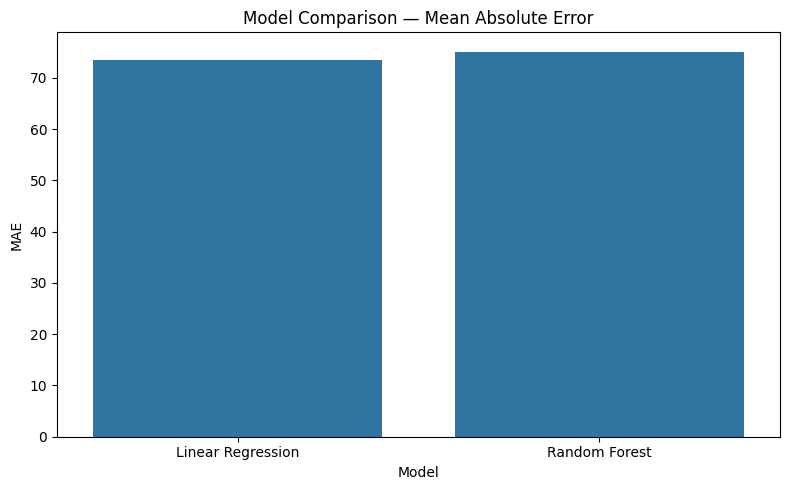

In [253]:
# MODEL COMPARISON VISUALIZATION

plt.figure(figsize=(8, 5))

sns.barplot(
    data=model_comparison,
    x="Model",
    y="MAE"
)

plt.title("Model Comparison — Mean Absolute Error")

plt.ylabel("MAE")

plt.tight_layout()

plt.show()

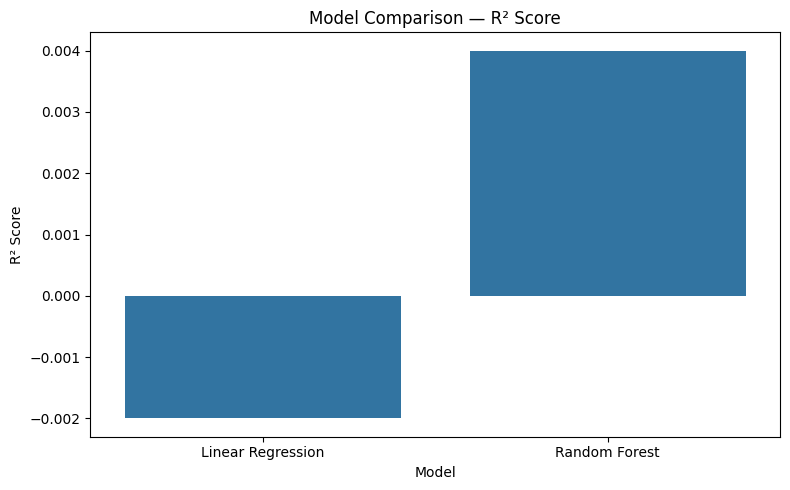

In [254]:
# R² Comparison
plt.figure(figsize=(8, 5))

sns.barplot(
    data=model_comparison,
    x="Model",
    y="R2_Score"
)

plt.title("Model Comparison — R² Score")

plt.ylabel("R² Score")

plt.tight_layout()

plt.show()

# The predictive modeling results indicate that both Linear Regression and Random Forest demonstrated poor performance in predicting playlist longevity. 
# Linear Regression achieved a slightly lower MAE, while Random Forest produced a marginally positive R² score. However, both R² values were close to zero, 
# indicating that the selected features were insufficient to explain the variation in days on playlist. Therefore, the results suggest that playlist longevity 
# may depend on additional factors not captured in the current dataset

In [255]:
# SELECT BEST MODEL

best_model_name = model_comparison.loc[
    model_comparison["MAE"].idxmin(),
    "Model"
]


if best_model_name == "Linear Regression":
    
    best_model = linear_model
    best_predictions = linear_predictions

else:
    
    best_model = random_forest_model
    best_predictions = rf_predictions


print("Best Model:", best_model_name)

# Lower MAE = Better Model

Best Model: Linear Regression


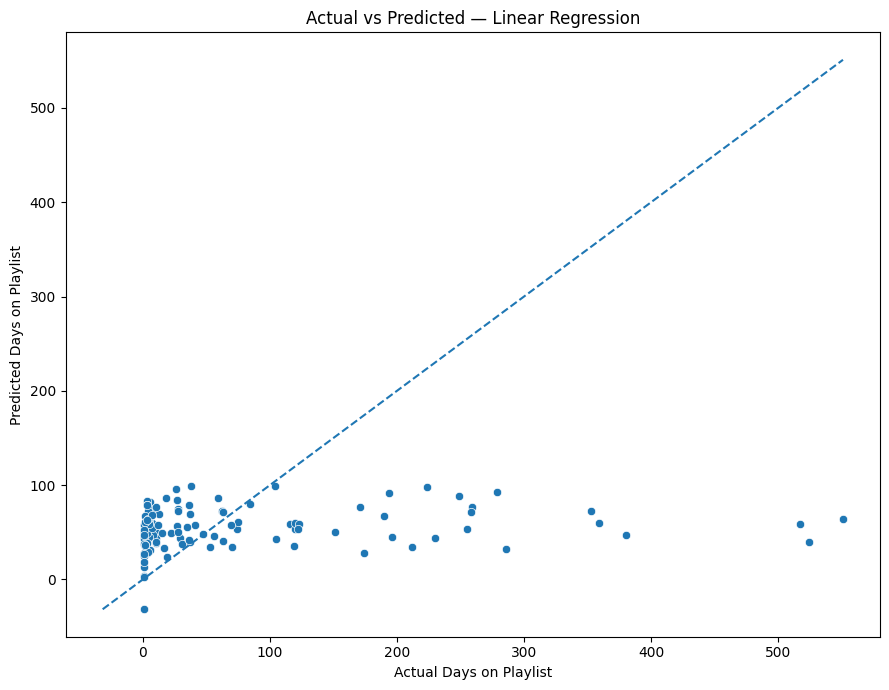

In [256]:
# # ACTUAL VS PREDICTED

plt.figure(figsize=(9, 7))

sns.scatterplot(
    x=y_test,
    y=best_predictions
)


min_value = min(
    y_test.min(),
    best_predictions.min()
)

max_value = max(
    y_test.max(),
    best_predictions.max()
)


plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)


plt.title(
    f"Actual vs Predicted — {best_model_name}"
)

plt.xlabel("Actual Days on Playlist")

plt.ylabel("Predicted Days on Playlist")

plt.tight_layout()

plt.show()

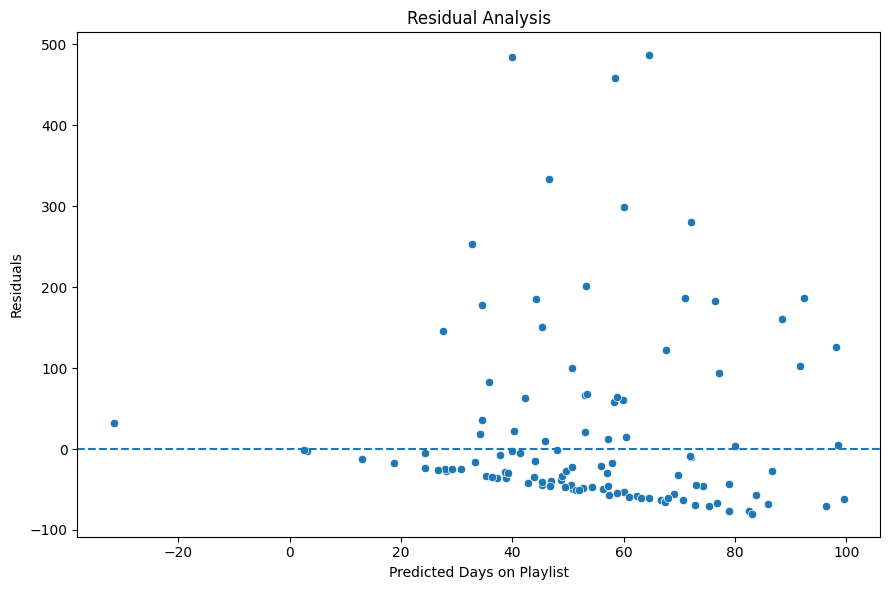

In [257]:
# RESIDUAL ANALYSIS (purpose check karna hai ki best model ki prediction errors ka pattern kaisa hai)

residuals = (
    y_test.values -
    best_predictions
)


plt.figure(figsize=(9, 6))

sns.scatterplot(
    x=best_predictions,
    y=residuals
)


plt.axhline(
    0,
    linestyle="--"
)


plt.title(
    "Residual Analysis"
)

plt.xlabel(
    "Predicted Days on Playlist"
)

plt.ylabel(
    "Residuals"
)

plt.tight_layout()

plt.show()

# Model average songs ko predict kar raha hai, but very successful long-lasting songs ko predict nahi kar paa raha.
# This also explains why your R² score is almost zero despite some variables showing meaningful correlations with longevity

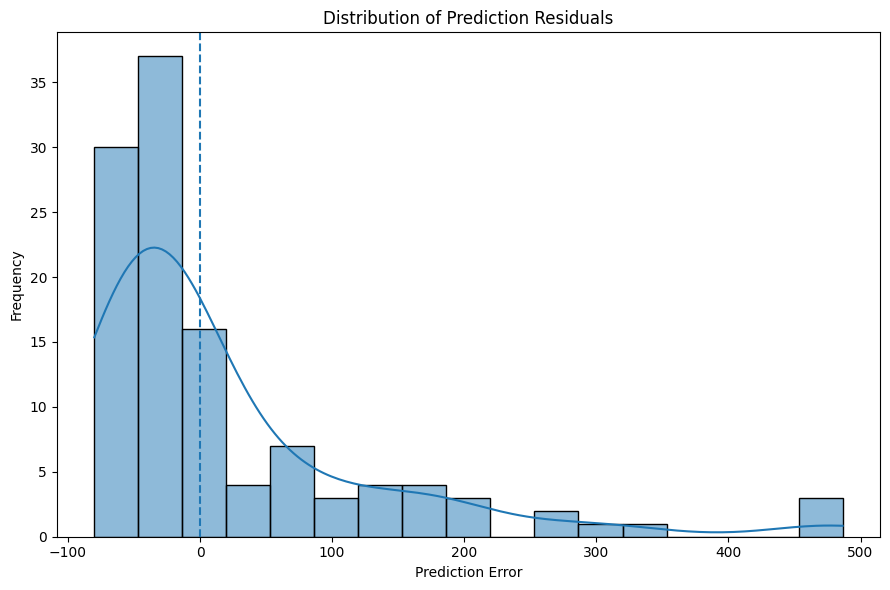

In [258]:
# RESIDUAL DISTRIBUTION

plt.figure(figsize=(9, 6))

sns.histplot(
    residuals,
    kde=True
)

plt.axvline(
    0,
    linestyle="--"
)


plt.title(
    "Distribution of Prediction Residuals"
)

plt.xlabel(
    "Prediction Error"
)

plt.ylabel(
    "Frequency"
)

plt.tight_layout()

plt.show()

In [259]:
# RANDOM FOREST FEATURE IMPORTANCE

rf_preprocessor = (
    random_forest_model.named_steps[
        "preprocessor"
    ]
)


rf_model = (
    random_forest_model.named_steps[
        "model"
    ]
)


# Get transformed feature names

feature_names = (
    rf_preprocessor
    .get_feature_names_out()
)


feature_importance = pd.DataFrame({

    "Feature": feature_names,

    "Importance":
        rf_model.feature_importances_

})


feature_importance = (
    feature_importance
    .sort_values(
        "Importance",
        ascending=False
    )
)


display(feature_importance)

,Feature,Importance
0,num__entry_position,0.304070
1,num__entry_popularity,0.302777
2,num__duration_min,0.240882
3,num__total_tracks,0.122650
4,cat__is_explicit_False,0.010383
5,cat__is_explicit_True,0.009064
7,cat__album_type_single,0.005693
6,cat__album_type_album,0.004481


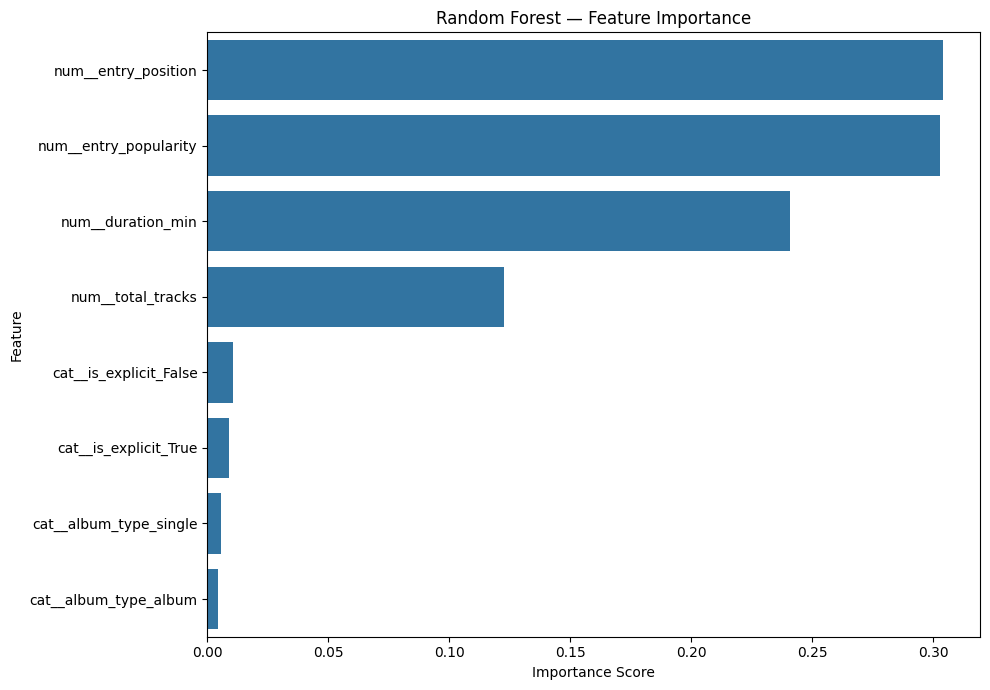

In [260]:
# Feature Importance Visualization

plt.figure(figsize=(10, 7))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title(
    "Random Forest — Feature Importance"
)

plt.xlabel("Importance Score")

plt.ylabel("Feature")

plt.tight_layout()

plt.show()

In [261]:
# TOP FEATURE DRIVERS

top_drivers = (
    feature_importance
    .head(10)
    .reset_index(drop=True)
)


print("===================================")
print("TOP LIFECYCLE PREDICTION DRIVERS")
print("===================================")

display(top_drivers)

TOP LIFECYCLE PREDICTION DRIVERS


,Feature,Importance
0,num__entry_position,0.304070
1,num__entry_popularity,0.302777
2,num__duration_min,0.240882
3,num__total_tracks,0.122650
4,cat__is_explicit_False,0.010383
5,cat__is_explicit_True,0.009064
6,cat__album_type_single,0.005693
7,cat__album_type_album,0.004481


In [262]:
# SONG LIFECYCLE PREDICTION FUNCTION (Ab hum future songs ke liye prediction function bana sakte hain)

def predict_playlist_days(
    
    entry_position,
    
    entry_popularity,
    
    duration_min,
    
    total_tracks,
    
    is_explicit,
    
    album_type
):
    
    new_song = pd.DataFrame({
        
        "entry_position": [
            entry_position
        ],
        
        "entry_popularity": [
            entry_popularity
        ],
        
        "duration_min": [
            duration_min
        ],
        
        "total_tracks": [
            total_tracks
        ],
        
        "is_explicit": [
            str(is_explicit)
        ],
        
        "album_type": [
            album_type
        ]
    })
    
    
    prediction = best_model.predict(
        new_song
    )
    
    
    return round(
        prediction[0],
        2
    )

In [263]:
# TEST PREDICTION

predicted_days = predict_playlist_days(

    entry_position=25,

    entry_popularity=70,

    duration_min=3.2,

    total_tracks=1,

    is_explicit=True,

    album_type="single"
)


print(
    "Predicted Days on Spain Top 50:",
    predicted_days
)

# According to our best selected model (Linear Regression): A song with these characteristics is predicted to remain on the Spain Top 50 playlist 
# for approximately 77 days
# Since our model's R² score was approximately zero and residual analysis showed large errors, treat 76.99 days as an experimental estimate, 
# not a highly reliable prediction

Predicted Days on Spain Top 50: 76.99


In [264]:
# Lifecycle Prediction Categories

def classify_predicted_lifecycle(days):

    q25 = lifecycle[
        "days_on_playlist"
    ].quantile(0.25)

    q50 = lifecycle[
        "days_on_playlist"
    ].quantile(0.50)

    q75 = lifecycle[
        "days_on_playlist"
    ].quantile(0.75)


    if days <= q25:
        return "Short Lifecycle"

    elif days <= q50:
        return "Moderate Lifecycle"

    elif days <= q75:
        return "Long Lifecycle"

    else:
        return "High Retention"

In [265]:
# Example Lifecycle Prediction

predicted_category = (
    classify_predicted_lifecycle(
        predicted_days
    )
)


print(
    "Predicted Days:",
    predicted_days
)

print(
    "Predicted Lifecycle Category:",
    predicted_category
)

Predicted Days: 76.99
Predicted Lifecycle Category: Long Lifecycle


In [266]:
# SAVE BEST MODEL

model_filename = (
    "Spain_Top50_Lifecycle_Prediction_Model.pkl"
)


joblib.dump(
    best_model,
    model_filename
)


print(
    f"Model saved successfully as: {model_filename}"
)

Model saved successfully as: Spain_Top50_Lifecycle_Prediction_Model.pkl


In [268]:
# Save Model Comparison & Feature Importance

# EXPORT MODEL RESULTS
model_comparison.to_csv(
    "Spain_Top50_Model_Comparison.csv",
    index=False
)


feature_importance.to_csv(
    "Spain_Top50_Feature_Importance.csv",
    index=False
)


top_drivers.to_csv(
    "Spain_Top50_Top_Lifecycle_Drivers.csv",
    index=False
)


# Prediction results

prediction_results = pd.DataFrame({

    "Metric": [
        "Best Model",
        "Predicted Days",
        "Predicted Lifecycle Category"
    ],

    "Value": [
        best_model_name,
        predicted_days,
        predicted_category
    ]
})


prediction_results.to_csv(
    "Spain_Top50_Example_Prediction.csv",
    index=False
)


print("All results exported successfully!")

All results exported successfully!


In [269]:
# Final Model Performance Summary

print("==============================================")
print("MODULE 10 — FINAL MODEL PERFORMANCE SUMMARY")
print("==============================================")

print("\nBest Model:")
print(best_model_name)

print("\nModel Performance:")
display(
    model_comparison
)

print("\nTop Lifecycle Prediction Drivers:")
display(
    top_drivers
)

print("\nExample Prediction:")
display(
    prediction_results
)

print("""
==============================================
MODULE 10 COMPLETED SUCCESSFULLY
==============================================

The predictive modeling system can now:

 Predict playlist longevity
 Compare Linear Regression vs Random Forest
 Identify important lifecycle drivers
 Analyze prediction errors
 Classify predicted lifecycle
 Generate predictions for new songs
 Save the best model for Streamlit deployment
""")

MODULE 10 — FINAL MODEL PERFORMANCE SUMMARY

Best Model:
Linear Regression

Model Performance:


,Model,MAE,RMSE,R2_Score
0,Linear Regression,73.502,116.373,-0.002
1,Random Forest,75.113,116.032,0.004



Top Lifecycle Prediction Drivers:


,Feature,Importance
0,num__entry_position,0.304070
1,num__entry_popularity,0.302777
2,num__duration_min,0.240882
3,num__total_tracks,0.122650
4,cat__is_explicit_False,0.010383
5,cat__is_explicit_True,0.009064
6,cat__album_type_single,0.005693
7,cat__album_type_album,0.004481



Example Prediction:


,Metric,Value
0,Best Model,Linear Regression
1,Predicted Days,76.99
2,Predicted Lifecycle Category,Long Lifecycle



MODULE 10 COMPLETED SUCCESSFULLY

The predictive modeling system can now:

 Predict playlist longevity
 Compare Linear Regression vs Random Forest
 Identify important lifecycle drivers
 Analyze prediction errors
 Classify predicted lifecycle
 Generate predictions for new songs
 Save the best model for Streamlit deployment



# Advanced Business Insights & Strategic Recommendations:

In [270]:
# Import Libraries & Create Business Dataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

# Create business analysis dataset
business_df = lifecycle.copy()

print("Dataset Shape:", business_df.shape)

print("\nAvailable Columns:")
print(business_df.columns.tolist())

display(business_df.head())

Dataset Shape: (575, 34)

Available Columns:
['track_key', 'song', 'artist', 'entry_date', 'exit_date', 'entry_position', 'best_position', 'exit_position', 'observations', 'entry_popularity', 'peak_popularity', 'exit_popularity', 'album_type', 'total_tracks', 'is_explicit', 'duration_min', 'calendar_days', 'days_on_playlist', 'continuity', 'continuity_percentage', 'peak_date', 'peak_position_check', 'time_to_peak_days', 'rank_slope', 'popularity_slope', 'rank_improvement', 'rank_change_entry_to_exit', 'rank_movement', 'popularity_change', 'popularity_growth_percentage', 'lifecycle_stage', 'retention_stability_index', 'entry_age_days', 'content_maturity']


,track_key,song,artist,entry_date,exit_date,entry_position,best_position,exit_position,observations,entry_popularity,peak_popularity,exit_popularity,album_type,total_tracks,is_explicit,duration_min,calendar_days,days_on_playlist,continuity,continuity_percentage,peak_date,peak_position_check,time_to_peak_days,rank_slope,popularity_slope,rank_improvement,rank_change_entry_to_exit,rank_movement,popularity_change,popularity_growth_percentage,lifecycle_stage,retention_stability_index,entry_age_days,content_maturity
0,0 confianza | rvfv,0 CONFIANZA,Rvfv,2025-06-02,2025-06-23,40,23,42,20,35,62,62,album,20,False,3.625000,22,22,0.909091,90.909091,2025-06-07,23,5,0.388722,0.584211,17,2,Stable,27,77.142857,Mature Phase,65.46,380,Established
1,"1 de enero, puntacana | rels b","1 de Enero, Puntacana",Rels B,2025-04-28,2025-04-28,45,45,45,1,65,65,65,album,13,False,1.583333,1,1,1.000000,100.000000,2025-04-28,45,0,0.000000,0.000000,0,0,Stable,0,0.000000,New Entry,100.00,345,Established
2,1000cosas | lola indigo & manuel turizo,1000COSAS,Lola Indigo & Manuel Turizo,2025-03-10,2025-11-13,3,3,44,245,65,81,72,single,1,False,3.991367,249,249,0.983936,98.393574,2025-03-10,3,0,0.121004,-0.027498,0,41,Stable,7,10.769231,Peak Phase,87.77,296,Established
3,100xciento | foreign teck & eladio carrion & d...,100xCiento,Foreign Teck & Eladio Carrion & De La Ghetto,2025-04-30,2025-05-15,42,13,37,11,72,75,75,single,1,True,3.661367,16,16,0.687500,68.750000,2025-05-11,13,11,-0.963636,0.345455,29,-5,Improving,3,4.166667,Growth Phase,35.01,347,Established
4,14 febreros | quevedo,14 FEBREROS,Quevedo,2025-11-24,2025-11-27,9,9,16,4,63,68,68,album,18,True,2.873700,4,4,1.000000,100.000000,2025-11-24,9,0,2.400000,1.700000,0,7,Declining,5,7.936508,New Entry,29.41,555,Established


In [271]:
# Overall Spain Top 50 Business KPIs

overall_kpis = {

    "Total Unique Songs": len(business_df),

    "Average Days on Playlist":
        business_df["days_on_playlist"].mean(),

    "Median Days on Playlist":
        business_df["days_on_playlist"].median(),

    "Average Best Position":
        business_df["best_position"].mean(),

    "Average Entry Position":
        business_df["entry_position"].mean(),

    "Average Time to Peak":
        business_df["time_to_peak_days"].mean(),

    "Average Retention Stability":
        business_df["retention_stability_index"].mean(),

    "Average Continuity":
        business_df["continuity"].mean()
}


overall_kpi_df = pd.DataFrame(
    overall_kpis.items(),
    columns=["KPI", "Value"]
)

overall_kpi_df["Value"] = (
    overall_kpi_df["Value"].round(2)
)

display(overall_kpi_df)

,KPI,Value
0,Total Unique Songs,575.00
1,Average Days on Playlist,57.45
2,Median Days on Playlist,15.00
3,Average Best Position,21.79
4,Average Entry Position,30.14
5,Average Time to Peak,9.49
6,Average Retention Stability,60.05
7,Average Continuity,0.92


In [272]:
# Create Content Retention Segments (Songs ko business perspective se 4 groups mein divide karenge)
# Iska purpose songs ko unke days_on_playlist ke basis par different retention categories mein divide karna hai

q25 = business_df[
    "days_on_playlist"
].quantile(0.25)

q50 = business_df[
    "days_on_playlist"
].quantile(0.50)

q75 = business_df[
    "days_on_playlist"
].quantile(0.75)

# Iska matlab:
# Short Retention         Songs jo approximately 4 days ya usse kam playlist par rahe.
# Moderate Retention      Songs jo lower-to-middle retention range mein hain.
# Long Retention          Songs jo approximately 15 se 82.5 days ke higher retention range mein hain, depending on your segmentation logic.
# High Retention          Songs jo 82.5 days se zyada playlist par rahe

def retention_segment(days):

    if days <= q25:
        return "Short Retention"

    elif days <= q50:
        return "Moderate Retention"

    elif days <= q75:
        return "Long Retention"

    else:
        return "High Retention"

# Humhare 575 unique tracks mein:
# 176    songs short retention wale hain.
# 114    songs moderate retention wale hain.
# 141    songs long retention wale hain.
# 144    songs very high retention wale hain

business_df[
    "retention_segment"
] = business_df[
    "days_on_playlist"
].apply(retention_segment)


print("Retention Thresholds:")
print("25th Percentile:", round(q25, 2))
print("50th Percentile:", round(q50, 2))
print("75th Percentile:", round(q75, 2))


print("\nRetention Segment Distribution:")

display(
    business_df[
        "retention_segment"
    ]
    .value_counts()
)

Retention Thresholds:
25th Percentile: 4.0
50th Percentile: 15.0
75th Percentile: 82.5

Retention Segment Distribution:


retention_segment
Short Retention       176
High Retention        144
Long Retention        141
Moderate Retention    114
Name: count, dtype: int64

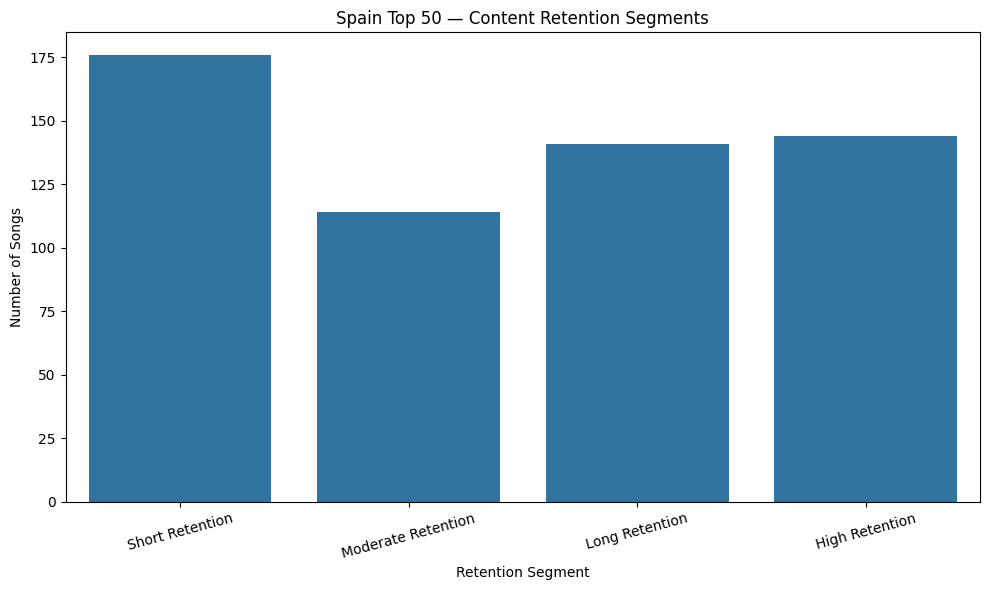

In [273]:
# Visualize Retention Segments

segment_order = [
    "Short Retention",
    "Moderate Retention",
    "Long Retention",
    "High Retention"
]


plt.figure(figsize=(10, 6))

sns.countplot(
    data=business_df,
    x="retention_segment",
    order=segment_order
)

plt.title(
    "Spain Top 50 — Content Retention Segments"
)

plt.xlabel("Retention Segment")

plt.ylabel("Number of Songs")

plt.xticks(rotation=15)

plt.tight_layout()

plt.show()

In [274]:
# Identify High-Retention Songs

high_retention_songs = (
    
    business_df[
        business_df["retention_segment"]
        == "High Retention"
    ]
    
    .sort_values(
        "days_on_playlist",
        ascending=False
    )
    
    [
        [
            "song",
            "artist",
            "days_on_playlist",
            "best_position",
            "entry_position",
            "time_to_peak_days",
            "retention_stability_index"
        ]
    ]
)


print("Top High-Retention Songs:")

display(
    high_retention_songs.head(20)
)

Top High-Retention Songs:


,song,artist,days_on_playlist,best_position,entry_position,time_to_peak_days,retention_stability_index
265,La Bachata,Manuel Turizo,551,11,24,228,96.74
29,AMARGURA,KAROL G,524,16,50,426,26.49
546,VAGABUNDO,Sebastian Yatra & Manuel Turizo & Beéle,517,3,39,17,65.92
97,Columbia,Quevedo,483,1,39,1,86.95
293,LALA,Myke Towers,453,1,42,6,58.77
524,TQG,KAROL G,448,9,9,0,20.85
429,QLONA,KAROL G,427,8,37,26,74.11
26,Amanece,Anuel AA & Haze,408,47,50,29,3.61
167,El Merengue,Marshmello,380,19,20,1,80.66
325,Manos Rotas,DELLAFUENTE & Morad,371,1,13,11,75.13


In [275]:
# HIGH RETENTION CONTENT CHARACTERISTICS

high_retention_characteristics = (

    business_df
    
    .groupby("retention_segment")
    
    .agg({

        "days_on_playlist": "mean",

        "best_position": "mean",

        "entry_position": "mean",

        "time_to_peak_days": "mean",

        "entry_popularity": "mean",

        "peak_popularity": "mean",

        "duration_min": "mean",

        "total_tracks": "mean",

        "retention_stability_index": "mean"

    })
    
    .round(2)
)


display(
    high_retention_characteristics
)

,days_on_playlist,best_position,entry_position,time_to_peak_days,entry_popularity,peak_popularity,duration_min,total_tracks,retention_stability_index
retention_segment,,,,,,,,,
High Retention,182.52,9.92,25.96,28.29,62.67,85.38,3.29,6.64,72.32
Long Retention,38.15,19.13,32.40,8.32,60.52,80.58,3.27,6.58,59.71
Moderate Retention,8.70,24.01,28.52,1.60,51.26,77.17,3.49,9.97,37.86
Short Retention,2.14,32.20,32.81,0.14,49.96,58.23,3.12,11.53,64.66


In [276]:
# Fast-Growth Songs (Fast growth ka matlab hai songs jo quickly apni best rank achieve karte hain)

fast_growth_songs = (

    business_df
    
    .sort_values(
        [
            "time_to_peak_days",
            "best_position"
        ],
        
        ascending=[
            True,
            True
        ]
    )
    
    [
        [
            "song",
            "artist",
            "entry_position",
            "best_position",
            "time_to_peak_days",
            "days_on_playlist"
        ]
    ]
)


print("Fastest Growth Songs:")

display(
    fast_growth_songs.head(20)
)

Fastest Growth Songs:


,song,artist,entry_position,best_position,time_to_peak_days,days_on_playlist
20,ADIVINO,Myke Towers & Bad Bunny,1,1,0,118
69,Buenas,Quevedo & Saiko,1,1,0,170
155,DURO,Quevedo,1,1,0,26
222,GRAN VÍA,Quevedo,1,1,0,4
249,IA,Clarent & Mora,1,1,0,15
289,LA ÚLTIMA,Quevedo,1,1,0,49
348,"Milo J: Bzrp Music Sessions, Vol. 57",Bizarrap & Milo j,1,1,0,127
354,MONACO,Bad Bunny,1,1,0,91
416,POLARIS - Remix,Saiko & Feid & Quevedo,1,1,0,314
439,Qué Pasaría...,Rauw Alejandro,1,1,0,11


In [277]:
# Calculate Rank Improvement

business_df[
    "rank_improvement"
] = (

    business_df["entry_position"]
    
    -
    
    business_df["best_position"]
)


print(
    business_df[
        "rank_improvement"
    ].describe()
)

count    575.000000
mean       8.349565
std       12.883743
min        0.000000
25%        0.000000
50%        0.000000
75%       13.000000
max       48.000000
Name: rank_improvement, dtype: float64


In [278]:
# STRONG MOMENTUM SONGS

strong_momentum = (

    business_df
    
    .sort_values(
        [
            "rank_improvement",
            "days_on_playlist"
        ],
        
        ascending=[
            False,
            False
        ]
    )
    
    [
        [
            "song",
            "artist",
            "entry_position",
            "best_position",
            "rank_improvement",
            "days_on_playlist"
        ]
    ]
)


print("Top Momentum Songs:")

display(
    strong_momentum.head(20)
)

Top Momentum Songs:


,song,artist,entry_position,best_position,rank_improvement,days_on_playlist
449,REAL GANGSTA LOVE,Trueno,49,1,48,164
24,All I Want for Christmas Is You,Mariah Carey,49,1,48,31
486,Si No Estás,iñigo quintero,48,1,47,196
352,MODELITO,Mora,50,4,46,282
404,PELIGROSA,FloyyMenor,49,3,46,120
375,No Te Quieren Conmigo,Gaby Music & Lunay & Luar La L,50,4,46,112
296,Last Christmas - Single Version,Wham!,49,4,45,5
242,Holanda,Jhayco,47,3,44,221
419,Potra Salvaje - Hard Remix,Isabel Aaiún & Fernando Moreno,47,3,44,119
502,STAR,JC Reyes,50,7,43,39


In [279]:
# Early Entry Strength Analysis (Songs jo Top 50 mein high position par enter karte hain)

def entry_strength(position):

    if position <= 10:
        return "Strong Entry"

    elif position <= 25:
        return "Moderate Entry"

    else:
        return "Weak Entry"


business_df[
    "entry_strength"
] = business_df[
    "entry_position"
].apply(entry_strength)


entry_strength_summary = (

    business_df
    
    .groupby("entry_strength")
    
    .agg({

        "days_on_playlist": "mean",

        "best_position": "mean",

        "retention_stability_index": "mean",

        "entry_popularity": "mean"
    })
      
    .round(2)
)


display(entry_strength_summary) 

,days_on_playlist,best_position,retention_stability_index,entry_popularity
entry_strength,,,,
Moderate Entry,54.00,15.66,46.17,47.38
Strong Entry,88.84,4.59,57.14,51.24
Weak Entry,50.36,28.83,66.28,60.66


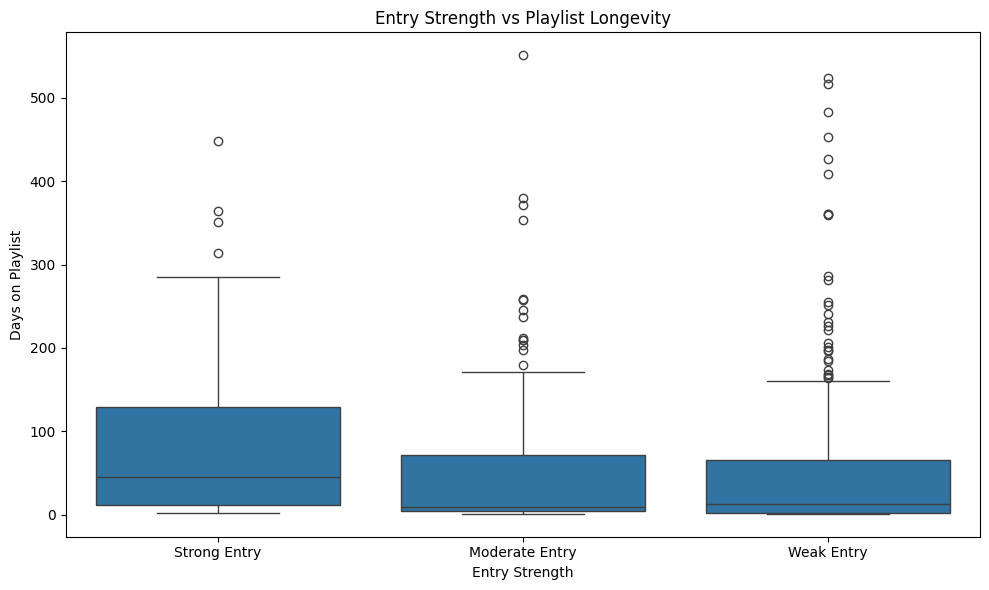

In [280]:
# Entry Strength Visualization

# ENTRY STRENGTH VS LONGEVITY
entry_order = [
    "Strong Entry",
    "Moderate Entry",
    "Weak Entry"
]


plt.figure(figsize=(10, 6))

sns.boxplot(
    data=business_df,
    x="entry_strength",
    y="days_on_playlist",
    order=entry_order
)

plt.title(
    "Entry Strength vs Playlist Longevity"
)

plt.xlabel("Entry Strength")

plt.ylabel("Days on Playlist")

plt.tight_layout()

plt.show()

In [281]:
# Explicit vs Clean Business Strategy

# EXPLICIT VS CLEAN STRATEGY
explicit_strategy = (

    business_df
    
    .groupby("is_explicit")
    
    .agg({

        "days_on_playlist": [
            "mean",
            "median"
        ],

        "best_position": "mean",

        "entry_position": "mean",

        "time_to_peak_days": "mean",

        "retention_stability_index": "mean",

        "entry_popularity": "mean"

    })
    
    .round(2)
)


display(explicit_strategy)

days_on_playlist        best_position entry_position  \
                        mean median          mean           mean   
is_explicit                                                        
False                  59.88   16.0         22.05          30.50   
True                   54.28   14.5         21.46          29.68   

            time_to_peak_days retention_stability_index entry_popularity  
                         mean                      mean             mean  
is_explicit                                                               
False                    9.64                     59.25            59.70  
True                     9.28                     61.08            51.18

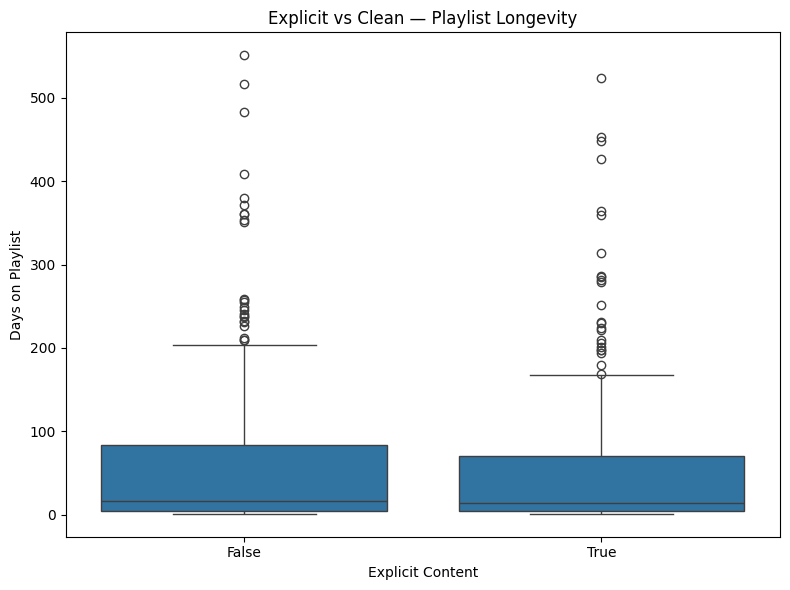

In [282]:
# Explicit vs Clean Visualization

plt.figure(figsize=(8, 6))

sns.boxplot(
    data=business_df,
    x="is_explicit",
    y="days_on_playlist"
)

plt.title(
    "Explicit vs Clean — Playlist Longevity"
)

plt.xlabel("Explicit Content")

plt.ylabel("Days on Playlist")

plt.tight_layout()

plt.show()

In [283]:
# SINGLE VS ALBUM STRATEGY

album_strategy = (

    business_df
    
    .groupby("album_type")
    
    .agg({

        "days_on_playlist": [
            "mean",
            "median"
        ],

        "best_position": "mean",

        "entry_position": "mean",

        "time_to_peak_days": "mean",

        "retention_stability_index": "mean",

        "entry_popularity": "mean"

    })
    
    .round(2)
)


display(album_strategy)

days_on_playlist        best_position entry_position  \
                       mean median          mean           mean   
album_type                                                        
album                 48.33    7.0         22.89          28.49   
single                66.85   29.0         20.66          31.85   

           time_to_peak_days retention_stability_index entry_popularity  
                        mean                      mean             mean  
album_type                                                               
album                   8.64                     56.13            47.84  
single                 10.35                     64.09            64.40

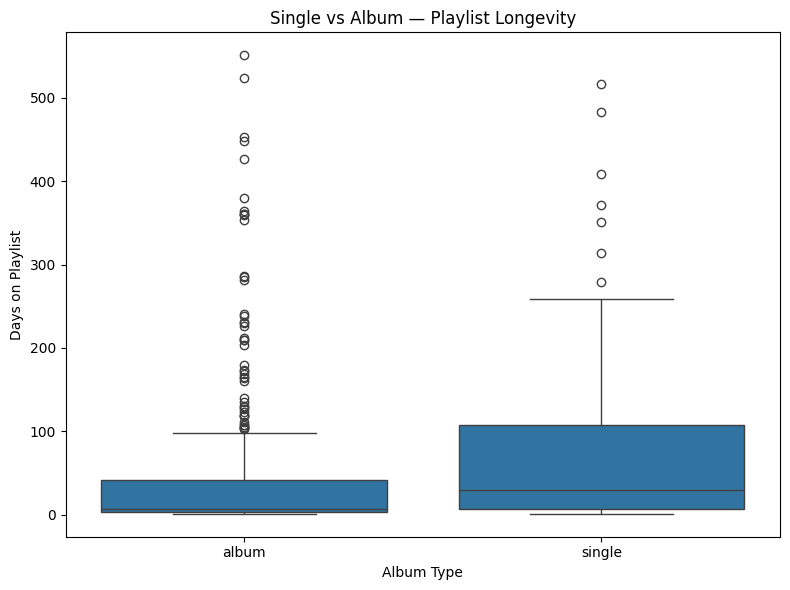

In [284]:
# SINGLE VS ALBUM LONGEVITY

plt.figure(figsize=(8, 6))

sns.boxplot(
    data=business_df,
    x="album_type",
    y="days_on_playlist"
)

plt.title(
    "Single vs Album — Playlist Longevity"
)

plt.xlabel("Album Type")

plt.ylabel("Days on Playlist")

plt.tight_layout()

plt.show()

In [285]:
# FRESH VS MATURE CONTENT

fresh_mature_summary = (

    business_df
    
    .groupby("lifecycle_stage")
    
    .agg({

        "days_on_playlist": "mean",

        "best_position": "mean",

        "entry_popularity": "mean",

        "peak_popularity": "mean",

        "retention_stability_index": "mean"
    })
    
    .round(2)
)


display(
    fresh_mature_summary
)

,days_on_playlist,best_position,entry_popularity,peak_popularity,retention_stability_index
lifecycle_stage,,,,,
Decline Phase,28.03,14.73,47.97,81.25,35.01
Growth Phase,20.00,10.10,65.70,76.30,34.56
Mature Phase,84.55,25.15,67.38,80.87,69.24
New Entry,3.36,30.70,49.79,62.70,55.53
Peak Phase,159.13,4.48,59.02,85.53,76.41


In [286]:
# Lifecycle Stage Business Value

# LIFECYCLE STAGE DISTRIBUTION
stage_distribution = (

    business_df[
        "lifecycle_stage"
    ]
    
    .value_counts()
    
    .reset_index()
)


stage_distribution.columns = [
    "Lifecycle Stage",
    "Song Count"
]


display(stage_distribution)

,Lifecycle Stage,Song Count
0,New Entry,237
1,Mature Phase,142
2,Peak Phase,113
3,Decline Phase,73
4,Growth Phase,10


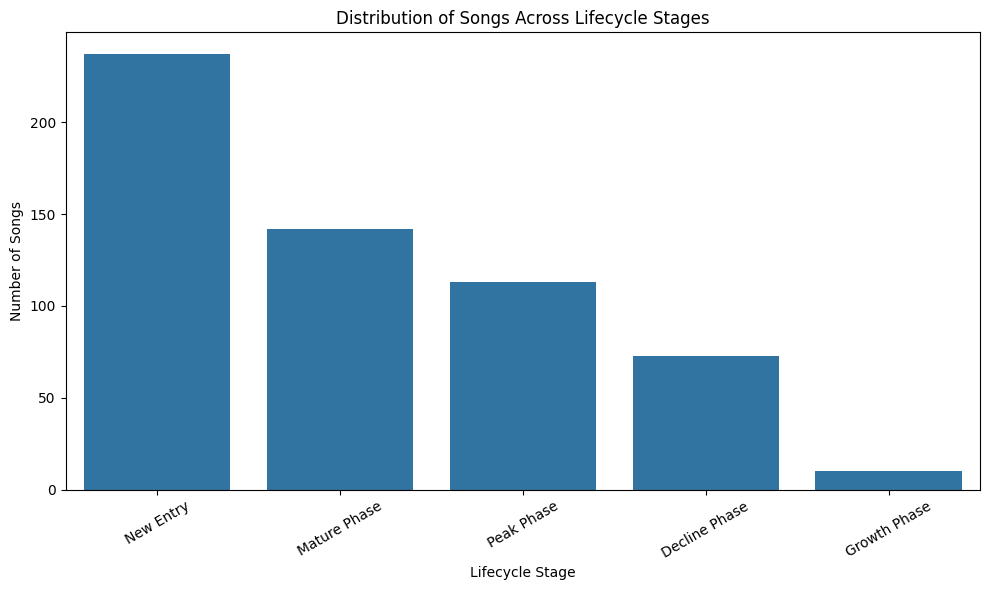

In [287]:
# LIFECYCLE STAGE DISTRIBUTION PLOT

plt.figure(figsize=(10, 6))

sns.countplot(
    data=business_df,
    x="lifecycle_stage",
    order=business_df[
        "lifecycle_stage"
    ].value_counts().index
)

plt.title(
    "Distribution of Songs Across Lifecycle Stages"
)

plt.xlabel("Lifecycle Stage")

plt.ylabel("Number of Songs")

plt.xticks(rotation=30)

plt.tight_layout()

plt.show()

In [289]:
# PLAYLIST ROTATION BUSINESS METRICS (Agar daily_churn dataframe create hua hai, toh ye analysis chaleg)

try:

    rotation_summary = {

        "Average Daily Entries":
            daily_churn["entries"].mean(),

        "Average Daily Exits":
            daily_churn["exits"].mean(),

        "Average Churn Rate":
            daily_churn["churn_rate"].mean(),

        "Maximum Daily Churn":
            daily_churn["churn_rate"].max(),

        "Minimum Daily Churn":
            daily_churn["churn_rate"].min()
    }


    rotation_summary_df = pd.DataFrame(

        rotation_summary.items(),

        columns=[
            "Rotation KPI",
            "Value"
        ]
    )


    rotation_summary_df["Value"] = (
        rotation_summary_df["Value"].round(2)
    )


    display(rotation_summary_df)


except NameError:

    print(
        "daily_churn dataframe was not found."
    )



daily_churn dataframe was not found.


In [290]:
# ROTATION RISK CLASSIFICATION

if "daily_churn" in globals():

    churn_q25 = daily_churn[
        "churn_rate"
    ].quantile(0.25)


    churn_q75 = daily_churn[
        "churn_rate"
    ].quantile(0.75)


    def rotation_risk(churn):

        if churn <= churn_q25:
            return "Stable Playlist"

        elif churn <= churn_q75:
            return "Moderate Rotation"

        else:
            return "High Rotation"


    daily_churn[
        "rotation_risk"
    ] = daily_churn[
        "churn_rate"
    ].apply(rotation_risk)


    print(
        daily_churn[
            "rotation_risk"
        ].value_counts()
    )

In [291]:
# High-Risk Songs (Songs with short retention and weak entry performance)
high_risk_songs = (

    business_df[
        
        (
            business_df[
                "retention_segment"
            ] == "Short Retention"
        )

        &
        
        (
            business_df[
                "entry_strength"
            ] == "Weak Entry"
        )
    ]
    
    .sort_values(
        "days_on_playlist"
    )
)


print(
    "High-Risk Songs Count:",
    len(high_risk_songs)
)


display(

    high_risk_songs[
        [
            "song",
            "artist",
            "entry_position",
            "best_position",
            "days_on_playlist",
            "entry_popularity"
        ]
    ].head(20)

)

High-Risk Songs Count: 117


,song,artist,entry_position,best_position,days_on_playlist,entry_popularity
1,"1 de Enero, Puntacana",Rels B,45,45,1,65
10,50 PALOS,Feid,38,38,1,0
40,ATTITUDE (FEAT. CHARLIE WILSON & CASH COBAIN),Don Toliver,46,46,1,69
28,Amar De Nuevo,Rauw Alejandro,45,45,1,64
72,CACHÉ,Myke Towers,47,47,1,0
60,Beso Prohibido,Beny Jr,49,49,1,64
53,Barro,Duki,40,40,1,60
52,BANDIT,Don Toliver,27,27,1,69
75,Cangrinaje,Cruz Cafuné,48,48,1,56
74,CALL ME MAYBE,Duki,50,50,1,65


In [292]:
# Content Opportunity Matrix  (Hum songs ko 4 strategic categories mein classify karenge)

median_retention = business_df[
    "days_on_playlist"
].median()


median_popularity = business_df[
    "entry_popularity"
].median()


def opportunity_segment(row):

    long_retention = (
        row["days_on_playlist"]
        >= median_retention
    )

    high_popularity = (
        row["entry_popularity"]
        >= median_popularity
    )


    if long_retention and high_popularity:
        return "Star Content"


    elif long_retention and not high_popularity:
        return "Hidden Opportunity"


    elif not long_retention and high_popularity:
        return "Short-Term Hit"


    else:
        return "Low Priority"
    

business_df[
    "opportunity_segment"
] = business_df.apply(
    opportunity_segment,
    axis=1
)


print(
    business_df[
        "opportunity_segment"
    ].value_counts()
)


opportunity_segment
Star Content          183
Low Priority          164
Short-Term Hit        120
Hidden Opportunity    108
Name: count, dtype: int64


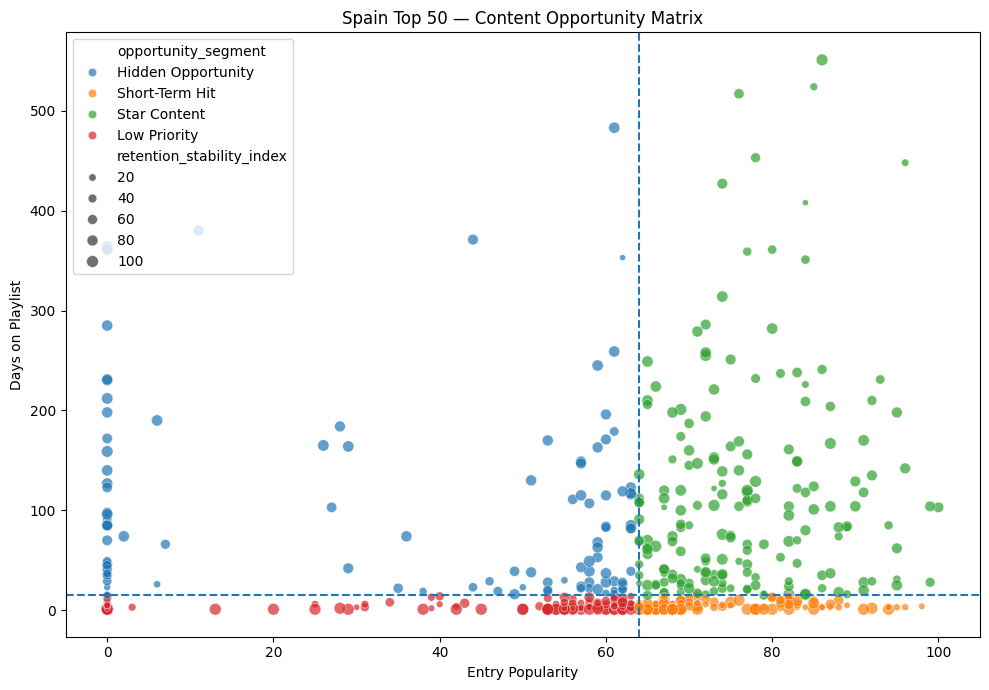

In [293]:
# Opportunity Matrix Visualization

# CONTENT OPPORTUNITY MATRIX PLOT
plt.figure(figsize=(10, 7))

sns.scatterplot(

    data=business_df,

    x="entry_popularity",

    y="days_on_playlist",

    hue="opportunity_segment",

    size="retention_stability_index",

    alpha=0.7
)


plt.axvline(
    median_popularity,
    linestyle="--"
)

plt.axhline(
    median_retention,
    linestyle="--"
)


plt.title(
    "Spain Top 50 — Content Opportunity Matrix"
)

plt.xlabel(
    "Entry Popularity"
)

plt.ylabel(
    "Days on Playlist"
)

plt.tight_layout()

plt.show()

# Axes ka meaning
# X-axis: Entry Popularity → Song ki popularity jab woh analysis/chart lifecycle mein enter hua.
# Y-axis: Days on Playlist → Song kitne din Spain Top 50 mein raha.
# Bubble size: Retention Stability Index → Jitna bada bubble, utni better retention stability.
# Dashed vertical line → Entry popularity ka threshold.
# Dashed horizontal line → Playlist longevity/retention threshold.

In [294]:
# Strategic Action Framework

strategic_actions = pd.DataFrame({

    "Content Segment": [

        "Star Content",

        "Hidden Opportunity",

        "Short-Term Hit",

        "Low Priority"
    ],

    "Business Strategy": [

        "Increase marketing investment and maximize playlist visibility",

        "Increase promotion because strong retention indicates growth potential",

        "Use intensive short-term campaigns during peak popularity",

        "Reduce promotional investment and monitor performance"
    ],

    "Recommended Action": [

        "Sustain visibility and expand audience reach",

        "Boost discovery and playlist support",

        "Maximize revenue during short popularity window",

        "Optimize budget allocation"
    ]
})


display(strategic_actions)

,Content Segment,Business Strategy,Recommended Action
0,Star Content,Increase marketing investment and maximize pla...,Sustain visibility and expand audience reach
1,Hidden Opportunity,Increase promotion because strong retention in...,Boost discovery and playlist support
2,Short-Term Hit,Use intensive short-term campaigns during peak...,Maximize revenue during short popularity window
3,Low Priority,Reduce promotional investment and monitor perf...,Optimize budget allocation


In [295]:
# Marketing Intensity Recommendation

# MARKETING INTENSITY SCORE
def marketing_recommendation(row):

    if (
        row["opportunity_segment"]
        == "Star Content"
    ):
        return "Very High"


    elif (
        row["opportunity_segment"]
        == "Hidden Opportunity"
    ):
        return "High"


    elif (
        row["opportunity_segment"]
        == "Short-Term Hit"
    ):
        return "Medium"


    else:
        return "Low"


business_df[
    "marketing_intensity"
] = business_df.apply(
    marketing_recommendation,
    axis=1
)


print(
    business_df[
        "marketing_intensity"
    ].value_counts()
)

marketing_intensity
Very High    183
Low          164
Medium       120
High         108
Name: count, dtype: int64


In [296]:
# Playlist Strategy Recommendation

def playlist_strategy(row):

    if (
        row["retention_segment"]
        == "High Retention"
    ):
        return "Maintain Strong Playlist Support"


    elif (
        row["rank_improvement"]
        > business_df[
            "rank_improvement"
        ].median()
    ):
        return "Increase Playlist Exposure"


    elif (
        row["retention_segment"]
        == "Short Retention"
    ):
        return "Monitor Exit Risk"


    else:
        return "Maintain Current Support"


business_df[
    "playlist_recommendation"
] = business_df.apply(
    playlist_strategy,
    axis=1
)


display(

    business_df[
        [
            "song",
            "artist",
            "retention_segment",
            "rank_improvement",
            "playlist_recommendation"
        ]
    ].head(20)

)

,song,artist,retention_segment,rank_improvement,playlist_recommendation
0,0 CONFIANZA,Rvfv,Long Retention,17,Increase Playlist Exposure
1,"1 de Enero, Puntacana",Rels B,Short Retention,0,Monitor Exit Risk
2,1000COSAS,Lola Indigo & Manuel Turizo,High Retention,0,Maintain Strong Playlist Support
3,100xCiento,Foreign Teck & Eladio Carrion & De La Ghetto,Long Retention,29,Increase Playlist Exposure
4,14 FEBREROS,Quevedo,Short Retention,0,Monitor Exit Risk
5,2AM,Sebastian Yatra & Bad Gyal,Short Retention,10,Increase Playlist Exposure
6,2xLL,JC Reyes & YOVNGCHIMI & Slayter,Long Retention,15,Increase Playlist Exposure
7,3 CAÍDAS,SAIKO,Moderate Retention,0,Maintain Current Support
8,4 PREZ,Cruz Cafuné,Short Retention,0,Monitor Exit Risk
9,4TO 23,Aitana,Moderate Retention,0,Maintain Current Support


In [297]:
# Executive Insights Generator  (Yeh automatically major findings generate karega)


# EXECUTIVE INSIGHTS
avg_days = business_df[
    "days_on_playlist"
].mean()


high_retention_count = len(

    business_df[
        business_df[
            "retention_segment"
        ] == "High Retention"
    ]
)


short_retention_count = len(

    business_df[
        business_df[
            "retention_segment"
        ] == "Short Retention"
    ]
)


star_content_count = len(

    business_df[
        business_df[
            "opportunity_segment"
        ] == "Star Content"
    ]
)


hidden_opportunity_count = len(

    business_df[
        business_df[
            "opportunity_segment"
        ] == "Hidden Opportunity"
    ]
)


print("============================================")
print("EXECUTIVE INSIGHTS — SPAIN TOP 50")
print("============================================")


print(
    f"""
1. Average playlist lifecycle is
   {avg_days:.2f} days.

2. {high_retention_count} songs fall into
   the High Retention category.

3. {short_retention_count} songs demonstrate
   Short Retention behavior.

4. {star_content_count} songs qualify as
   Star Content.

5. {hidden_opportunity_count} songs represent
   Hidden Opportunities for additional promotion.
"""
)

EXECUTIVE INSIGHTS — SPAIN TOP 50

1. Average playlist lifecycle is
   57.45 days.

2. 144 songs fall into
   the High Retention category.

3. 176 songs demonstrate
   Short Retention behavior.

4. 183 songs qualify as
   Star Content.

5. 108 songs represent
   Hidden Opportunities for additional promotion.



In [298]:
# FINAL BUSINESS RECOMMENDATIONS

recommendations = []


# Recommendation 1
recommendations.append({

    "Area": "Release Strategy",

    "Recommendation":
        "Prioritize strong entry performance because early playlist positioning can influence lifecycle visibility."
})


# Recommendation 2
recommendations.append({

    "Area": "Marketing Strategy",

    "Recommendation":
        "Increase promotional investment in Hidden Opportunity songs that demonstrate strong retention despite lower initial popularity."
})


# Recommendation 3
recommendations.append({

    "Area": "Playlist Strategy",

    "Recommendation":
        "Maintain playlist support for High Retention songs to maximize long-term audience exposure."
})


# Recommendation 4
recommendations.append({

    "Area": "Budget Optimization",

    "Recommendation":
        "Use short-term intensive campaigns for Short-Term Hits and avoid unnecessary long-duration promotional spending."
})


# Recommendation 5
recommendations.append({

    "Area": "Content Portfolio",

    "Recommendation":
        "Balance fresh releases with proven high-retention catalog content to reduce playlist volatility."
})


# Recommendation 6
recommendations.append({

    "Area": "Performance Monitoring",

    "Recommendation":
        "Monitor songs with weak entry positions and short retention for early exit risk."
})


recommendations_df = pd.DataFrame(
    recommendations
)


display(recommendations_df)

,Area,Recommendation
0,Release Strategy,Prioritize strong entry performance because ea...
1,Marketing Strategy,Increase promotional investment in Hidden Oppo...
2,Playlist Strategy,Maintain playlist support for High Retention s...
3,Budget Optimization,Use short-term intensive campaigns for Short-T...
4,Content Portfolio,Balance fresh releases with proven high-retent...
5,Performance Monitoring,Monitor songs with weak entry positions and sh...


In [299]:
# FINAL EXECUTIVE SUMMARY

executive_summary = pd.DataFrame({

    "Business Metric": [

        "Total Songs Analyzed",

        "Average Playlist Longevity",

        "Median Playlist Longevity",

        "High Retention Songs",

        "Short Retention Songs",

        "Star Content",

        "Hidden Opportunities"
    ],

    "Value": [

        len(business_df),

        round(
            business_df[
                "days_on_playlist"
            ].mean(),
            2
        ),

        round(
            business_df[
                "days_on_playlist"
            ].median(),
            2
        ),

        high_retention_count,

        short_retention_count,

        star_content_count,

        hidden_opportunity_count
    ]
})


print("============================================")
print("FINAL EXECUTIVE SUMMARY")
print("============================================")

display(executive_summary)

FINAL EXECUTIVE SUMMARY


,Business Metric,Value
0,Total Songs Analyzed,575.00
1,Average Playlist Longevity,57.45
2,Median Playlist Longevity,15.00
3,High Retention Songs,144.00
4,Short Retention Songs,176.00
5,Star Content,183.00
6,Hidden Opportunities,108.00


In [301]:
# EXPORT RESULTS

business_df.to_csv(
    "Spain_Top50_Business_Strategy_Dataset.csv",
    index=False
)


overall_kpi_df.to_csv(
    "Spain_Top50_Overall_Business_KPIs.csv",
    index=False
)


high_retention_songs.to_csv(
    "Spain_Top50_High_Retention_Songs.csv",
    index=False
)


strong_momentum.to_csv(
    "Spain_Top50_Strong_Momentum_Songs.csv",
    index=False
)


high_risk_songs.to_csv(
    "Spain_Top50_High_Risk_Songs.csv",
    index=False
)


strategic_actions.to_csv(
    "Spain_Top50_Strategic_Actions.csv",
    index=False
)


recommendations_df.to_csv(
    "Spain_Top50_Business_Recommendations.csv",
    index=False
)


executive_summary.to_csv(
    "Spain_Top50_Executive_Summary.csv",
    index=False
)


entry_strength_summary.to_csv(
    "Spain_Top50_Entry_Strength_Analysis.csv"
)


high_retention_characteristics.to_csv(
    "Spain_Top50_High_Retention_Characteristics.csv"
)


print("All results exported successfully!")

All results exported successfully!


In [302]:
# Final Completion Summary

print("""
====================================================
COMPLETED SUCCESSFULLY
====================================================

Advanced Business Insights Generated:

 Overall Spain Top 50 KPIs
 Content Retention Segmentation
 High-Retention Song Analysis
 Fast-Growth Song Analysis
 Strong Momentum Analysis
 Entry Strength Analysis
 Explicit vs Clean Strategy
 Single vs Album Strategy
 Fresh vs Mature Content Analysis
 Playlist Rotation Strategy
 High-Risk Content Identification
 Content Opportunity Matrix
 Marketing Intensity Recommendations
 Playlist Support Recommendations
 Executive Insights
 Strategic Business Recommendations

All results are ready for:

 Research Paper
 Executive Summary
 PowerPoint Presentation
 Streamlit Dashboard
 Atlantic Recording Corporation Strategy Report

====================================================
""")


COMPLETED SUCCESSFULLY

Advanced Business Insights Generated:

 Overall Spain Top 50 KPIs
 Content Retention Segmentation
 High-Retention Song Analysis
 Fast-Growth Song Analysis
 Strong Momentum Analysis
 Entry Strength Analysis
 Explicit vs Clean Strategy
 Single vs Album Strategy
 Fresh vs Mature Content Analysis
 Playlist Rotation Strategy
 High-Risk Content Identification
 Content Opportunity Matrix
 Marketing Intensity Recommendations
 Playlist Support Recommendations
 Executive Insights
 Strategic Business Recommendations

All results are ready for:

 Research Paper
 Executive Summary
 PowerPoint Presentation
 Streamlit Dashboard
 Atlantic Recording Corporation Strategy Report




In [303]:
# | Segment                   | Meaning                           | Strategy                 |
# | ------------------------- | --------------------------------- | ------------------------ |
# |  **Star Content**        | High popularity + long retention  | Maximum support          |
# |  **Hidden Opportunity** | Lower popularity + long retention | Increase promotion       |
# |  **Short-Term Hit**     | High popularity + short retention | Intensive short campaign |
# |  **Low Priority**       | Low popularity + short retention  | Limited investment       |


# Streamlit Dashboard :

In [304]:
import os
import zipfile

csv_files = []

for file in os.listdir():
    if file.endswith(".csv"):
        csv_files.append(file)

with zipfile.ZipFile("Spain_Project_Files.zip", "w") as zip_file:
    for file in csv_files:
        zip_file.write(file)

print("Successfully created!")
print("Total CSV files:", len(csv_files))

Successfully created!
Total CSV files: 63
